# Kenya MAM Onset/Cessation Diagnostics - CMCC Workflow

## Outline

0. Notebook Maintenance
- Keep this outline updated whenever a plot or interpretation cell is changed
- Keep plot titles and explanation markdown aligned with current code behavior

1. Environment Setup
- Import Python packages
- Set working directory
- Define input/output paths

2. Data Ingestion and Preprocessing
- Load CHIRPS daily observations
- Load CMCC forecast files
- Prepare grid, mask, and coordinate harmonization

3. Core Seasonal Diagnostics
- Onset, cessation, and season length (sl) diagnostics
- Calibration and validation period checks
- Domain-level summary diagnostics

4. Interactive Diagnostics
- Interactive CHIRPS spatial diagnostics (CAL/VAL)
- Interactive CHIRPS spatial diagnostics by year
- Interactive CMCC member diagnostics
- Interactive CMCC two-map spatial diagnostics (CAL/VAL/OP)
- Interactive CMCC single-map spatial diagnostics (CHIRPS-style)

5. CMCC Companion Visualizations (Original Plot Unchanged)
- Companion prep
- Plot 1: Monthly decomposition (Feb-Jun)
- Plot 2: Outlier callout and lollipop
- Plot 3: Distribution comparison (CAL vs VAL vs OP member box, with jittered points)
- Plot 4: Seasonal anomaly (vs CAL mean)
- Plot 5: Member spread and uncertainty ribbon (P10-P90 + medians; OP whisker/median)
- Plot 6: Period summary strip (CAL/VAL bars + OP member box)
- Plot 7: Zoomed companion time series
- Plot 8: Reliability diagram (tercile probabilities)
- Plot 9: ROC curves and AUC (tercile classes)
- Plot 10: AUC bootstrap uncertainty (95% CI)
- Plot 11: Brier score and Brier skill score (tercile classes)
- Plot 12: Spread-skill scatter (ensemble spread vs error)
- Plot 13: Rank histogram (ensemble bias / dispersion)
- Plot 14: Yearly RPSS timeline (temporal stability)
- Plot 15: Formal decision gate criteria (pass/fail thresholds)
- Plot 16: Consolidated decision summary table (GO/CAUTION/HOLD)

6. Summary and Outputs
- Final summary printout
- Saved diagnostics and figures

## Import Python Packages

In [1]:
import numpy        as np
import xarray       as xr
import pandas       as pd
import os, datetime, warnings, glob, re, gc
from pathlib import Path
import geopandas    as gpd
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot      as plt
import matplotlib.patches     as mpatches
import matplotlib.ticker      as mticker
import matplotlib.gridspec    as gridspec
import matplotlib.colors      as mcolors
import matplotlib.patheffects as mpe
import cartopy.crs            as ccrs
import cartopy.feature        as cfeature
warnings.filterwarnings("ignore")

## Set Working Directory

In [2]:
p = Path(r"D:\dashboard_ons_cess_sl")
os.chdir(p)
print(Path.cwd())

D:\dashboard_ons_cess_sl


## Input File Paths

In [3]:
# ── CHIRPS observational data ─────────────────────────────────────────────
CHIRPS_DAILY_PATH  = r"data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc"
CHIRPS_VAR         = "precip"

# ── CMCC forecast data ─────────────────────────────────────────────

CMCC_DIR          = r"data\seasonal_pr_downloads_ke\cmcc"
CMCC_FILE_PATTERN = "cmcc_{year}02_d01.nc"
FILE_GLOB           = "cmcc_*02_d01.nc"
CMCC_VAR          = "tp"           # cumulative total precipitation (metres)


# ── Kenya shapefile ───────────────────────────────────────────────────────
KENYA_SHP = r"data\shapefiles\ke\ken_admin0.shp"

# ALL outputs for this model go here ─────────────────────
OUT_DIR      = r"outputs\cmcc_v1"
PLOT_DIR     = os.path.join(OUT_DIR, "plots")
BULLETIN_DIR = os.path.join(PLOT_DIR, "bulletins")

os.makedirs(OUT_DIR,      exist_ok=True)
os.makedirs(PLOT_DIR,     exist_ok=True)
os.makedirs(BULLETIN_DIR, exist_ok=True)

### Output Directory

In [4]:
# ── CMCC-specific output file paths ─────────────────────────────────
OUT_CMCC_BC    = os.path.join(OUT_DIR, "CMCC_bc_daily_all_years.nc")
OUT_CMCC_ONSET = os.path.join(OUT_DIR, "CMCC_onset_doy_all_years.nc")
OUT_CMCC_CESS  = os.path.join(OUT_DIR, "CMCC_cessation_doy_all_years.nc")
OUT_CMCC_SL   = os.path.join(OUT_DIR, "CMCC_sl_days_all_years.nc")


os.makedirs(OUT_DIR, exist_ok=True)
for _sub in ["calibration_params", "validation_scores", "operational_2026",
             "diagnostics", "plots", "plots/bulletins"]:
    os.makedirs(os.path.join(OUT_DIR, _sub), exist_ok=True)

PLOT_DIR     = os.path.join(OUT_DIR, "plots")
BULLETIN_DIR = os.path.join(PLOT_DIR, "bulletins")
CALIB_DIR    = os.path.join(OUT_DIR, "calibration_params")
VALID_DIR    = os.path.join(OUT_DIR, "validation_scores")

# ── CHIRPS reference outputs ──────────────────────────────────────────────
OUT_Q_D          = os.path.join(OUT_DIR, "chirps_Q_d_cal.nc")
OUT_Q_BAR        = os.path.join(OUT_DIR, "chirps_Q_bar.nc")
OUT_C_CLIM       = os.path.join(OUT_DIR, "chirps_C_clim.nc")
OUT_D_S          = os.path.join(OUT_DIR, "chirps_d_s.nc")
OUT_D_E          = os.path.join(OUT_DIR, "chirps_d_e.nc")
OUT_CHIRPS_ONSET = os.path.join(OUT_DIR, "CHIRPS_onset_doy_1993_2025.nc")
OUT_CHIRPS_CESS  = os.path.join(OUT_DIR, "CHIRPS_cessation_doy_1993_2025.nc")
OUT_CHIRPS_SL   = os.path.join(OUT_DIR, "CHIRPS_lgp_days_1993_2025.nc")
OUT_DET_RATE     = os.path.join(OUT_DIR, "CHIRPS_detection_rate.nc")

# ── Tercile boundaries (calibration_params subdirectory) ─────────────────
OUT_T33_ONSET = os.path.join(CALIB_DIR, "t33_onset_doy.nc")
OUT_T67_ONSET = os.path.join(CALIB_DIR, "t67_onset_doy.nc")
OUT_T33_CESS  = os.path.join(CALIB_DIR, "t33_cessation_doy.nc")
OUT_T67_CESS  = os.path.join(CALIB_DIR, "t67_cessation_doy.nc")
OUT_T33_SL   = os.path.join(CALIB_DIR, "t33_lgp_days.nc")
OUT_T67_SL   = os.path.join(CALIB_DIR, "t67_lgp_days.nc")

# ── CMCC-specific outputs ───────────────────────────────────────────
OUT_CMCC_BC    = os.path.join(OUT_DIR, "CMCC_bc_daily_all_years.nc")
OUT_CMCC_ONSET = os.path.join(OUT_DIR, "CMCC_onset_doy_all_years.nc")
OUT_CMCC_CESS  = os.path.join(OUT_DIR, "CMCC_cessation_doy_all_years.nc")
OUT_CMCC_LGP   = os.path.join(OUT_DIR, "CMCC_lgp_days_all_years.nc")

print("\nOutput file paths:")
print(f"  Root           : {OUT_DIR}")
print(f"  Plots          : {PLOT_DIR}")

print(f"  CHIRPS input  : {CHIRPS_DAILY_PATH}")
print(f"  CMCC data     : {CMCC_DIR}")

print(f"  Calibration    : {CALIB_DIR}")
print(f"  Validation     : {VALID_DIR}")

print(f"  CHIRPS onset   : {OUT_CHIRPS_ONSET}")
print(f"  CHIRPS cess    : {OUT_CHIRPS_CESS}")
print(f"  CHIRPS SL     : {OUT_CHIRPS_SL}")

print(f"  CMCC BC daily  : {OUT_CMCC_BC}")
print(f"  CMCC onset     : {OUT_CMCC_ONSET}")
print(f"  CMCC cessation : {OUT_CMCC_CESS}")
print(f"  CMCC SL      : {OUT_CMCC_SL}")

print(f"  t33 onset  : {OUT_T33_ONSET}")
print(f"  t33 cess   : {OUT_T33_CESS}")
print(f"  t33 SL    : {OUT_T33_SL}")

print(f"  t67 onset  : {OUT_T67_ONSET}")
print(f"  t67 cess   : {OUT_T67_CESS}")
print(f"  t67 SL    : {OUT_T67_SL}")

print(f"\nKenya shapefile: {KENYA_SHP}")

print("\nAll paths set up successfully.")


Output file paths:
  Root           : outputs\cmcc_v1
  Plots          : outputs\cmcc_v1\plots
  CHIRPS input  : data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc
  CMCC data     : data\seasonal_pr_downloads_ke\cmcc
  Calibration    : outputs\cmcc_v1\calibration_params
  Validation     : outputs\cmcc_v1\validation_scores
  CHIRPS onset   : outputs\cmcc_v1\CHIRPS_onset_doy_1993_2025.nc
  CHIRPS cess    : outputs\cmcc_v1\CHIRPS_cessation_doy_1993_2025.nc
  CHIRPS SL     : outputs\cmcc_v1\CHIRPS_lgp_days_1993_2025.nc
  CMCC BC daily  : outputs\cmcc_v1\CMCC_bc_daily_all_years.nc
  CMCC onset     : outputs\cmcc_v1\CMCC_onset_doy_all_years.nc
  CMCC cessation : outputs\cmcc_v1\CMCC_cessation_doy_all_years.nc
  CMCC SL      : outputs\cmcc_v1\CMCC_sl_days_all_years.nc
  t33 onset  : outputs\cmcc_v1\calibration_params\t33_onset_doy.nc
  t33 cess   : outputs\cmcc_v1\calibration_params\t33_cessation_doy.nc
  t33 SL    : outputs\cmcc_v1\calibration_params\t33_lgp_days.nc
  t67 onset  : outputs\cmcc

## Quick Run Order

1. Run setup cells in order: Import Python Packages, Set Working Directory, Input File Paths, Output Directory, and Year Splits.
2. Run List All Files before any first-file inspection sections (Inspect First File in Detail through Cross-Year Ensemble Consistency Check).
3. Run Precipitation Variable Inspection and Stage 1A -- CHIRPS Daily Ingestion before diagnostic plotting cells.
4. Run diagnostic sections next (CHIRPS and CMCC diagnostics), then run Summary at the end.

## Year Splits

In [5]:
# -- Year splits -------------------------------------------------------------

CAL_YEARS = np.arange(1993, 2017)   # 1993-2016  (24 years, calibration)
VAL_YEARS = np.arange(2017, 2026)  # only 9 VAL years available
OP_YEAR   = 2026
ALL_YEARS = np.concatenate([CAL_YEARS, VAL_YEARS, [OP_YEAR]])

# Forecast initialization used downstream in diagnostics/plots
INIT_MONTH = 2
INIT_DAY   = 1

# CMCC years with actual files (missing 2019-2025)
CMCC_AVAILABLE_YEARS = np.concatenate([np.arange(1993, 2025), [2026]])

CHIRPS_FULL_YEARS = np.arange(1993, 2026)  # keep full CHIRPS for reference

print(f"  CAL years : {CAL_YEARS[0]}-{CAL_YEARS[-1]}  ({len(CAL_YEARS)} years)")
print(f"  VAL years : {VAL_YEARS}  ({len(VAL_YEARS)} years -- limited by CMCC-SPS4 availability)")
print(f"  OP year   : {OP_YEAR}")
print(f"  Init date : {INIT_MONTH:02d}-{INIT_DAY:02d}")

  CAL years : 1993-2016  (24 years)
  VAL years : [2017 2018 2019 2020 2021 2022 2023 2024 2025]  (9 years -- limited by CMCC-SPS4 availability)
  OP year   : 2026
  Init date : 02-01


### CHIRPS CAL/VAL Year Masks

In [6]:

chirps_years = np.asarray(CHIRPS_FULL_YEARS if "CHIRPS_FULL_YEARS" in globals() else CHIRPS_FULL_YEARS, dtype=int)
chirps_cal_mask = np.isin(chirps_years, CAL_YEARS)
chirps_val_mask = np.isin(chirps_years, VAL_YEARS)
cal_idx = np.where(chirps_cal_mask)[0]
val_idx = np.where(chirps_val_mask)[0]

chirps_cal_years = chirps_years[cal_idx]
chirps_val_years = chirps_years[val_idx]

print(f"CHIRPS years: {chirps_years[0]}-{chirps_years[-1]}")
print(f"CAL years ({len(chirps_cal_years)}): {chirps_cal_years[0]}-{chirps_cal_years[-1]}")
print(f"VAL years ({len(chirps_val_years)}): {chirps_val_years[0]}-{chirps_val_years[-1]}")

print("\nYear splits set up successfully.\n")

CHIRPS years: 1993-2025
CAL years (24): 1993-2016
VAL years (9): 2017-2025

Year splits set up successfully.



## Split into CAL/VAL Years

In [7]:
split_year = int(VAL_YEARS[0]) if "VAL_YEARS" in globals() else int(CAL_YEARS[-1] + 1)

ds_chirps = xr.open_dataset(CHIRPS_DAILY_PATH, decode_times=True)

if "year" in ds_chirps.coords:
    year_dim = "year"
    chirps_years = ds_chirps["year"].values.astype(int)
elif "time" in ds_chirps.coords:
    year_dim = "time"
    chirps_years = ds_chirps["time"].dt.year.values.astype(int)
else:
    raise ValueError("CHIRPS file does not expose a year or time coordinate")

year_mask = xr.DataArray(chirps_years < split_year, dims=(year_dim,))
chirps_cal = ds_chirps.where(year_mask, drop=True)
chirps_val = ds_chirps.where(~year_mask, drop=True)

cal_years = chirps_years[chirps_years < split_year]
val_years = chirps_years[chirps_years >= split_year]

print(f"CHIRPS file: {CHIRPS_DAILY_PATH}")
# print(f"Split year : {split_year}")
print(f"All years  : {int(chirps_years.min())}-{int(chirps_years.max())} ({len(chirps_years)})")
print(f"CAL years  : {int(cal_years.min())}-{int(cal_years.max())} ({len(cal_years)})")
print(f"VAL years  : {int(val_years.min())}-{int(val_years.max())} ({len(val_years)})")

CHIRPS file: data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc
All years  : 1993-2025 (12053)
CAL years  : 1993-2016 (8766)
VAL years  : 2017-2025 (3287)


### Target Domain & Grid Definition

In [8]:
# ── Target grid derived from CHIRPS dataset ─────────────────────

ds_grid = xr.open_dataset(CHIRPS_DAILY_PATH)

lat_name = 'latitude' if 'latitude' in ds_grid.coords else 'lat'
lon_name = 'longitude' if 'longitude' in ds_grid.coords else 'lon'

target_lat = np.asarray(ds_grid[lat_name].values, dtype=float)
target_lon = np.asarray(ds_grid[lon_name].values, dtype=float)

if target_lat[0] > target_lat[-1]:
    target_lat = target_lat[::-1]
if target_lon[0] > target_lon[-1]:
    target_lon = target_lon[::-1]

lat_res = float(np.round(np.median(np.diff(target_lat)), 6)) if len(target_lat) > 1 else np.nan
lon_res = float(np.round(np.median(np.diff(target_lon)), 6)) if len(target_lon) > 1 else np.nan
GRID_RES = lat_res if np.isfinite(lat_res) else lon_res

LAT_S = float(np.round(target_lat.min() - lat_res / 2, 6))
LAT_N = float(np.round(target_lat.max() + lat_res / 2, 6))
LON_W = float(np.round(target_lon.min() - lon_res / 2, 6))
LON_E = float(np.round(target_lon.max() + lon_res / 2, 6))

n_lat = len(target_lat)
n_lon = len(target_lon)

print(f"Derived from: {CHIRPS_DAILY_PATH}")
print(f"Target grid : {n_lat} lat x {n_lon} lon = {n_lat * n_lon} pixels")
print(f"LAT_S={LAT_S}, LAT_N={LAT_N}")
print(f"LON_W={LON_W}, LON_E={LON_E}")
print(f"GRID_RES(lat)={lat_res}°, GRID_RES(lon)={lon_res}°")
print(f"Latitude centers : {target_lat[0]} to {target_lat[-1]}")
print(f"Longitude centers: {target_lon[0]} to {target_lon[-1]}")

ds_grid.close()

Derived from: data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc
Target grid : 40 lat x 36 lon = 1440 pixels
LAT_S=-5.0, LAT_N=5.0
LON_W=33.5, LON_E=42.5
GRID_RES(lat)=0.25°, GRID_RES(lon)=0.25°
Latitude centers : -4.875 to 4.875
Longitude centers: 33.625 to 42.375


## List All Files

In [9]:
# ── 1. List all files ─────────────────────────────────────────────────────
all_files = sorted(glob.glob(os.path.join(CMCC_DIR, FILE_GLOB)))
if not all_files:
    raise FileNotFoundError(
        f"No files matching '{FILE_GLOB}' found in:\n  {CMCC_DIR}\n"
        "Check the directory path and file naming convention.")

file_years = []
file_map = {}
for fp in all_files:
    base = os.path.basename(fp)
    match = re.match(r'cmcc_(\d{4})02_d01\.nc$', base)
    if match is None:
        print(f"  WARNING: cannot parse year from '{base}'")
        continue

    year = int(match.group(1))
    file_years.append(year)
    file_map[year] = fp

if not file_years:
    raise ValueError("No CMCC years could be parsed from the matching files.")

file_years = sorted(set(file_years))
yr_min, yr_max = min(file_years), max(file_years)
expected_years = list(range(yr_min, yr_max + 1))
missing_years = [year for year in expected_years if year not in file_years]

print(f"  Files found      : {len(all_files)}")
print(f"  Parsed years     : {len(file_years)}")
print(f"  Year range       : {yr_min} - {yr_max}")
print(f"  Expected files   : {len(expected_years)}")
print(f"  Missing years    : {missing_years if missing_years else 'None ✓'}")

  Files found      : 33
  Parsed years     : 33
  Year range       : 1993 - 2026
  Expected files   : 34
  Missing years    : [2025]


## Inspect First File in Detail

Prerequisite: run List All Files first to create file_years and file_map.

In [10]:
print()
print("-" * 65)
print("DETAILED INSPECTION -- first file")
print("-" * 65)

def _open_first_cmcc_file():
    if "file_years" not in globals() or len(file_years) == 0:
        raise RuntimeError("file_years is missing. Run the file listing cell first.")
    if "file_map" not in globals():
        raise RuntimeError("file_map is missing. Run the file listing cell first.")
    fp = file_map[file_years[0]]
    return fp, xr.open_dataset(fp, decode_times=False)

fp0, ds0 = _open_first_cmcc_file()
print(f"  File: {os.path.basename(fp0)}")

print(f"\n  Variables:")
for vname, var in ds0.data_vars.items():
    print(f"    {vname:<20}  dims={var.dims}  shape={var.shape}  "
          f"dtype={var.dtype}  units={var.attrs.get('units','?')}")

print(f"\n  Coordinates:")
for cname, coord in ds0.coords.items():
    vals = coord.values
    if vals.ndim == 1 and len(vals) <= 6:
        print(f"    {cname:<24}  shape={vals.shape}  values={vals}")
    elif vals.ndim == 1:
        print(f"    {cname:<24}  shape={vals.shape}  "
              f"range=[{vals.min():.4f}, {vals.max():.4f}]")
    else:
        print(f"    {cname:<24}  shape={vals.shape}")

print(f"\n  Global attributes:")
for k, v in ds0.attrs.items():
    print(f"    {k:<30}: {str(v)[:80]}")

ds0.close()


-----------------------------------------------------------------
DETAILED INSPECTION -- first file
-----------------------------------------------------------------
  File: cmcc_199302_d01.nc

  Variables:
    tp                    dims=('number', 'forecast_reference_time', 'forecast_period', 'latitude', 'longitude')  shape=(30, 1, 183, 10, 10)  dtype=float32  units=m

  Coordinates:
    number                    shape=(30,)  range=[0.0000, 29.0000]
    forecast_reference_time   shape=(1,)  values=[728524800]
    forecast_period           shape=(183,)  range=[24.0000, 4392.0000]
    latitude                  shape=(10,)  range=[-4.5000, 4.5000]
    longitude                 shape=(10,)  range=[33.5000, 42.5000]
    valid_time                shape=(183,)  range=[728611200.0000, 744336000.0000]

  Global attributes:
    GRIB_edition                  : 1
    GRIB_centre                   : cnmc
    GRIB_centreDescription        : Rome
    GRIB_subCentre                : 98
    Conventio

## Ensemble Dimension

Prerequisite: run List All Files first to create file_years and file_map.

In [11]:
print()
print("-" * 65)
print("ENSEMBLE STRUCTURE")
print("-" * 65)

if "_open_first_cmcc_file" not in globals():
    def _open_first_cmcc_file():
        if "file_years" not in globals() or len(file_years) == 0:
            raise RuntimeError("file_years is missing. Run the file listing cell first.")
        if "file_map" not in globals():
            raise RuntimeError("file_map is missing. Run the file listing cell first.")
        fp = file_map[file_years[0]]
        return fp, xr.open_dataset(fp, decode_times=False)

fp0, ds0 = _open_first_cmcc_file()
try:
    # Try common dimension names for ensemble
    ens_dim = None
    for candidate in ['number', 'member', 'ensemble', 'realization',
                      'realization_index', 'ensemble_member']:
        if candidate in ds0.dims:
            ens_dim = candidate
            break

    if ens_dim:
        n_members_0 = ds0.dims[ens_dim]
        print(f"  Ensemble dimension : '{ens_dim}'")
        print(f"  Members (yr {file_years[0]}) : {n_members_0}")

        # Peek at ensemble coordinate values if present
        if ens_dim in ds0.coords:
            ev = ds0.coords[ens_dim].values
            print(f"  Member IDs         : {ev[:min(10,len(ev))]}{'...' if len(ev)>10 else ''}")
    else:
        # Check if a variable has a leading ensemble axis
        print("  No standard ensemble dimension found in dims.")
        print("  Checking variable shapes for implicit member axis ...")
        for vname, var in ds0.data_vars.items():
            if var.ndim >= 3:
                print(f"    {vname}: shape {var.shape}  dims {var.dims}")
finally:
    ds0.close()


-----------------------------------------------------------------
ENSEMBLE STRUCTURE
-----------------------------------------------------------------
  Ensemble dimension : 'number'
  Members (yr 1993) : 30
  Member IDs         : [0 1 2 3 4 5 6 7 8 9]...


## Time and Forecast-Day Dimension

Prerequisite: run List All Files first to create file_years and file_map.

In [12]:
print()
print("-" * 65)
print("TEMPORAL STRUCTURE")
print("-" * 65)

if "_open_first_cmcc_file" not in globals():
    def _open_first_cmcc_file():
        if "file_years" not in globals() or len(file_years) == 0:
            raise RuntimeError("file_years is missing. Run the file listing cell first.")
        if "file_map" not in globals():
            raise RuntimeError("file_map is missing. Run the file listing cell first.")
        fp = file_map[file_years[0]]
        return fp, xr.open_dataset(fp, decode_times=False)

fp0, ds0 = _open_first_cmcc_file()
try:
    time_dim = None
    for candidate in ['time', 'step', 'lead_time', 'forecast_day', 'day']:
        if candidate in ds0.dims:
            time_dim = candidate
            break

    if time_dim:
        n_days = ds0.dims[time_dim]
        print(f"  Time dimension     : '{time_dim}'  ({n_days} steps)")
        if time_dim in ds0.coords:
            tv = ds0.coords[time_dim].values
            print(f"  Time coord type    : {type(tv[0])}")
            # Try to show first/last
            try:
                print(f"  First step         : {tv[0]}")
                print(f"  Last step          : {tv[-1]}")
            except Exception:
                pass
    else:
        print("  No standard time dimension found.")

    # Forecast reference time
    for ref_cand in ['forecast_reference_time', 'time', 'init_time',
                      'base_time', 'reftime']:
        if ref_cand in ds0.coords:
            rv = ds0.coords[ref_cand].values
            print(f"  Reference time coord ('{ref_cand}') : {rv}")
            break
finally:
    ds0.close()


-----------------------------------------------------------------
TEMPORAL STRUCTURE
-----------------------------------------------------------------
  No standard time dimension found.
  Reference time coord ('forecast_reference_time') : [728524800]


## Calculate Forecast Reference Time as Datetime

Prerequisite: run List All Files first to create file_years and file_map.

In [13]:
if "_open_first_cmcc_file" not in globals():
    def _open_first_cmcc_file():
        if "file_years" not in globals() or len(file_years) == 0:
            raise RuntimeError("file_years is missing. Run the file listing cell first.")
        if "file_map" not in globals():
            raise RuntimeError("file_map is missing. Run the file listing cell first.")
        fp = file_map[file_years[0]]
        return fp, xr.open_dataset(fp, decode_times=False)

fp0, ds0 = _open_first_cmcc_file()
try:
    ref_name = None
    ref_coord = None
    for candidate in ['forecast_reference_time', 'time', 'init_time', 'base_time', 'reftime']:
        if candidate in ds0.coords:
            ref_name = candidate
            ref_coord = ds0.coords[candidate]
            break

    if ref_coord is None:
        print("  No forecast reference time coordinate found.")
    else:
        ref_values = np.asarray(ref_coord.values)
        ref_value = ref_values[0] if ref_values.ndim > 0 else ref_values.item()
        ref_datetime = None

        if np.issubdtype(ref_values.dtype, np.datetime64):
            ref_datetime = pd.to_datetime(ref_value).to_pydatetime()
        else:
            units = ref_coord.attrs.get('units', '')
            calendar = ref_coord.attrs.get('calendar', 'standard')

            if units:
                try:
                    decoded = xr.coding.times.decode_cf_datetime(ref_values, units=units, calendar=calendar)
                    ref_datetime = pd.to_datetime(decoded[0] if np.ndim(decoded) > 0 else decoded).to_pydatetime()
                except Exception:
                    ref_datetime = None

            if ref_datetime is None and np.issubdtype(ref_values.dtype, np.number):
                try:
                    ref_datetime = pd.to_datetime(ref_value, unit='s', origin='unix').to_pydatetime()
                except Exception:
                    ref_datetime = None

        if ref_datetime is not None:
            print(f"  Reference time coord ('{ref_name}') as datetime: {ref_datetime} UTC")
        else:
            print(f"  Could not parse reference time coord ('{ref_name}') as datetime.")
            print(f"  Raw value: {ref_value}")
finally:
    ds0.close()

  Reference time coord ('forecast_reference_time') as datetime: 1993-02-01 00:00:00 UTC


## Spatial Structure

Prerequisite: run List All Files first to create file_years and file_map.

In [14]:
print()
print("-" * 65)
print("SPATIAL STRUCTURE")
print("-" * 65)

if "_open_first_cmcc_file" not in globals():
    def _open_first_cmcc_file():
        if "file_years" not in globals() or len(file_years) == 0:
            raise RuntimeError("file_years is missing. Run the file listing cell first.")
        if "file_map" not in globals():
            raise RuntimeError("file_map is missing. Run the file listing cell first.")
        fp = file_map[file_years[0]]
        return fp, xr.open_dataset(fp, decode_times=False)

fp0, ds0 = _open_first_cmcc_file()
try:
    lat_name = next((n for n in ['latitude','lat','y'] if n in ds0.coords), None)
    lon_name = next((n for n in ['longitude','lon','x'] if n in ds0.coords), None)

    if lat_name:
        lats = ds0.coords[lat_name].values
        print(f"  Latitude   : {len(lats)} points  "
              f"[{lats.min():.3f} deg - {lats.max():.3f} deg]")
        if len(lats) > 1:
            dlat = float(abs(lats[1] - lats[0]))
            print(f"  Lat spacing: ~{dlat:.4f} deg  (~{dlat*111:.1f} km)")
    if lon_name:
        lons = ds0.coords[lon_name].values
        print(f"  Longitude  : {len(lons)} points  "
              f"[{lons.min():.3f} deg - {lons.max():.3f} deg]")
        if len(lons) > 1:
            dlon = float(abs(lons[1] - lons[0]))
            print(f"  Lon spacing: ~{dlon:.4f} deg  (~{dlon*111:.1f} km at equator)")
        if lat_name and lon_name:
            print(f"  Grid size  : {len(lats)} x {len(lons)} = {len(lats)*len(lons):,} pixels")
finally:
    ds0.close()


-----------------------------------------------------------------
SPATIAL STRUCTURE
-----------------------------------------------------------------
  Latitude   : 10 points  [-4.500 deg - 4.500 deg]
  Lat spacing: ~1.0000 deg  (~111.0 km)
  Longitude  : 10 points  [33.500 deg - 42.500 deg]
  Lon spacing: ~1.0000 deg  (~111.0 km at equator)
  Grid size  : 10 x 10 = 100 pixels


## Cross-Year Ensemble Consistency Check

Prerequisite: run List All Files first to create file_years and file_map.

In [15]:
print()
print("-" * 65)
print("CROSS-YEAR CONSISTENCY  (ensemble size per year)")
print("-" * 65)

# Use previously detected ensemble dimension if available; otherwise infer it.
ens_dim_local = globals().get("ens_dim", None)
if ens_dim_local is None and "file_years" in globals() and len(file_years) > 0 and "file_map" in globals():
    try:
        _fp0 = file_map[file_years[0]]
        with xr.open_dataset(_fp0, decode_times=False) as _ds0:
            for candidate in ['number', 'member', 'ensemble', 'realization',
                              'realization_index', 'ensemble_member']:
                if candidate in _ds0.dims:
                    ens_dim_local = candidate
                    break
    except Exception:
        ens_dim_local = None

ens_per_year = {}
size_per_year = {}
for yr in file_years:
    try:
        ds_yr = xr.open_dataset(file_map[yr], decode_times=False)
        try:
            if ens_dim_local and ens_dim_local in ds_yr.dims:
                n_mem = ds_yr.dims[ens_dim_local]
            else:
                # Fallback: infer from first data variable shape
                first_var = list(ds_yr.data_vars.values())[0]
                n_mem = first_var.shape[0] if first_var.ndim >= 3 else None
            ens_per_year[yr] = n_mem
            # File size in MB
            size_per_year[yr] = os.path.getsize(file_map[yr]) / 1e6
        finally:
            ds_yr.close()
    except Exception as e:
        ens_per_year[yr] = f"ERROR: {e}"
        size_per_year[yr] = float("nan")

# Summarise
unique_sizes = set(v for v in ens_per_year.values() if isinstance(v, int))
print(f"  Unique ensemble sizes found: {sorted(unique_sizes)}")

if len(unique_sizes) > 1:
    print(f"\n  WARNING: ensemble size varies across years:")
    for yr, n in sorted(ens_per_year.items()):
        mb = size_per_year.get(yr, float("nan"))
        print(f"    {yr}: {n} members  ({mb:.1f} MB)")
else:
    n_uniform = list(unique_sizes)[0] if unique_sizes else "?"
    print(f"  All years have {n_uniform} members")
    print(f"\n  Year  | Members | File size (MB)")
    print(f"  ------|---------|---------------")
    for yr in file_years:
        mb = size_per_year.get(yr, float("nan"))
        print(f"  {yr}  |  {ens_per_year[yr]:5}  | {mb:8.1f}")


-----------------------------------------------------------------
CROSS-YEAR CONSISTENCY  (ensemble size per year)
-----------------------------------------------------------------
  Unique ensemble sizes found: [30, 50]

    1993: 30 members  (1.5 MB)
    1994: 30 members  (1.4 MB)
    1995: 30 members  (1.4 MB)
    1996: 30 members  (1.4 MB)
    1997: 30 members  (1.4 MB)
    1998: 30 members  (1.4 MB)
    1999: 30 members  (1.4 MB)
    2000: 30 members  (1.4 MB)
    2001: 30 members  (1.4 MB)
    2002: 30 members  (1.4 MB)
    2003: 30 members  (1.4 MB)
    2004: 30 members  (1.4 MB)
    2005: 30 members  (1.4 MB)
    2006: 30 members  (1.4 MB)
    2007: 30 members  (1.5 MB)
    2008: 30 members  (1.4 MB)
    2009: 30 members  (1.4 MB)
    2010: 30 members  (1.4 MB)
    2011: 30 members  (1.4 MB)
    2012: 30 members  (1.4 MB)
    2013: 30 members  (1.4 MB)
    2014: 30 members  (1.4 MB)
    2015: 30 members  (1.4 MB)
    2016: 30 members  (1.4 MB)
    2017: 30 members  (1.4 MB)
  

## Hindcast vs Forecast Classification

In [16]:
print()
print("─" * 65)
print("HINDCAST / FORECAST CLASSIFICATION")
print("─" * 65)
 
CURRENT_YEAR = datetime.date.today().year
hindcast_years  = [y for y in file_years if y < CURRENT_YEAR]
forecast_years  = [y for y in file_years if y >= CURRENT_YEAR]
 
print(f"  Current year      : {CURRENT_YEAR}")
print(f"  Hindcast years    : {hindcast_years[0]}–{hindcast_years[-1]}"
      f"  ({len(hindcast_years)} years)"
      if hindcast_years else "  Hindcast years: none found")
print(f"  Forecast year(s)  : {forecast_years}"
      if forecast_years else "  Forecast year(s): none found")
 
# Typical ACCESS-S2 hindcast ensemble (11 members) vs operational (33)
if len(unique_sizes) > 1:
    small = min(unique_sizes); large = max(unique_sizes)
    hc_yrs = [y for y,n in ens_per_year.items() if n == small and isinstance(n,int)]
    fc_yrs = [y for y,n in ens_per_year.items() if n == large and isinstance(n,int)]
    print(f"\n  Members = {small}: {hc_yrs}  ← likely HINDCAST")
    print(f"  Members = {large}: {fc_yrs}  ← likely FORECAST / real-time")


─────────────────────────────────────────────────────────────────
HINDCAST / FORECAST CLASSIFICATION
─────────────────────────────────────────────────────────────────
  Current year      : 2026
  Hindcast years    : 1993–2024  (32 years)
  Forecast year(s)  : [2026]

  Members = 30: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]  ← likely HINDCAST
  Members = 50: [2026]  ← likely FORECAST / real-time


## Precipitation Variable Inspection

In [17]:
all_files = sorted(glob.glob(os.path.join(CMCC_DIR, FILE_GLOB)))
parsed = []
for f in all_files:
    base = os.path.basename(f)
    m = re.match(r'cmcc_(\d{4})02_d01\.nc$', base)
    if m is not None:
        parsed.append((int(m.group(1)), f))

if not parsed:
    raise FileNotFoundError(
        f"No CMCC files with expected naming pattern found in {CMCC_DIR}."
    )

file_years = sorted({year for year, _ in parsed})
file_map = {year: path for year, path in parsed}

print("=" * 65)
print("CMCC - PRECIPITATION VARIABLE INSPECTION")
print("=" * 65)

# Open first file
yr0 = file_years[0]
ds = xr.open_dataset(file_map[yr0], decode_times=False)

# 1. Identify precipitation variable
PRECIP_CANDIDATES = [
    "tp", "pr", "precip", "precipitation", "tprate",
    "total_precipitation", "prec", "rainfall", "rain",
    "mtpr", "prate", "apcp",
]
print(f"\n  All variables in file ({yr0}):")
found_var = None
for vname, var in ds.data_vars.items():
    units = var.attrs.get("units", "?")
    ln = var.attrs.get("long_name", var.attrs.get("standard_name", ""))
    match = vname.lower() in PRECIP_CANDIDATES or any(
        k in vname.lower() for k in ["precip", "rain", "tp", "pr"]
    )
    tag = " <- PRECIPITATION CANDIDATE" if match else ""
    print(f"    {vname:<25}  units={units:<18}  {ln[:40]}{tag}")
    if match and found_var is None:
        found_var = vname

if found_var is None:
    found_var = list(ds.data_vars.keys())[0]
    print(f"\n  No standard precip name found - inspecting first variable: '{found_var}'")

CMCC - PRECIPITATION VARIABLE INSPECTION

  All variables in file (1993):
    tp                         units=m                   Total precipitation <- PRECIPITATION CANDIDATE


## Detailed Variable Inspection

In [18]:
var = ds[found_var]
units = var.attrs.get("units", "unknown")
ln    = var.attrs.get("long_name",    "?")
sn    = var.attrs.get("standard_name","?")
 
print(f"\n{'─'*65}")
print(f"  Variable     : {found_var}")
print(f"  long_name    : {ln}")
print(f"  standard_name: {sn}")
print(f"  units        : {units}")
print(f"  shape        : {var.shape}  dims={var.dims}")
print(f"  dtype        : {var.dtype}")
 
# All variable attributes
print(f"\n  All attributes:")
for k, v in var.attrs.items():
    print(f"    {k:<30}: {str(v)[:80]}")
 
# ── 3. Determine accumulation type ────────────────────────────────────────
print(f"\n{'─'*65}")
print(f"  ACCUMULATION / UNIT DETECTION")
 
CUMULATIVE_UNITS  = ["m", "metres", "meter", "kg m-2", "kg/m2", "mm"]
RATE_UNITS        = ["m s-1", "kg m-2 s-1", "mm/s", "mm/day", "mm/hr",
                     "m/s", "kg/(m2*s)"]
 
is_cumulative = any(units.lower().strip() == u for u in CUMULATIVE_UNITS)
is_rate       = any(units.lower().strip() == u for u in RATE_UNITS)
 
if is_cumulative:
    print(f"\n  Units = '{units}'")
    if units.lower().strip() in ["m", "metres", "meter"]:
        print(f"  → CUMULATIVE in METRES")
        print(f"  → Conversion: diff along time → daily increments → × 1000 → mm/day")
        ACTION = "diff_metres_to_mm"
    elif units.lower().strip() in ["kg m-2", "kg/m2"]:
        print(f"  → CUMULATIVE in kg/m²  (≡ mm, density of water = 1000 kg/m³)")
        print(f"  → Conversion: diff along time → daily increments (already mm)")
        ACTION = "diff_kgm2_to_mm"
    elif units.lower().strip() == "mm":
        print(f"  → Could be cumulative mm or daily mm — checking time differences ...")
        ACTION = "ambiguous_mm"
    else:
        ACTION = "check_manually"
elif is_rate:
    print(f"\n  Units = '{units}'")
    if "s-1" in units or "/s" in units:
        print(f"  → INSTANTANEOUS RATE (per second) — multiply by 86400 → mm/day")
        ACTION = "rate_per_second"
    elif "day" in units.lower():
        print(f"  → ALREADY in mm/day — no unit conversion needed ✓")
        ACTION = "already_mm_per_day"
    else:
        print(f"  → Rate units — check carefully")
        ACTION = "check_manually"
else:
    print(f"\n  Units = '{units}' — not immediately recognised. Manual check required.")
    ACTION = "check_manually"


─────────────────────────────────────────────────────────────────
  Variable     : tp
  long_name    : Total precipitation
  standard_name: unknown
  units        : m
  shape        : (30, 1, 183, 10, 10)  dims=('number', 'forecast_reference_time', 'forecast_period', 'latitude', 'longitude')
  dtype        : float32

  All attributes:
    GRIB_paramId                  : 228
    GRIB_dataType                 : fc
    GRIB_numberOfPoints           : 100
    GRIB_typeOfLevel              : surface
    GRIB_stepUnits                : 1
    GRIB_stepType                 : instant
    GRIB_gridType                 : regular_ll
    GRIB_uvRelativeToGrid         : 0
    GRIB_NV                       : 0
    GRIB_Nx                       : 10
    GRIB_Ny                       : 10
    GRIB_cfName                   : unknown
    GRIB_cfVarName                : tp
    GRIB_gridDefinitionDescription: Latitude/Longitude Grid
    GRIB_iDirectionIncrementInDegrees: 1.0
    GRIB_iScansNegatively     

## Compare Across Two Years (Hindcast vs Forecast)

In [19]:
print(f"\n{'─'*65}")
print(f"  CROSS-YEAR VARIABLE CHECK  (first vs last file)")
 
yr_last = file_years[-1]
ds_last = xr.open_dataset(file_map[yr_last], decode_times=False)
 
if found_var in ds_last.data_vars:
    var_last = ds_last[found_var]
    print(f"\n  Year {yr0} ({file_years[0]}): shape={var.shape}  units={var.attrs.get('units','?')}")
    print(f"  Year {yr_last}: shape={var_last.shape}  units={var_last.attrs.get('units','?')}")
    units_match = var.attrs.get('units','?') == var_last.attrs.get('units','?')
    shape_time_match = (var.shape == var_last.shape
                        if var.ndim == var_last.ndim else
                        "shapes differ — likely different ensemble sizes")
    print(f"  Units consistent   : {'✓' if units_match else '✗ DIFFERENT'}")
    print(f"  Shapes consistent  : {shape_time_match}")
else:
    print(f"  Variable '{found_var}' not in last file — check manually")
 
ds_last.close()
ds.close()
 


─────────────────────────────────────────────────────────────────
  CROSS-YEAR VARIABLE CHECK  (first vs last file)

  Year 1993 (1993): shape=(30, 1, 183, 10, 10)  units=m
  Year 2026: shape=(50, 1, 183, 10, 10)  units=m
  Units consistent   : ✓
  Shapes consistent  : False


## Stage 1A -- CHIRPS Daily Ingestion

In [20]:
print("Stage 1A: Loading CHIRPS daily ...")
print(f"  File: {CHIRPS_DAILY_PATH}")
 
# ── Open file and inspect ──────────────────────────────────────────────────
ds_chirps = xr.open_dataset(CHIRPS_DAILY_PATH, decode_times=True)
 
print(f"  Variables  : {list(ds_chirps.data_vars)}")
print(f"  Dimensions : {dict(ds_chirps.dims)}")
print(f"  {CHIRPS_VAR} shape : {ds_chirps[CHIRPS_VAR].shape}")
 
# ── Extract source lat/lon ─────────────────────────────────────────────────
# Handle both 'latitude'/'longitude' and 'lat'/'lon' naming conventions
src_lat_name = "latitude" if "latitude" in ds_chirps.coords else "lat"
src_lon_name = "longitude" if "longitude" in ds_chirps.coords else "lon"
src_lat = ds_chirps[src_lat_name].values.astype(np.float64)
src_lon = ds_chirps[src_lon_name].values.astype(np.float64)
 
print(f"  src_lat : {src_lat[0]:.3f} → {src_lat[-1]:.3f}  ({len(src_lat)} values)")
print(f"  src_lon : {src_lon[0]:.3f} → {src_lon[-1]:.3f}  ({len(src_lon)} values)")
 
# CHIRPS stores a flat daily time axis; we use pandas to decode dates robustly
time_coord = ds_chirps['time'].values
 
# Convert to pandas DatetimeIndex (handles numpy datetime64, cftime, etc.)
try:
    time_pd = pd.DatetimeIndex(time_coord)
except Exception:
    # Fallback: decode via xarray
    time_pd = pd.DatetimeIndex(xr.coding.times.decode_cf_datetime(
        time_coord,
        ds_chirps['time'].attrs.get('units', 'days since 1981-01-01'),
        ds_chirps['time'].attrs.get('calendar', 'standard')))

# Extract year and day-of-year as integer arrays for easier indexing later 
time_years = time_pd.year.values.astype(np.int32)
time_doys  = time_pd.day_of_year.values.astype(np.int32)
 
print(f"  Time range : {time_pd[0].date()} → {time_pd[-1].date()}")
print(f"  Total days : {len(time_pd)}")
 
unique_years_in_file = np.unique(time_years)
print(f"  Years in file : {unique_years_in_file[0]}–{unique_years_in_file[-1]}"
      f"  ({len(unique_years_in_file)} years)")
 
# ── Load raw data as numpy array ──────────────────────────────────────────
# Shape is (n_total_days, n_lat_src, n_lon_src)
raw = ds_chirps[CHIRPS_VAR].values.astype(np.float32)
ds_chirps.close()
 
print(f"  raw shape  : {raw.shape}  (n_total_days, n_lat_src, n_lon_src)")
 
# Replace any fill values / negative values with NaN
raw[raw < 0] = np.nan
 
# ── Regrid source → target 0.25° if needed ───────────────────────────────
# If the source is already at 0.25° skip regridding.
# If source is 0.05° (native CHIRPS), block-average to 0.25°.
src_res = abs(float(src_lat[1] - src_lat[0]))
print(f"  Source resolution : {src_res:.4f}°")
 
if abs(src_res - 0.25) < 0.01:
    # Already at 0.25° — just reindex to match target_lat/target_lon exactly
    print("  Resolution matches target 0.25°. Reindexing to target grid ...")
 
    # Build mapping: for each target pixel find closest source index
    def _closest_idx(arr, val):
        return int(np.argmin(np.abs(arr - val)))
 
    n_total_days = raw.shape[0]
    n_lat_src    = raw.shape[1]
    n_lon_src    = raw.shape[2]
 
    raw_rg = np.full((n_total_days, n_lat, n_lon), np.nan, np.float32)
    for i, lat in enumerate(target_lat):
        si = _closest_idx(src_lat, lat)
        for j, lon in enumerate(target_lon):
            sj = _closest_idx(src_lon, lon)
            if 0 <= si < n_lat_src and 0 <= sj < n_lon_src:
                raw_rg[:, i, j] = raw[:, si, sj]
 
else:
    # Need to spatially resample (e.g. 0.05° → 0.25°)
    print(f"  Resampling {src_res:.4f}° → 0.25° (block average) ...")
 
    # Ensure src_lat is ascending
    if src_lat[0] > src_lat[-1]:
        src_lat = src_lat[::-1]
        raw     = raw[:, ::-1, :]
 
    n_total_days = raw.shape[0]
    raw_rg = np.full((n_total_days, n_lat, n_lon), np.nan, np.float32)
 
    half = GRID_RES / 2.0
    for i, lat in enumerate(target_lat):
        lat_mask = (src_lat >= lat - half) & (src_lat < lat + half)
        for j, lon in enumerate(target_lon):
            lon_mask = (src_lon >= lon - half) & (src_lon < lon + half)
            if lat_mask.any() and lon_mask.any():
                block = raw[:, np.ix_(lat_mask, lon_mask)[0],
                               np.ix_(lat_mask, lon_mask)[1]] \
                        if False else raw[np.ix_(
                            np.arange(n_total_days), np.where(lat_mask)[0],
                            np.where(lon_mask)[0])]
                # Use einsum-free approach: index then mean
                sub = raw[:, :, :]
                li  = np.where(lat_mask)[0]
                lj  = np.where(lon_mask)[0]
                blk = raw[:, li[:, np.newaxis], lj[np.newaxis, :]]
                raw_rg[:, i, j] = np.nanmean(blk.reshape(n_total_days, -1), axis=1)
 
del raw   # free memory
 
# ── Land mask from Kenya shapefile ────────────────────────────────────────
print("  Building land mask from shapefile ...")
kenya_shp = gpd.read_file(KENYA_SHP)

 
lm = np.zeros((n_lat, n_lon), dtype=bool)
from shapely.geometry import box as shp_box
for i, lat in enumerate(target_lat):
    for j, lon in enumerate(target_lon):
        cell = shp_box(lon - GRID_RES/2, lat - GRID_RES/2,
                       lon + GRID_RES/2, lat + GRID_RES/2)
        if kenya_shp.geometry.intersects(cell).any():
            lm[i, j] = True
 
print(f"  Land pixels : {lm.sum()} / {lm.size}  ({100*lm.mean():.1f}%)")
 
# Apply land mask to time-flat array
raw_rg[:, ~lm] = np.nan
 
# ── Reshape flat (n_total_days, n_lat, n_lon)
#    → (n_years, 366, n_lat, n_lon) padded with NaN ────────────────────────
print("  Reshaping flat time axis → (n_years, 366, n_lat, n_lon) ...")
 
# Which years to keep
# Keep full CHIRPS record 1981–2025 so Stage 2A can use all years for
# climatology, but target_lat/target_lon already crops to the CMCC domain.
# CHIRPS data outside lat -4.875..5.375 / lon 33.625..42.125 is excluded
# by the reindex step — no further crop is needed.
wanted_years = CHIRPS_FULL_YEARS
 
da_chirps_daily = np.full(
    (len(wanted_years), 366, n_lat, n_lon), np.nan, np.float32)
chirps_years = wanted_years.copy()
 
for yi, year in enumerate(wanted_years):
    year_mask = (time_years == year)
    if not year_mask.any():
        # Year not in file (e.g. 2026 not yet available)
        continue
    doys_this_year = time_doys[year_mask]   # DOYs present for this year
    data_this_year = raw_rg[year_mask]       # (n_days_in_year, n_lat, n_lon)
 
    is_leap = (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0)
    n_days  = 366 if is_leap else 365
 
    for k, doy in enumerate(doys_this_year):
        if 1 <= doy <= 366:
            da_chirps_daily[yi, doy - 1, :, :] = data_this_year[k]
 
del raw_rg   # free memory
 
print(f"  da_chirps_daily shape : {da_chirps_daily.shape}")
print(f"  Non-NaN fraction      : {np.sum(~np.isnan(da_chirps_daily)) / da_chirps_daily.size:.3f}")
print("Stage 1A complete ✓")
 
# ── Helper used by Stage 2A and later cells ───────────────────────────────
def _doy_to_date(doy, year=2000):
    """Convert a DOY (float or int) to approximate calendar date string."""
    try:
        d = datetime.date(year, 1, 1) + datetime.timedelta(days=int(round(float(doy))) - 1)
        return d.strftime("%d %b")
    except Exception:
        return "—"

Stage 1A: Loading CHIRPS daily ...
  File: data\chirps_pr_ke\ke_chirps_pr_r25_1993_2025.nc
  Variables  : ['precip']
  Dimensions : {'time': 12053, 'lat': 40, 'lon': 36}
  precip shape : (12053, 40, 36)
  src_lat : -4.875 → 4.875  (40 values)
  src_lon : 33.625 → 42.375  (36 values)
  Time range : 1993-01-01 → 2025-12-31
  Total days : 12053
  Years in file : 1993–2025  (33 years)
  raw shape  : (12053, 40, 36)  (n_total_days, n_lat_src, n_lon_src)
  Source resolution : 0.2500°
  Resolution matches target 0.25°. Reindexing to target grid ...
  Building land mask from shapefile ...
  Land pixels : 837 / 1440  (58.1%)
  Reshaping flat time axis → (n_years, 366, n_lat, n_lon) ...
  da_chirps_daily shape : (33, 366, 40, 36)
  Non-NaN fraction      : 0.577
Stage 1A complete ✓


## Diagnostic Plots

In [21]:
# ── Diagnostic plots ─────────────────────────────────────────────────────────
diag_dir = os.path.join(PLOT_DIR, "diagnostics")
os.makedirs(diag_dir, exist_ok=True)

print("Creating diagnostic plots...")


Creating diagnostic plots...


## CMCC Year Coverage

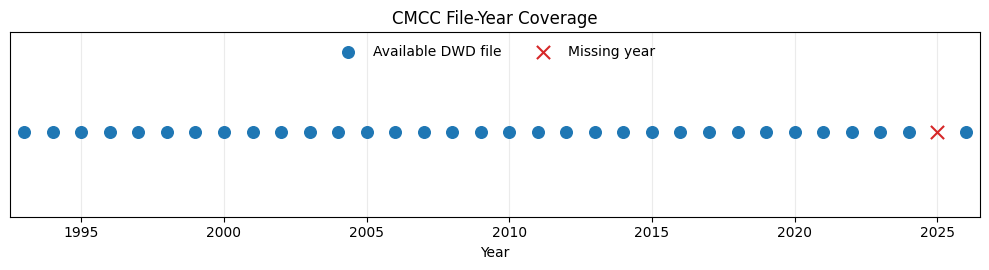

In [22]:

fig, ax = plt.subplots(figsize=(10, 2.8))
if len(file_years) > 0:
    yvals = np.ones(len(file_years))
    ax.scatter(file_years, yvals, s=70, color="#1f77b4", zorder=3, label="Available DWD file")

    if len(missing_years) > 0:
        ax.scatter(missing_years, np.ones(len(missing_years)), s=90, marker="x", color="#d62728", zorder=4, label="Missing year")

    ax.set_xlim(min(expected_years) - 0.5, max(expected_years) + 0.5)
    ax.set_ylim(0.7, 1.35)
    ax.set_yticks([])
    ax.set_xlabel("Year")
    ax.set_title("CMCC File-Year Coverage")
    ax.grid(axis="x", alpha=0.25)
    ax.legend(loc="upper center", ncol=2, frameon=False)
else:
    ax.text(0.5, 0.5, "No CMCC years found", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f1 = os.path.join(diag_dir, "diag_cmcc_year_coverage.png")
plt.tight_layout()
plt.savefig(f1, dpi=150, bbox_inches="tight")
# plt.close(fig)

## Ensemble Size by Year

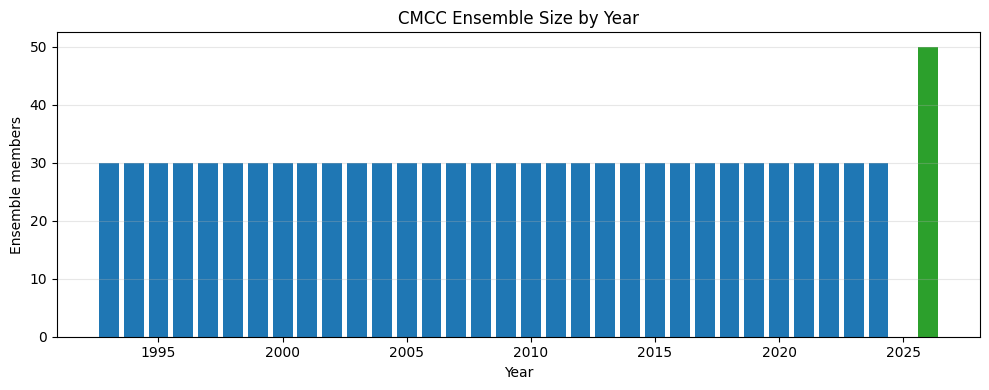

In [23]:
fig, ax = plt.subplots(figsize=(10, 4))
years_ok = [yr for yr in sorted(ens_per_year.keys()) if isinstance(ens_per_year[yr], int)]
if len(years_ok) > 0:
    ens_vals = [ens_per_year[yr] for yr in years_ok]
    colors = ["#2ca02c" if ens_vals[i] == max(ens_vals) else "#1f77b4" for i in range(len(ens_vals))]
    ax.bar(years_ok, ens_vals, color=colors, width=0.8)
    ax.set_xlabel("Year")
    ax.set_ylabel("Ensemble members")
    ax.set_title("CMCC Ensemble Size by Year")
    ax.grid(axis="y", alpha=0.3)
else:
    ax.text(0.5, 0.5, "No valid ensemble-size records", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f2 = os.path.join(diag_dir, "diag_cmcc_ensemble_size_by_year.png")
plt.tight_layout()
plt.savefig(f2, dpi=150, bbox_inches="tight")
# 
# plt.close(fig)

## CHIRPS Domain Climatology (Mean Annual Cycle)

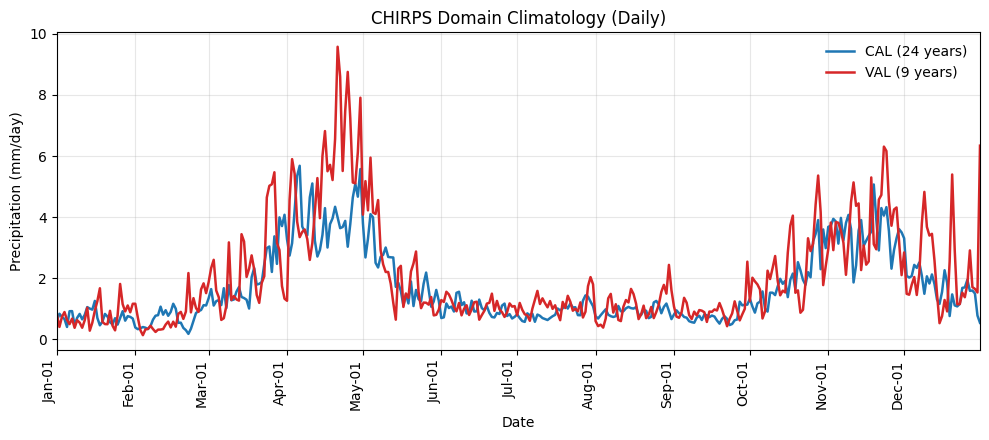

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
if "da_chirps_daily" in globals() and "chirps_years" in globals():
    land_mask = lm.astype(bool) if "lm" in globals() else np.ones((n_lat, n_lon), dtype=bool)
    ts = np.nanmean(np.where(land_mask[None, None, :, :], da_chirps_daily, np.nan), axis=(2, 3))

    year_index = np.asarray(chirps_years, dtype=int)
    cal_mask = np.isin(year_index, CAL_YEARS) if "CAL_YEARS" in globals() else np.zeros_like(year_index, dtype=bool)
    val_mask = np.isin(year_index, VAL_YEARS) if "VAL_YEARS" in globals() else np.zeros_like(year_index, dtype=bool)

    ref_dates = pd.date_range("2000-01-01", periods=ts.shape[1], freq="D")

    plotted = False
    if cal_mask.any():
        cal_clim = np.nanmean(ts[cal_mask], axis=0)
        ax.plot(ref_dates, cal_clim, color="#1f77b4", lw=1.8, label=f"CAL ({int(cal_mask.sum())} years)")
        plotted = True

    if val_mask.any():
        val_clim = np.nanmean(ts[val_mask], axis=0)
        ax.plot(ref_dates, val_clim, color="#d62728", lw=1.8, label=f"VAL ({int(val_mask.sum())} years)")
        plotted = True

    if not plotted:
        all_clim = np.nanmean(ts, axis=0)
        ax.plot(ref_dates, all_clim, color="#1f77b4", lw=1.8, label=f"All years ({len(year_index)})")

    ax.set_xlabel("Date")
    ax.set_ylabel("Precipitation (mm/day)")
    ax.set_title("CHIRPS Domain Climatology (Daily)")
    ax.grid(alpha=0.3)

    import matplotlib.dates as mdates
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    ax.set_xlim(ref_dates[0], ref_dates[-1])
    ax.margins(x=0)
    plt.setp(ax.get_xticklabels(), rotation=90, ha="right")
    ax.legend(frameon=False, loc="upper right")
else:
    ax.text(0.5, 0.5, "Missing da_chirps_daily/chirps_years", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f3 = os.path.join(diag_dir, "diag_chirps_domain_daily_climatology.png")
plt.tight_layout()
plt.savefig(f3, dpi=150, bbox_inches="tight")
# plt.close(fig)


## CHIRPS Annual Total Time Series

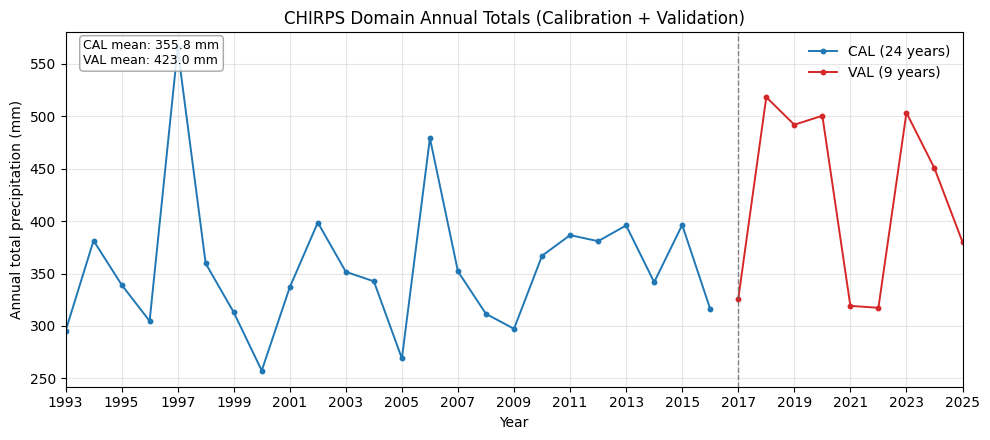

In [25]:
fig, ax = plt.subplots(figsize=(10, 4.5))

try:
    if "da_chirps_daily" not in globals() or "chirps_years" not in globals():
        raise ValueError("Missing da_chirps_daily/chirps_years")

    land_mask = lm.astype(bool) if "lm" in globals() else np.ones((n_lat, n_lon), dtype=bool)

    # Annual totals per year from the reshaped daily CHIRPS cube
    annual_totals = np.nansum(
        np.where(land_mask[None, None, :, :], da_chirps_daily, np.nan),
        axis=1,
    )
    domain_annual = np.nanmean(annual_totals, axis=(1, 2))

    years = np.asarray(chirps_years, dtype=int)
    valid = np.isfinite(domain_annual)
    years = years[valid]
    vals = domain_annual[valid]

    cal_mask = np.isin(years, CAL_YEARS) if "CAL_YEARS" in globals() else np.zeros_like(years, dtype=bool)
    val_mask = np.isin(years, VAL_YEARS) if "VAL_YEARS" in globals() else np.zeros_like(years, dtype=bool)

    if cal_mask.any():
        ax.plot(
            years[cal_mask],
            vals[cal_mask],
            marker="o",
            ms=3.2,
            lw=1.4,
            color="#1f77b4",
            label=f"CAL ({int(cal_mask.sum())} years)",
        )

    if val_mask.any():
        ax.plot(
            years[val_mask],
            vals[val_mask],
            marker="o",
            ms=3.2,
            lw=1.4,
            color="#d62728",
            label=f"VAL ({int(val_mask.sum())} years)",
        )

    if not cal_mask.any() and not val_mask.any():
        ax.plot(years, vals, marker="o", ms=3.2, lw=1.4, color="#9467bd", label="CHIRPS annual total")

    # Add a mean summary box matching the CMCC style.
    mean_lines = []
    if cal_mask.any():
        mean_lines.append(f"CAL mean: {np.nanmean(vals[cal_mask]):.1f} mm")
    if val_mask.any():
        mean_lines.append(f"VAL mean: {np.nanmean(vals[val_mask]):.1f} mm")
    if mean_lines:
        ax.text(
            0.02,
            0.98,
            "\n".join(mean_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
        )

    # Force split marker exactly at 2017
    ax.axvline(2017, color="0.4", ls="--", lw=1.0, alpha=0.8)

    ax.set_xlim(int(years.min()), int(years.max()))
    ax.set_xticks(np.arange(int(years.min()), int(years.max()) + 1, 2))
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual total precipitation (mm)")
    ax.set_title("CHIRPS Domain Annual Totals (Calibration + Validation)")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="upper right")

except Exception as e:
    ax.text(0.5, 0.5, f"Could not build annual totals: {e}", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f4 = os.path.join(diag_dir, "diag_chirps_domain_annual_totals.png")
plt.tight_layout()
plt.savefig(f4, dpi=150, bbox_inches="tight")
# plt.close(fig)


## CHIRPS Feb-Init 183-Day Seasonal Totals (for CMCC-comparable window)

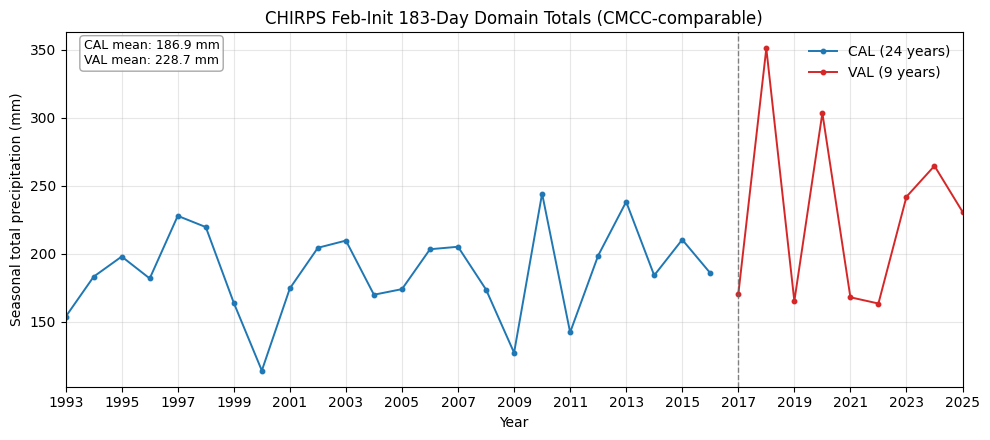

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.5))

try:
    if "da_chirps_daily" not in globals() or "chirps_years" not in globals():
        raise ValueError("Missing da_chirps_daily/chirps_years")

    land_mask = lm.astype(bool) if "lm" in globals() else np.ones((n_lat, n_lon), dtype=bool)

    years = np.asarray(chirps_years, dtype=int)
    season_vals = np.full(len(years), np.nan, dtype=float)

    # Match CMCC comparison window: Feb 1 initialization, 183 forecast days.
    for i, year in enumerate(years):
        dates = pd.date_range(f"{int(year)}-02-01", periods=183, freq="D")
        doys = dates.dayofyear.values - 1  # 0-based index into 366-day padded axis
        window = da_chirps_daily[i, doys, :, :]
        seasonal_total_map = np.nansum(np.where(land_mask[None, :, :], window, np.nan), axis=0)
        season_vals[i] = np.nanmean(seasonal_total_map)

    valid = np.isfinite(season_vals)
    years = years[valid]
    season_vals = season_vals[valid]

    cal_mask = np.isin(years, CAL_YEARS) if "CAL_YEARS" in globals() else np.zeros_like(years, dtype=bool)
    val_mask = np.isin(years, VAL_YEARS) if "VAL_YEARS" in globals() else np.zeros_like(years, dtype=bool)

    if cal_mask.any():
        ax.plot(
            years[cal_mask],
            season_vals[cal_mask],
            marker="o",
            ms=3.2,
            lw=1.4,
            color="#1f77b4",
            label=f"CAL ({int(cal_mask.sum())} years)",
        )

    if val_mask.any():
        ax.plot(
            years[val_mask],
            season_vals[val_mask],
            marker="o",
            ms=3.2,
            lw=1.4,
            color="#d62728",
            label=f"VAL ({int(val_mask.sum())} years)",
        )

    if not cal_mask.any() and not val_mask.any():
        ax.plot(years, season_vals, marker="o", ms=3.2, lw=1.4, color="#9467bd", label="CHIRPS Feb-Init 183-day total")

    mean_lines = []
    if cal_mask.any():
        mean_lines.append(f"CAL mean: {np.nanmean(season_vals[cal_mask]):.1f} mm")
    if val_mask.any():
        mean_lines.append(f"VAL mean: {np.nanmean(season_vals[val_mask]):.1f} mm")
    if mean_lines:
        ax.text(
            0.02,
            0.98,
            "\n".join(mean_lines),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
        )

    ax.axvline(2017, color="0.4", ls="--", lw=1.0, alpha=0.8)
    ax.set_xlim(int(years.min()), int(years.max()))
    ax.set_xticks(np.arange(int(years.min()), int(years.max()) + 1, 2))
    ax.set_xlabel("Year")
    ax.set_ylabel("Seasonal total precipitation (mm)")
    ax.set_title("CHIRPS Feb-Init 183-Day Domain Totals (CMCC-comparable)")
    ax.grid(alpha=0.3)
    ax.legend(frameon=False, loc="upper right")

except Exception as e:
    ax.text(0.5, 0.5, f"Could not build CHIRPS 183-day totals: {e}", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()

f4b = os.path.join(diag_dir, "diag_chirps_domain_feb_init_183day_totals.png")
plt.tight_layout()
plt.savefig(f4b, dpi=150, bbox_inches="tight")
# plt.close(fig)


## Spatial Diagnostic Maps (CAL Mean, VAL Mean, VAL - CAL Difference)

Diagnostic plots saved:
  - outputs\cmcc_v1\plots\diagnostics\diag_cmcc_year_coverage.png
  - outputs\cmcc_v1\plots\diagnostics\diag_cmcc_ensemble_size_by_year.png
  - outputs\cmcc_v1\plots\diagnostics\diag_chirps_domain_daily_climatology.png
  - outputs\cmcc_v1\plots\diagnostics\diag_chirps_domain_annual_totals.png
  - outputs\cmcc_v1\plots\diagnostics\diag_chirps_spatial_cal_val_diff.png


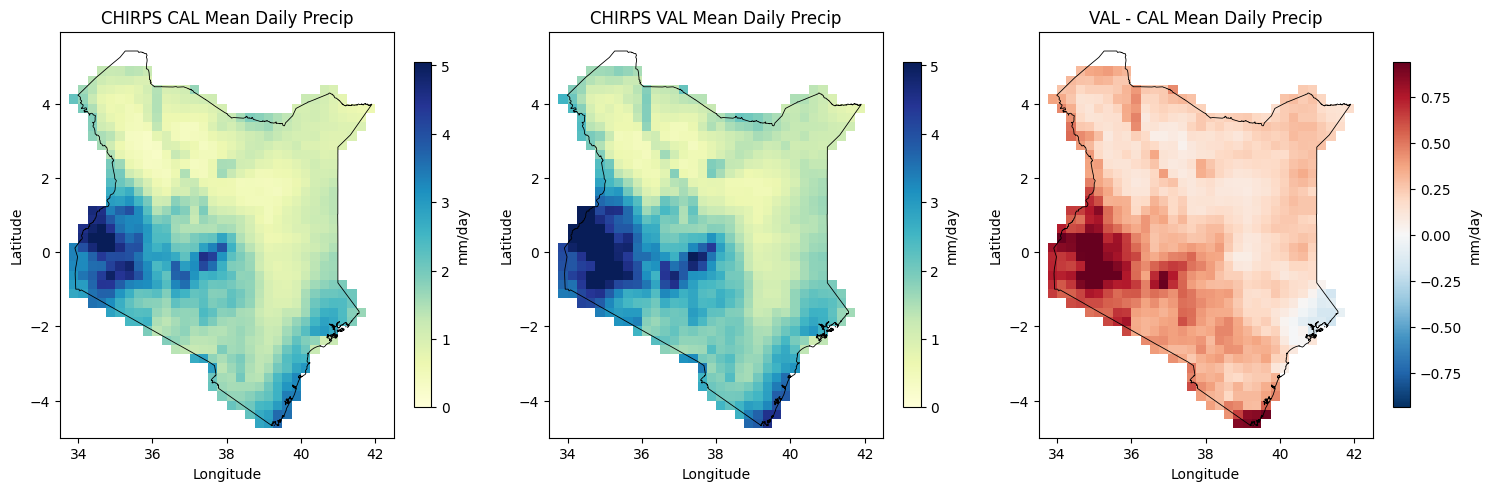

In [27]:
f5 = os.path.join(diag_dir, "diag_chirps_spatial_cal_val_diff.png")
try:
    if "da_chirps_daily" not in globals() or "chirps_years" not in globals():
        raise ValueError("Missing da_chirps_daily/chirps_years")

    land_mask = lm.astype(bool) if "lm" in globals() else np.ones((n_lat, n_lon), dtype=bool)

    years = np.asarray(chirps_years, dtype=int)
    cal_mask = np.isin(years, CAL_YEARS) if "CAL_YEARS" in globals() else np.zeros_like(years, dtype=bool)
    val_mask = np.isin(years, VAL_YEARS) if "VAL_YEARS" in globals() else np.zeros_like(years, dtype=bool)

    cal_map = np.nanmean(
        np.where(land_mask[None, None, :, :], da_chirps_daily[cal_mask], np.nan),
        axis=(0, 1),
    ) if cal_mask.any() else np.full((n_lat, n_lon), np.nan, dtype=float)

    val_map = np.nanmean(
        np.where(land_mask[None, None, :, :], da_chirps_daily[val_mask], np.nan),
        axis=(0, 1),
    ) if val_mask.any() else np.full((n_lat, n_lon), np.nan, dtype=float)

    diff_map = val_map - cal_map

    finite_maps = np.concatenate([
        cal_map[np.isfinite(cal_map)],
        val_map[np.isfinite(val_map)],
    ])
    vmax = np.nanpercentile(finite_maps, 98) if finite_maps.size else np.nan
    vmin = 0.0

    dabs = np.nanpercentile(np.abs(diff_map), 98) if np.isfinite(diff_map).any() else np.nan
    dv = dabs if np.isfinite(dabs) and dabs > 0 else 1.0

    figm, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

    im0 = axes[0].pcolormesh(target_lon, target_lat, cal_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes[0].set_title("CHIRPS CAL Mean Daily Precip")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")
    plt.colorbar(im0, ax=axes[0], shrink=0.85, label="mm/day")

    im1 = axes[1].pcolormesh(target_lon, target_lat, val_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes[1].set_title("CHIRPS VAL Mean Daily Precip")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")
    plt.colorbar(im1, ax=axes[1], shrink=0.85, label="mm/day")

    im2 = axes[2].pcolormesh(target_lon, target_lat, diff_map, shading="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    axes[2].set_title("VAL - CAL Mean Daily Precip")
    axes[2].set_xlabel("Longitude")
    axes[2].set_ylabel("Latitude")
    plt.colorbar(im2, ax=axes[2], shrink=0.85, label="mm/day")

    if "kenya_shp" in globals():
        try:
            for a in axes:
                kenya_shp.boundary.plot(ax=a, color="black", linewidth=0.6)
        except Exception:
            pass

    plt.savefig(f5, dpi=150, bbox_inches="tight")
    # plt.close(figm)
except Exception as e:
    print(f"Spatial diagnostics not created: {e}")

print("Diagnostic plots saved:")
for fp in [f1, f2, f3, f4, f5]:
    print(f"  - {fp}")

In [28]:
# Interactive CHIRPS spatial diagnostics (CAL/VAL) using ipywidgets.
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    raise ImportError(
        "ipywidgets is required for this interactive plot. Install it with: %pip install ipywidgets"
    ) from e

required_vars = ["da_chirps_daily", "chirps_years", "CAL_YEARS", "VAL_YEARS", "target_lat", "target_lon"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing prerequisites for spatial widgets: " + ", ".join(missing) +
        ". Run Stage 1A -- CHIRPS Daily Ingestion and diagnostics setup cells first."
    )

# Build reusable masks and date axis for selecting month windows.
years_all = np.asarray(chirps_years, dtype=int)
cal_mask_all = np.isin(years_all, CAL_YEARS)
val_mask_all = np.isin(years_all, VAL_YEARS)
ref_dates_all = pd.date_range("2000-01-01", periods=da_chirps_daily.shape[1], freq="D")

land_mask_local = lm.astype(bool) if "lm" in globals() else np.ones((len(target_lat), len(target_lon)), dtype=bool)

month_options_spatial = [
    ("All days", 0),
    ("February", 2),
    ("March", 3),
    ("April", 4),
    ("May", 5),
    ("June", 6),
]

period_dd_spatial = widgets.Dropdown(
    options=[("CAL", "CAL"), ("VAL", "VAL")],
    value="CAL",
    description="Period:",
)

month_dd_spatial = widgets.Dropdown(
    options=month_options_spatial,
    value=0,
    description="Month:",
)


def _calc_spatial_map(period_key, month_value):
    if period_key == "CAL":
        period_mask = cal_mask_all
        n_years = int(np.sum(period_mask))
    else:
        period_mask = val_mask_all
        n_years = int(np.sum(period_mask))

    if n_years == 0:
        raise ValueError(f"No years available for period={period_key}")

    if int(month_value) == 0:
        day_mask = np.ones(len(ref_dates_all), dtype=bool)
        month_label = "All days"
    else:
        day_mask = ref_dates_all.month == int(month_value)
        month_label = ref_dates_all[day_mask][0].strftime("%B") if np.any(day_mask) else str(month_value)

    cube = da_chirps_daily[period_mask][:, day_mask, :, :]
    masked_cube = np.where(land_mask_local[None, None, :, :], cube, np.nan)
    out_map = np.nanmean(masked_cube, axis=(0, 1))
    return out_map, n_years, month_label


def _plot_spatial_widget(period, month):
    # Compute both CAL and VAL maps for a shared color range.
    cal_map_local, cal_n, month_label = _calc_spatial_map("CAL", month)
    val_map_local, val_n, _ = _calc_spatial_map("VAL", month)

    finite_pool = np.concatenate([
        cal_map_local[np.isfinite(cal_map_local)],
        val_map_local[np.isfinite(val_map_local)],
    ])
    vmax_local = np.nanpercentile(finite_pool, 98) if finite_pool.size else np.nan

    if period == "CAL":
        show_map = cal_map_local
        ny = cal_n
    else:
        show_map = val_map_local
        ny = val_n

    fig, ax = plt.subplots(figsize=(7.2, 5.1))
    im = ax.pcolormesh(
        target_lon,
        target_lat,
        show_map,
        shading="auto",
        cmap="YlGnBu",
        vmin=0.0,
        vmax=vmax_local,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"CHIRPS {period} Mean Daily Precip - {month_label} ({ny} years)")

    if "kenya_shp" in globals():
        try:
            kenya_shp.boundary.plot(ax=ax, color="black", linewidth=0.6)
        except Exception:
            pass

    cb = plt.colorbar(im, ax=ax, shrink=0.86)
    cb.set_label("mm/day")

    domain_mean = float(np.nanmean(show_map)) if np.isfinite(show_map).any() else float("nan")
    ax.text(
        0.02,
        0.98,
        f"Domain mean: {domain_mean:.2f} mm/day",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
    )

    plt.tight_layout()
    plt.show()


ui_spatial = widgets.HBox([period_dd_spatial, month_dd_spatial])
out_spatial = widgets.interactive_output(
    _plot_spatial_widget,
    {"period": period_dd_spatial, "month": month_dd_spatial},
)
display(ui_spatial, out_spatial)

print("Interactive spatial map ready. Select CAL or VAL and choose a month window.")

Output()

Interactive spatial map ready. Select CAL or VAL and choose a month window.


In [29]:
# Interactive CHIRPS spatial diagnostics by year (CAL/VAL) using ipywidgets.
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    raise ImportError(
        "ipywidgets is required for this interactive plot. Install it with: %pip install ipywidgets"
    ) from e

required_vars = ["da_chirps_daily", "chirps_years", "CAL_YEARS", "VAL_YEARS", "target_lat", "target_lon"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing prerequisites for year-based CHIRPS spatial widget: " + ", ".join(missing) +
        ". Run Stage 1A -- CHIRPS Daily Ingestion first."
    )

years_all = np.asarray(chirps_years, dtype=int)
cal_years_local = [int(y) for y in np.asarray(CAL_YEARS, dtype=int) if int(y) in set(years_all.tolist())]
val_years_local = [int(y) for y in np.asarray(VAL_YEARS, dtype=int) if int(y) in set(years_all.tolist())]
period_to_years_spatial = {
    "CAL": sorted(cal_years_local),
    "VAL": sorted(val_years_local),
}

if not period_to_years_spatial["CAL"] and not period_to_years_spatial["VAL"]:
    raise RuntimeError("No overlapping CHIRPS years found for CAL/VAL in this notebook state.")

# Build date axis for month slicing.
ref_dates_all = pd.date_range("2000-01-01", periods=da_chirps_daily.shape[1], freq="D")
land_mask_local = lm.astype(bool) if "lm" in globals() else np.ones((len(target_lat), len(target_lon)), dtype=bool)

month_options_spatial_year = [
    ("All days", 0),
    ("February", 2),
    ("March", 3),
    ("April", 4),
    ("May", 5),
    ("June", 6),
]

period_dd_spatial_year = widgets.Dropdown(
    options=[("CAL", "CAL"), ("VAL", "VAL")],
    value="CAL" if period_to_years_spatial["CAL"] else "VAL",
    description="Period:",
)

year_dd_spatial = widgets.Dropdown(
    options=period_to_years_spatial[period_dd_spatial_year.value],
    value=period_to_years_spatial[period_dd_spatial_year.value][0],
    description="Year:",
)

month_dd_spatial_year = widgets.Dropdown(
    options=month_options_spatial_year,
    value=0,
    description="Month:",
)


def _update_year_options_spatial(change=None):
    p = period_dd_spatial_year.value
    years_here = period_to_years_spatial.get(p, [])
    year_dd_spatial.options = years_here
    year_dd_spatial.value = years_here[0] if years_here else None


def _calc_map_for_year(year_value, month_value):
    idx = np.where(years_all == int(year_value))[0]
    if idx.size == 0:
        raise ValueError(f"Year {year_value} not found in CHIRPS array")

    if int(month_value) == 0:
        day_mask = np.ones(len(ref_dates_all), dtype=bool)
        month_label = "All days"
    else:
        day_mask = ref_dates_all.month == int(month_value)
        month_label = ref_dates_all[day_mask][0].strftime("%B") if np.any(day_mask) else str(month_value)

    cube = da_chirps_daily[int(idx[0]), day_mask, :, :]
    cube = np.where(land_mask_local[None, :, :], cube, np.nan)
    out_map = np.nanmean(cube, axis=0)
    return out_map, month_label


def _plot_spatial_year_widget(period, year, month):
    if year is None:
        print(f"No years available for period={period}")
        return

    # Use shared scale from CAL+VAL means for this month to keep comparisons consistent.
    cal_maps, val_maps = [], []
    for yy in period_to_years_spatial.get("CAL", []):
        try:
            m, _ = _calc_map_for_year(yy, month)
            cal_maps.append(m)
        except Exception:
            pass
    for yy in period_to_years_spatial.get("VAL", []):
        try:
            m, _ = _calc_map_for_year(yy, month)
            val_maps.append(m)
        except Exception:
            pass

    cal_ref = np.nanmean(np.stack(cal_maps, axis=0), axis=0) if cal_maps else np.full((len(target_lat), len(target_lon)), np.nan)
    val_ref = np.nanmean(np.stack(val_maps, axis=0), axis=0) if val_maps else np.full((len(target_lat), len(target_lon)), np.nan)

    finite_pool = np.concatenate([
        cal_ref[np.isfinite(cal_ref)],
        val_ref[np.isfinite(val_ref)],
    ]) if (np.isfinite(cal_ref).any() or np.isfinite(val_ref).any()) else np.array([])

    vmax_local = np.nanpercentile(finite_pool, 98) if finite_pool.size else np.nan

    show_map, month_label = _calc_map_for_year(year, month)

    fig, ax = plt.subplots(figsize=(7.2, 5.1))
    im = ax.pcolormesh(
        target_lon,
        target_lat,
        show_map,
        shading="auto",
        cmap="YlGnBu",
        vmin=0.0,
        vmax=vmax_local,
    )
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(f"CHIRPS {period} Year {int(year)} Mean Daily Precip - {month_label}")

    if "kenya_shp" in globals():
        try:
            kenya_shp.boundary.plot(ax=ax, color="black", linewidth=0.6)
        except Exception:
            pass

    cb = plt.colorbar(im, ax=ax, shrink=0.86)
    cb.set_label("mm/day")

    domain_mean = float(np.nanmean(show_map)) if np.isfinite(show_map).any() else float("nan")
    ax.text(
        0.02,
        0.98,
        f"Domain mean: {domain_mean:.2f} mm/day",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
    )

    plt.tight_layout()
    plt.show()


period_dd_spatial_year.observe(_update_year_options_spatial, names="value")
_update_year_options_spatial()

ui_spatial_year = widgets.HBox([period_dd_spatial_year, year_dd_spatial, month_dd_spatial_year])
out_spatial_year = widgets.interactive_output(
    _plot_spatial_year_widget,
    {"period": period_dd_spatial_year, "year": year_dd_spatial, "month": month_dd_spatial_year},
)
display(ui_spatial_year, out_spatial_year)

print("Interactive CHIRPS spatial-by-year map ready. Choose CAL/VAL, year, and month.")

Output()

Interactive CHIRPS spatial-by-year map ready. Choose CAL/VAL, year, and month.


## CMCC Seasonal Diagnostics and Spatial Comparison

Using hindcast member cap from first year: 30
CMCC diagnostic plots saved:
  - outputs\cmcc_v1\plots\diagnostics\diag_cmcc_seasonal_totals_cal_val_timeseries.png
  - outputs\cmcc_v1\plots\diagnostics\diag_cmcc_spatial_cal_val_diff.png
  - outputs\cmcc_v1\plots\diagnostics\diag_cmcc_domain_daily_climatology.png


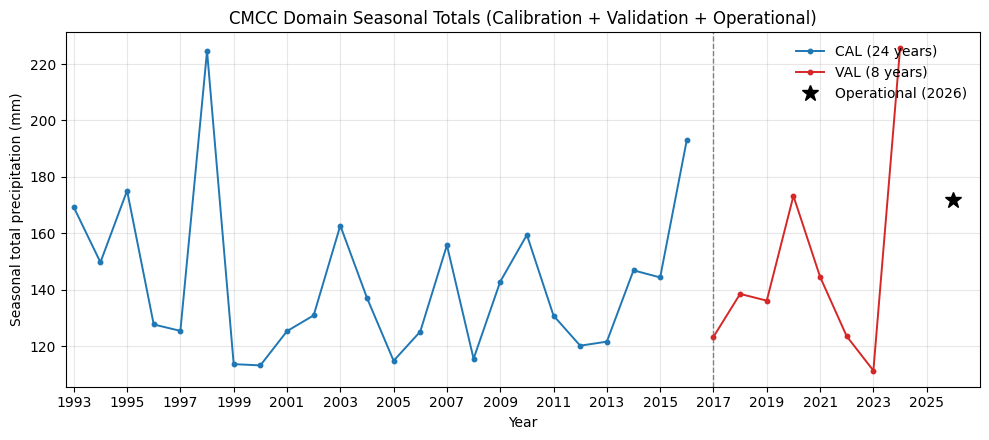

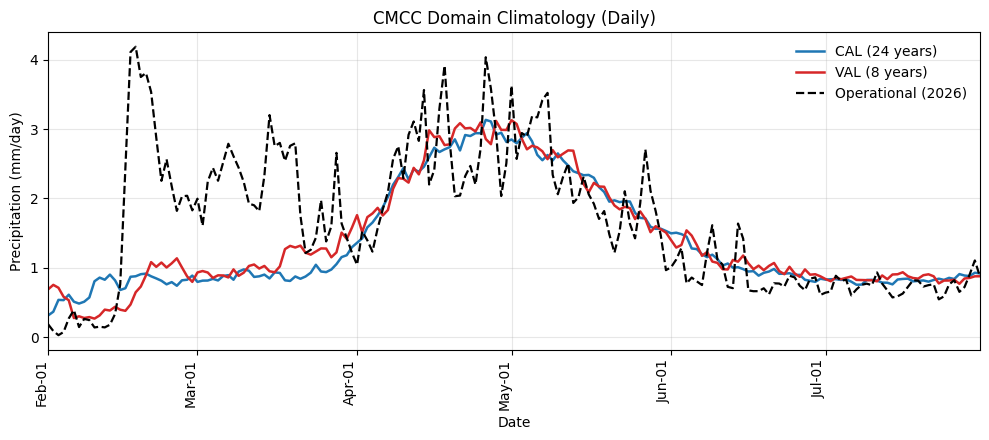

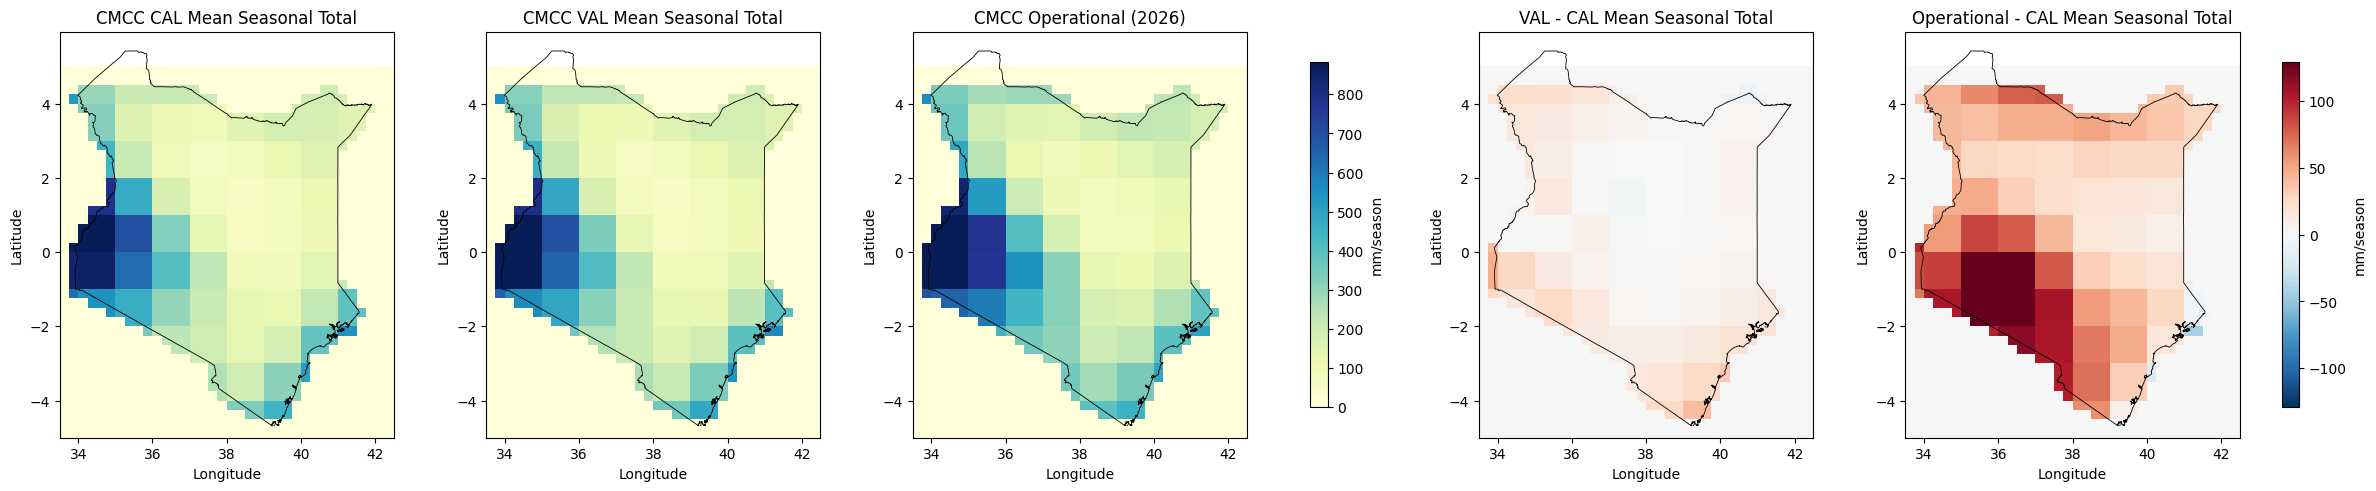

In [30]:
# CMCC seasonal diagnostics: CAL vs VAL (+ operational year)
f6 = os.path.join(diag_dir, "diag_cmcc_seasonal_totals_cal_val_timeseries.png")
f7 = os.path.join(diag_dir, "diag_cmcc_spatial_cal_val_diff.png")
f8 = os.path.join(diag_dir, "diag_cmcc_domain_daily_climatology.png")


def _find_existing_dims(dims, candidates):
    return [name for name in candidates if name in dims]


def _to_mm_per_day(da, accum_dim):
    units = str(da.attrs.get("units", "")).strip().lower()

    cumulative_m = {"m", "metres", "meter"}
    cumulative_mm = {"kg m-2", "kg/m2", "mm"}
    rate_per_s = {"m s-1", "m/s", "kg m-2 s-1", "kg/(m2*s)", "mm/s"}

    if units in cumulative_m:
        if accum_dim is not None and da.sizes.get(accum_dim, 0) > 1:
            return da.diff(accum_dim, label="upper") * 1000.0
        return da * 1000.0

    if units in cumulative_mm:
        if accum_dim is not None and da.sizes.get(accum_dim, 0) > 1:
            return da.diff(accum_dim, label="upper")
        return da

    if units in rate_per_s:
        if units in {"m s-1", "m/s"}:
            return da * 86400.0 * 1000.0
        return da * 86400.0

    return da


def _infer_hindcast_member_cap(file_map, file_years):
    if not file_years:
        return None

    first_year = int(sorted(file_years)[0])
    first_path = file_map.get(first_year)
    if first_path is None:
        return None

    with xr.open_dataset(first_path, decode_times=False) as ds0:
        if CMCC_VAR in ds0.data_vars:
            da0 = ds0[CMCC_VAR]
        else:
            da0 = list(ds0.data_vars.values())[0]

        ensemble_dims = _find_existing_dims(
            da0.dims,
            ["number", "member", "ensemble", "realization", "ensemble_member"],
        )
        if not ensemble_dims:
            return None

        sizes = [int(da0.sizes[d]) for d in ensemble_dims if d in da0.sizes]
        return int(min(sizes)) if sizes else None


def _load_cmcc_seasonal_map_domain_and_daily(year, path):
    ds = xr.open_dataset(path, decode_times=False)
    try:
        if CMCC_VAR not in ds.data_vars:
            raise ValueError(f"Variable '{CMCC_VAR}' not found in {os.path.basename(path)}")

        da = ds[CMCC_VAR]

        lat_name = "latitude" if "latitude" in da.coords else ("lat" if "lat" in da.coords else None)
        lon_name = "longitude" if "longitude" in da.coords else ("lon" if "lon" in da.coords else None)
        if lat_name is None or lon_name is None:
            raise ValueError("Could not find lat/lon coordinates in CMCC file")

        da = da.rename({lat_name: "lat", lon_name: "lon"})

        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        # Use hindcast member size (from first year) as cap for consistency.
        ensemble_dims = _find_existing_dims(
            da.dims,
            ["number", "member", "ensemble", "realization", "ensemble_member"],
        )
        if ensemble_dims:
            cap = globals().get("hindcast_member_cap", None)
            for ed in ensemble_dims:
                n_ed = int(da.sizes.get(ed, 0))
                if cap is not None and cap > 0 and n_ed > cap:
                    da = da.isel({ed: slice(0, cap)})
            da = da.mean(dim=ensemble_dims, skipna=True)

        accum_dim = None
        for cand in ["forecast_period", "step", "lead_time", "forecast_day", "day", "time"]:
            if cand in da.dims and da.sizes.get(cand, 0) > 1:
                accum_dim = cand
                break

        da_mm_day = _to_mm_per_day(da, accum_dim)

        if accum_dim is None:
            da_mm_day = da_mm_day.expand_dims({"day_idx": [0]})
            accum_dim = "day_idx"

        for d in list(da_mm_day.dims):
            if d not in ("lat", "lon", accum_dim) and da_mm_day.sizes.get(d, 0) == 1:
                da_mm_day = da_mm_day.isel({d: 0}, drop=True)

        extra_dims = [d for d in da_mm_day.dims if d not in ("lat", "lon", accum_dim)]
        if extra_dims:
            da_mm_day = da_mm_day.mean(dim=extra_dims, skipna=True)

        da_mm_day = da_mm_day.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )

        land_mask = lm.astype(bool) if "lm" in globals() else np.ones((n_lat, n_lon), dtype=bool)
        lm_da = xr.DataArray(land_mask, dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon})
        da_mm_day = da_mm_day.where(lm_da)

        daily_domain = da_mm_day.mean(dim=("lat", "lon"), skipna=True)
        daily_vals = np.asarray(daily_domain.values, dtype=float)

        seasonal_total = da_mm_day.sum(dim=accum_dim, skipna=True)
        map_vals = np.asarray(seasonal_total.values, dtype=float)
        if map_vals.ndim != 2:
            raise ValueError(f"Expected 2-D map after collapsing dims, got shape {map_vals.shape}")

        domain_val = float(np.nanmean(map_vals))
        return int(year), map_vals, domain_val, daily_vals
    finally:
        ds.close()


def _stack_daily_for_years(years_subset, year_to_daily):
    if len(years_subset) == 0:
        return None
    series = [np.asarray(year_to_daily[int(y)], dtype=float) for y in years_subset if int(y) in year_to_daily]
    if not series:
        return None
    nmin = min(len(s) for s in series)
    if nmin <= 0:
        return None
    return np.stack([s[:nmin] for s in series], axis=0)


try:
    year_map_values = {}
    year_domain_values = {}
    year_daily_values = {}

    hindcast_member_cap = _infer_hindcast_member_cap(file_map, file_years)
    if hindcast_member_cap is not None:
        print(f"Using hindcast member cap from first year: {hindcast_member_cap}")

    for yr in sorted(file_map.keys()):
        try:
            y, mvals, dval, dseries = _load_cmcc_seasonal_map_domain_and_daily(yr, file_map[yr])
            year_map_values[y] = mvals
            year_domain_values[y] = dval
            year_daily_values[y] = dseries
        except Exception as e:
            print(f"Skipping CMCC year {yr}: {e}")

    if not year_map_values:
        raise ValueError("No CMCC seasonal maps could be computed")

    cmcc_years = np.array(sorted(year_map_values.keys()), dtype=int)
    cmcc_vals = np.array([year_domain_values[y] for y in cmcc_years], dtype=float)

    op_year = int(OP_YEAR) if "OP_YEAR" in globals() else None

    cmcc_cal_mask = np.isin(cmcc_years, CAL_YEARS) if "CAL_YEARS" in globals() else np.zeros_like(cmcc_years, dtype=bool)
    cmcc_val_mask = np.isin(cmcc_years, VAL_YEARS) if "VAL_YEARS" in globals() else np.zeros_like(cmcc_years, dtype=bool)
    cmcc_op_mask = (cmcc_years == op_year) if op_year is not None else np.zeros_like(cmcc_years, dtype=bool)

    fig_ts, ax_ts = plt.subplots(figsize=(10, 4.5))
    if cmcc_cal_mask.any():
        ax_ts.plot(cmcc_years[cmcc_cal_mask], cmcc_vals[cmcc_cal_mask], marker="o", ms=3.2, lw=1.4, color="#1f77b4", label=f"CAL ({int(cmcc_cal_mask.sum())} years)")
    if cmcc_val_mask.any():
        ax_ts.plot(cmcc_years[cmcc_val_mask], cmcc_vals[cmcc_val_mask], marker="o", ms=3.2, lw=1.4, color="#d62728", label=f"VAL ({int(cmcc_val_mask.sum())} years)")
    if cmcc_op_mask.any():
        ax_ts.plot(cmcc_years[cmcc_op_mask], cmcc_vals[cmcc_op_mask], marker="*", ms=12, lw=0, color="#000000", label=f"Operational ({op_year})", zorder=5)

    ax_ts.axvline(2017, color="0.4", ls="--", lw=1.0, alpha=0.8)
    if cmcc_years.size > 0:
        xmin = int(cmcc_years.min())
        xmax = int(cmcc_years.max())
        if op_year is not None:
            xmax = max(xmax, int(op_year))
        ax_ts.set_xlim(xmin - 0.3, xmax + 1.0)
        ax_ts.set_xticks(np.arange(xmin, xmax + 1, 2))

    ax_ts.set_xlabel("Year")
    ax_ts.set_ylabel("Seasonal total precipitation (mm)")
    ax_ts.set_title("CMCC Domain Seasonal Totals (Calibration + Validation + Operational)")
    ax_ts.grid(alpha=0.3)
    ax_ts.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.savefig(f6, dpi=150, bbox_inches="tight")

    cal_stack = _stack_daily_for_years(cmcc_years[cmcc_cal_mask], year_daily_values)
    val_stack = _stack_daily_for_years(cmcc_years[cmcc_val_mask], year_daily_values)
    op_stack = _stack_daily_for_years(cmcc_years[cmcc_op_mask], year_daily_values)

    day_lengths = [arr.shape[1] for arr in [cal_stack, val_stack, op_stack] if arr is not None]
    if day_lengths:
        nday = min(day_lengths)
        fig_daily, ax_daily = plt.subplots(figsize=(10, 4.5))
        ref_dates = pd.date_range(f"2000-{int(INIT_MONTH):02d}-{int(INIT_DAY):02d}", periods=nday, freq="D")

        if cal_stack is not None:
            ax_daily.plot(ref_dates, np.nanmean(cal_stack[:, :nday], axis=0), color="#1f77b4", lw=1.8, label=f"CAL ({cal_stack.shape[0]} years)")
        if val_stack is not None:
            ax_daily.plot(ref_dates, np.nanmean(val_stack[:, :nday], axis=0), color="#d62728", lw=1.8, label=f"VAL ({val_stack.shape[0]} years)")
        if op_stack is not None:
            ax_daily.plot(ref_dates, np.nanmean(op_stack[:, :nday], axis=0), color="#000000", lw=1.6, ls="--", label=f"Operational ({op_year})")

        import matplotlib.dates as mdates
        ax_daily.set_xlabel("Date")
        ax_daily.set_ylabel("Precipitation (mm/day)")
        ax_daily.set_title("CMCC Domain Climatology (Daily)")
        ax_daily.grid(alpha=0.3)
        ax_daily.legend(frameon=False, loc="upper right")
        ax_daily.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
        ax_daily.xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
        ax_daily.set_xlim(ref_dates[0], ref_dates[-1])
        ax_daily.margins(x=0)
        plt.setp(ax_daily.get_xticklabels(), rotation=90, ha="right")
        plt.tight_layout()
        plt.savefig(f8, dpi=150, bbox_inches="tight")

    cal_maps = np.stack([year_map_values[int(y)] for y in cmcc_years[cmcc_cal_mask]], axis=0) if cmcc_cal_mask.any() else None
    val_maps = np.stack([year_map_values[int(y)] for y in cmcc_years[cmcc_val_mask]], axis=0) if cmcc_val_mask.any() else None
    cal_map = np.nanmean(cal_maps, axis=0) if cal_maps is not None else np.full((n_lat, n_lon), np.nan, dtype=float)
    val_map = np.nanmean(val_maps, axis=0) if val_maps is not None else np.full((n_lat, n_lon), np.nan, dtype=float)
    op_map = year_map_values[int(op_year)] if (op_year is not None and op_year in year_map_values) else np.full((n_lat, n_lon), np.nan, dtype=float)

    diff_val_cal = val_map - cal_map
    diff_op_cal = op_map - cal_map

    finite_maps = np.concatenate([cal_map[np.isfinite(cal_map)], val_map[np.isfinite(val_map)], op_map[np.isfinite(op_map)]])
    vmax = np.nanpercentile(finite_maps, 98) if finite_maps.size else np.nan
    vmin = 0.0
    diff_pool = np.concatenate([np.abs(diff_val_cal[np.isfinite(diff_val_cal)]), np.abs(diff_op_cal[np.isfinite(diff_op_cal)])])
    dabs = np.nanpercentile(diff_pool, 98) if diff_pool.size else np.nan
    dv = dabs if np.isfinite(dabs) and dabs > 0 else 1.0

    fig_sp, axes_sp = plt.subplots(1, 5, figsize=(24, 4.8), constrained_layout=True)
    im0 = axes_sp[0].pcolormesh(target_lon, target_lat, cal_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes_sp[0].set_title("CMCC CAL Mean Seasonal Total")
    im1 = axes_sp[1].pcolormesh(target_lon, target_lat, val_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes_sp[1].set_title("CMCC VAL Mean Seasonal Total")
    im_op = axes_sp[2].pcolormesh(target_lon, target_lat, op_map, shading="auto", cmap="YlGnBu", vmin=vmin, vmax=vmax)
    axes_sp[2].set_title(f"CMCC Operational ({op_year})")
    im2 = axes_sp[3].pcolormesh(target_lon, target_lat, diff_val_cal, shading="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    axes_sp[3].set_title("VAL - CAL Mean Seasonal Total")
    im3 = axes_sp[4].pcolormesh(target_lon, target_lat, diff_op_cal, shading="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    axes_sp[4].set_title("Operational - CAL Mean Seasonal Total")

    for a in axes_sp:
        a.set_xlabel("Longitude")
        a.set_ylabel("Latitude")

    fig_sp.colorbar(im_op, ax=axes_sp[:3], shrink=0.85, label="mm/season")
    fig_sp.colorbar(im3, ax=axes_sp[3:], shrink=0.85, label="mm/season")

    if "kenya_shp" in globals():
        try:
            for a in axes_sp:
                kenya_shp.boundary.plot(ax=a, color="black", linewidth=0.6)
        except Exception:
            pass

    plt.savefig(f7, dpi=150, bbox_inches="tight")

    print("CMCC diagnostic plots saved:")
    print(f"  - {f6}")
    print(f"  - {f7}")
    if os.path.exists(f8):
        print(f"  - {f8}")

except Exception as e:
    print(f"CMCC diagnostics not created: {e}")

## Interactive CMCC Member Diagnostics

Use the controls to choose CAL, VAL, or OP and inspect the domain daily climatology for an individual ensemble member.

In [31]:
# Interactive CMCC member viewer: select period (CAL/VAL/OP) and member index.
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    raise ImportError(
        "ipywidgets is required for this interactive plot. Install it with: %pip install ipywidgets"
    ) from e


def _local_find_existing_dims(dims, candidates):
    return [name for name in candidates if name in dims]


def _local_to_mm_per_day(da, accum_dim):
    units = str(da.attrs.get("units", "")).strip().lower()

    cumulative_m = {"m", "metres", "meter"}
    cumulative_mm = {"kg m-2", "kg/m2", "mm"}
    rate_per_s = {"m s-1", "m/s", "kg m-2 s-1", "kg/(m2*s)", "mm/s"}

    if units in cumulative_m:
        if accum_dim is not None and da.sizes.get(accum_dim, 0) > 1:
            return da.diff(accum_dim, label="upper") * 1000.0
        return da * 1000.0

    if units in cumulative_mm:
        if accum_dim is not None and da.sizes.get(accum_dim, 0) > 1:
            return da.diff(accum_dim, label="upper")
        return da

    if units in rate_per_s:
        if units in {"m s-1", "m/s"}:
            return da * 86400.0 * 1000.0
        return da * 86400.0

    return da


def _load_member_daily_domain_series(path, member_cap=None):
    with xr.open_dataset(path, decode_times=False) as ds:
        if CMCC_VAR in ds.data_vars:
            da = ds[CMCC_VAR]
        else:
            da = list(ds.data_vars.values())[0]

        lat_name = "latitude" if "latitude" in da.coords else ("lat" if "lat" in da.coords else None)
        lon_name = "longitude" if "longitude" in da.coords else ("lon" if "lon" in da.coords else None)
        if lat_name is None or lon_name is None:
            raise ValueError("Could not find lat/lon coordinates in CMCC file")

        da = da.rename({lat_name: "lat", lon_name: "lon"})
        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        ens_candidates = ["number", "member", "ensemble", "realization", "realization_index", "ensemble_member"]
        ens_dims = _local_find_existing_dims(da.dims, ens_candidates)

        if len(ens_dims) == 0:
            da = da.expand_dims({"member_idx": [0]})
            member_dim = "member_idx"
        elif len(ens_dims) == 1:
            member_dim = ens_dims[0]
        else:
            da = da.stack(member_idx=ens_dims)
            member_dim = "member_idx"

        if member_cap is not None and member_cap > 0 and da.sizes.get(member_dim, 0) > member_cap:
            da = da.isel({member_dim: slice(0, int(member_cap))})

        accum_dim = None
        for cand in ["forecast_period", "step", "lead_time", "forecast_day", "day", "time"]:
            if cand in da.dims and da.sizes.get(cand, 0) > 1:
                accum_dim = cand
                break

        da_mm_day = _local_to_mm_per_day(da, accum_dim)

        if accum_dim is None:
            da_mm_day = da_mm_day.expand_dims({"day_idx": [0]})
            accum_dim = "day_idx"

        keep_dims = {member_dim, accum_dim, "lat", "lon"}
        for d in list(da_mm_day.dims):
            if d not in keep_dims and da_mm_day.sizes.get(d, 0) == 1:
                da_mm_day = da_mm_day.isel({d: 0}, drop=True)

        extra_dims = [d for d in da_mm_day.dims if d not in keep_dims]
        if extra_dims:
            da_mm_day = da_mm_day.mean(dim=extra_dims, skipna=True)

        da_mm_day = da_mm_day.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )

        land_mask = lm.astype(bool) if "lm" in globals() else np.ones((len(target_lat), len(target_lon)), dtype=bool)
        lm_da = xr.DataArray(land_mask, dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon})
        da_mm_day = da_mm_day.where(lm_da)

        out = da_mm_day.mean(dim=("lat", "lon"), skipna=True)
        out = out.transpose(member_dim, accum_dim)
        return np.asarray(out.values, dtype=float)


available_years = sorted(int(y) for y in file_map.keys())
cal_years_local = [int(y) for y in np.asarray(CAL_YEARS, dtype=int) if int(y) in file_map]
val_years_local = [int(y) for y in np.asarray(VAL_YEARS, dtype=int) if int(y) in file_map]
op_year_local = int(OP_YEAR) if int(OP_YEAR) in file_map else None

period_to_years = {
    "CAL": cal_years_local,
    "VAL": val_years_local,
    "OP": [op_year_local] if op_year_local is not None else [],
}

member_cap_local = globals().get("hindcast_member_cap", None)
if member_cap_local is None and available_years:
    try:
        with xr.open_dataset(file_map[available_years[0]], decode_times=False) as ds_first:
            da_first = ds_first[CMCC_VAR] if CMCC_VAR in ds_first.data_vars else list(ds_first.data_vars.values())[0]
            ens_dims_first = _local_find_existing_dims(
                da_first.dims,
                ["number", "member", "ensemble", "realization", "realization_index", "ensemble_member"],
            )
            if ens_dims_first:
                member_cap_local = int(min(int(da_first.sizes[d]) for d in ens_dims_first))
    except Exception:
        member_cap_local = None

period_member_daily = {}
for period_name, years_list in period_to_years.items():
    mats = []
    for y in years_list:
        try:
            mats.append(_load_member_daily_domain_series(file_map[int(y)], member_cap=member_cap_local))
        except Exception as e:
            print(f"Skipping {period_name} year {y}: {e}")

    if not mats:
        continue

    nmem = min(m.shape[0] for m in mats)
    nday = min(m.shape[1] for m in mats)
    mats_trim = [m[:nmem, :nday] for m in mats]
    period_member_daily[period_name] = np.nanmean(np.stack(mats_trim, axis=0), axis=0)

if not period_member_daily:
    raise ValueError("No period data available for interactive member plot.")

max_members = max(v.shape[0] for v in period_member_daily.values())

period_dd = widgets.Dropdown(
    options=[p for p in ["CAL", "VAL", "OP"] if p in period_member_daily],
    value=[p for p in ["CAL", "VAL", "OP"] if p in period_member_daily][0],
    description="Period:",
)

member_dd = widgets.Dropdown(
    options=list(range(1, max_members + 1)),
    value=1,
    description="Member:",
)


def _update_member_options(change=None):
    p = period_dd.value
    nm = int(period_member_daily[p].shape[0])
    member_dd.options = list(range(1, max(1, nm) + 1))
    member_dd.value = 1


def _plot_member(period, member):
    arr = period_member_daily[period]  # [member, day]
    nm, nd = arr.shape
    idx = min(max(int(member) - 1, 0), nm - 1)

    ref_dates = pd.date_range(
        f"2000-{int(INIT_MONTH):02d}-{int(INIT_DAY):02d}",
        periods=nd,
        freq="D",
    )

    plt.figure(figsize=(10, 4.5))
    plt.plot(ref_dates, arr[idx], lw=2.0, color="#1f77b4", label=f"{period} member {idx + 1}")
    plt.plot(ref_dates, np.nanmean(arr, axis=0), lw=1.5, ls="--", color="#444444", label=f"{period} member mean")

    import matplotlib.dates as mdates

    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.xlim(ref_dates[0], ref_dates[-1])
    plt.margins(x=0)
    plt.xticks(rotation=90)
    plt.grid(alpha=0.3)
    plt.ylabel("Precipitation (mm/day)")
    plt.xlabel("Date")
    plt.title(f"CMCC Domain Daily Climatology by Member - {period}")
    plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()


period_dd.observe(_update_member_options, names="value")
_update_member_options()

ui = widgets.HBox([period_dd, member_dd])
out = widgets.interactive_output(_plot_member, {"period": period_dd, "member": member_dd})
display(ui, out)

print("Interactive member plot ready. Select Period and Member from the dropdowns.")
if member_cap_local is not None:
    print(f"Member cap used: {member_cap_local}")


Output()

Interactive member plot ready. Select Period and Member from the dropdowns.
Member cap used: 30


## Interactive CMCC Member Diagnostics (Feb-June Only)

This view mirrors the member diagnostics above, but restricts the time axis to February through June only.

In [32]:
# Interactive CMCC member viewer: selected month only, with Period, Member, and Month dropdowns.
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    raise ImportError(
        "ipywidgets is required for this interactive plot. Install it with: %pip install ipywidgets"
    ) from e

if "period_member_daily" not in globals() or not period_member_daily:
    raise RuntimeError(
        "Run the interactive CMCC member diagnostics cell above first so period_member_daily is available."
    )

period_dd_monthly = widgets.Dropdown(
    options=[p for p in ["CAL", "VAL", "OP"] if p in period_member_daily],
    value=[p for p in ["CAL", "VAL", "OP"] if p in period_member_daily][0],
    description="Period:",
)

max_members_monthly = max(v.shape[0] for v in period_member_daily.values())
member_dd_monthly = widgets.Dropdown(
    options=list(range(1, max_members_monthly + 1)),
    value=1,
    description="Member:",
)

month_options = [
    ("February", 2),
    ("March", 3),
    ("April", 4),
    ("May", 5),
    ("June", 6),
]
month_dd = widgets.Dropdown(
    options=month_options,
    value=2,
    description="Month:",
)


def _update_member_options_monthly(change=None):
    period_name = period_dd_monthly.value
    n_members = int(period_member_daily[period_name].shape[0])
    member_dd_monthly.options = list(range(1, max(1, n_members) + 1))
    member_dd_monthly.value = 1


def _plot_member_monthly(period, member, month):
    arr = period_member_daily[period]
    n_members, n_days = arr.shape
    member_idx = min(max(int(member) - 1, 0), n_members - 1)

    ref_dates = pd.date_range(
        f"2000-{int(INIT_MONTH):02d}-{int(INIT_DAY):02d}",
        periods=n_days,
        freq="D",
    )
    month_mask = ref_dates.month == int(month)
    if not np.any(month_mask):
        raise ValueError(f"No dates found for month={month} in the forecast window")

    ref_dates_sub = ref_dates[month_mask]
    member_series = arr[member_idx, month_mask]
    period_mean = np.nanmean(arr, axis=0)[month_mask]

    plt.figure(figsize=(10, 4.5))
    plt.plot(ref_dates_sub, member_series, lw=2.0, color="#1f77b4", marker="o", ms=3, label=f"{period} member {member_idx + 1}")
    plt.plot(ref_dates_sub, period_mean, lw=1.5, ls="--", color="#444444", marker="o", ms=2.5, label=f"{period} member mean")

    import matplotlib.dates as mdates

    plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b-%d"))
    plt.xlim(ref_dates_sub[0], ref_dates_sub[-1])
    plt.margins(x=0)
    plt.xticks(rotation=90)
    plt.grid(alpha=0.3)
    plt.ylabel("Precipitation (mm/day)")
    plt.xlabel("Date")
    plt.title(f"CMCC Daily Values by Member - {period} ({ref_dates_sub[0].strftime('%B')})")
    plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()


period_dd_monthly.observe(_update_member_options_monthly, names="value")
_update_member_options_monthly()

ui_monthly = widgets.HBox([period_dd_monthly, member_dd_monthly, month_dd])
out_monthly = widgets.interactive_output(
    _plot_member_monthly,
    {"period": period_dd_monthly, "member": member_dd_monthly, "month": month_dd},
)
display(ui_monthly, out_monthly)

print("Interactive monthly member plot ready. Select Period, Member, and Month from the dropdowns.")

Output()

Interactive monthly member plot ready. Select Period, Member, and Month from the dropdowns.


## CMCC Companion Visualizations (Original Plot Unchanged)

These additional plots improve interpretability while keeping the main CMCC seasonal totals plot unchanged.

In [44]:
# Companion visualization prep (shared variables for the next plot cells).
required_base = ["file_map", "CMCC_VAR", "target_lat", "target_lon", "PLOT_DIR", "INIT_MONTH", "INIT_DAY"]
if not all(v in globals() for v in required_base):
    raise RuntimeError(
        "Missing base variables. Run the CMCC diagnostics setup cells first (file_map/CMCC_VAR/target grid)."
    )

if "diag_dir" not in globals():
    diag_dir = os.path.join(PLOT_DIR, "diagnostics")
    os.makedirs(diag_dir, exist_ok=True)


def _to_mm_per_day_local(da, accum_dim):
    units = str(da.attrs.get("units", "")).strip().lower()
    if units in {"m", "metres", "meter"}:
        return da.diff(accum_dim, label="upper") * 1000.0 if (accum_dim is not None and da.sizes.get(accum_dim, 0) > 1) else da * 1000.0
    if units in {"kg m-2", "kg/m2", "mm"}:
        return da.diff(accum_dim, label="upper") if (accum_dim is not None and da.sizes.get(accum_dim, 0) > 1) else da
    if units in {"m s-1", "m/s", "kg m-2 s-1", "kg/(m2*s)", "mm/s"}:
        return da * 86400.0 * 1000.0 if units in {"m s-1", "m/s"} else da * 86400.0
    return da


def _load_ensemble_daily_domain_series_local(path):
    with xr.open_dataset(path, decode_times=False) as ds:
        da = ds[CMCC_VAR] if CMCC_VAR in ds.data_vars else list(ds.data_vars.values())[0]

        lat_name = "latitude" if "latitude" in da.coords else ("lat" if "lat" in da.coords else None)
        lon_name = "longitude" if "longitude" in da.coords else ("lon" if "lon" in da.coords else None)
        if lat_name is None or lon_name is None:
            raise ValueError("No lat/lon coordinates found")

        da = da.rename({lat_name: "lat", lon_name: "lon"})
        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        ens_candidates = ["number", "member", "ensemble", "realization", "realization_index", "ensemble_member"]
        ens_dims = [d for d in ens_candidates if d in da.dims]

        accum_dim = None
        for cand in ["forecast_period", "step", "lead_time", "forecast_day", "day", "time"]:
            if cand in da.dims and da.sizes.get(cand, 0) > 1:
                accum_dim = cand
                break

        da_mm_day = _to_mm_per_day_local(da, accum_dim)
        if accum_dim is None:
            da_mm_day = da_mm_day.expand_dims({"day_idx": [0]})
            accum_dim = "day_idx"

        if ens_dims:
            da_mm_day = da_mm_day.mean(dim=ens_dims, skipna=True)

        keep_dims = {accum_dim, "lat", "lon"}
        extra_dims = [d for d in da_mm_day.dims if d not in keep_dims]
        if extra_dims:
            da_mm_day = da_mm_day.mean(dim=extra_dims, skipna=True)

        da_mm_day = da_mm_day.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )
        if "lm" in globals():
            lm_da = xr.DataArray(lm.astype(bool), dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon})
            da_mm_day = da_mm_day.where(lm_da)

        out = da_mm_day.mean(dim=("lat", "lon"), skipna=True)
        return np.asarray(out.values, dtype=float)


# Auto-create cmcc_years/cmcc_vals/year_daily_values if missing.
if not all(v in globals() for v in ["cmcc_years", "cmcc_vals", "year_daily_values"]):
    year_daily_values = {}
    year_domain_values = {}

    for y in sorted(int(k) for k in file_map.keys()):
        try:
            dseries = _load_ensemble_daily_domain_series_local(file_map[int(y)])
            year_daily_values[int(y)] = dseries
            year_domain_values[int(y)] = float(np.nansum(dseries))
        except Exception as e:
            print(f"Skipping year {y} in companion prep: {e}")

    if not year_domain_values:
        raise RuntimeError("Could not build yearly CMCC seasonal totals from file_map.")

    cmcc_years = np.array(sorted(year_domain_values.keys()), dtype=int)
    cmcc_vals = np.array([year_domain_values[y] for y in cmcc_years], dtype=float)

cmcc_years_arr = np.asarray(cmcc_years, dtype=int)
cmcc_vals_arr = np.asarray(cmcc_vals, dtype=float)

cal_mask_arr = np.isin(cmcc_years_arr, CAL_YEARS) if "CAL_YEARS" in globals() else np.zeros_like(cmcc_years_arr, dtype=bool)
val_mask_arr = np.isin(cmcc_years_arr, VAL_YEARS) if "VAL_YEARS" in globals() else np.zeros_like(cmcc_years_arr, dtype=bool)
op_year_local = int(OP_YEAR) if "OP_YEAR" in globals() else None
op_mask_arr = (cmcc_years_arr == op_year_local) if op_year_local is not None else np.zeros_like(cmcc_years_arr, dtype=bool)

cal_vals_arr = cmcc_vals_arr[cal_mask_arr]
val_vals_arr = cmcc_vals_arr[val_mask_arr]
op_vals_arr = cmcc_vals_arr[op_mask_arr]

cal_mean_ref = float(np.nanmean(cal_vals_arr)) if cal_vals_arr.size else float("nan")
cal_std_ref = float(np.nanstd(cal_vals_arr, ddof=1)) if cal_vals_arr.size > 1 else float("nan")
val_mean_ref = float(np.nanmean(val_vals_arr)) if val_vals_arr.size else float("nan")
val_std_ref = float(np.nanstd(val_vals_arr, ddof=1)) if val_vals_arr.size > 1 else float("nan")
op_val_ref = float(op_vals_arr[0]) if op_vals_arr.size else float("nan")

cmcc_summary_df = pd.DataFrame({
    "year": cmcc_years_arr,
    "seasonal_total_mm": cmcc_vals_arr,
    "period": np.where(cal_mask_arr, "CAL", np.where(val_mask_arr, "VAL", "OTHER")),
})
if op_year_local is not None:
    cmcc_summary_df.loc[cmcc_summary_df["year"] == op_year_local, "period"] = "OP"

# Build monthly totals (Feb-Jun) from daily domain series.
valid_daily_years = [int(y) for y in cmcc_years_arr if int(y) in year_daily_values]
if valid_daily_years:
    nmin_daily = min(len(np.asarray(year_daily_values[y], dtype=float)) for y in valid_daily_years)
else:
    nmin_daily = 0

monthly_ref_dates = pd.date_range(
    f"2000-{int(INIT_MONTH):02d}-{int(INIT_DAY):02d}",
    periods=nmin_daily,
    freq="D",
) if nmin_daily > 0 else pd.DatetimeIndex([])

monthly_totals_by_month = {m: np.full(len(cmcc_years_arr), np.nan, dtype=float) for m in [2, 3, 4, 5, 6]}
if nmin_daily > 0:
    for i, y in enumerate(cmcc_years_arr):
        if int(y) not in year_daily_values:
            continue
        s = np.asarray(year_daily_values[int(y)], dtype=float)[:nmin_daily]
        for m in [2, 3, 4, 5, 6]:
            msk = (monthly_ref_dates.month == m)
            monthly_totals_by_month[m][i] = float(np.nansum(s[msk]))


# Member-spread ribbons by year (p10/p50/p90).
def _load_member_seasonal_totals_local(path, member_cap=None):
    with xr.open_dataset(path, decode_times=False) as ds:
        da = ds[CMCC_VAR] if CMCC_VAR in ds.data_vars else list(ds.data_vars.values())[0]

        lat_name_l = "latitude" if "latitude" in da.coords else ("lat" if "lat" in da.coords else None)
        lon_name_l = "longitude" if "longitude" in da.coords else ("lon" if "lon" in da.coords else None)
        if lat_name_l is None or lon_name_l is None:
            raise ValueError("No lat/lon coordinates found")

        da = da.rename({lat_name_l: "lat", lon_name_l: "lon"})
        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        ens_candidates_l = ["number", "member", "ensemble", "realization", "realization_index", "ensemble_member"]
        ens_dims_l = [d for d in ens_candidates_l if d in da.dims]

        if len(ens_dims_l) == 0:
            da = da.expand_dims({"member_idx": [0]})
            member_dim_l = "member_idx"
        elif len(ens_dims_l) == 1:
            member_dim_l = ens_dims_l[0]
        else:
            da = da.stack(member_idx=ens_dims_l)
            member_dim_l = "member_idx"

        if member_cap is not None and member_cap > 0 and da.sizes.get(member_dim_l, 0) > member_cap:
            da = da.isel({member_dim_l: slice(0, int(member_cap))})

        accum_dim_l = None
        for cand in ["forecast_period", "step", "lead_time", "forecast_day", "day", "time"]:
            if cand in da.dims and da.sizes.get(cand, 0) > 1:
                accum_dim_l = cand
                break

        da_mm_day_l = _to_mm_per_day_local(da, accum_dim_l)
        if accum_dim_l is None:
            da_mm_day_l = da_mm_day_l.expand_dims({"day_idx": [0]})
            accum_dim_l = "day_idx"

        keep_dims_l = {member_dim_l, accum_dim_l, "lat", "lon"}
        extra_dims_l = [d for d in da_mm_day_l.dims if d not in keep_dims_l]
        if extra_dims_l:
            da_mm_day_l = da_mm_day_l.mean(dim=extra_dims_l, skipna=True)

        da_mm_day_l = da_mm_day_l.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )
        lm_da_l = xr.DataArray(lm.astype(bool), dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon}) if "lm" in globals() else None
        if lm_da_l is not None:
            da_mm_day_l = da_mm_day_l.where(lm_da_l)

        domain_daily_l = da_mm_day_l.mean(dim=("lat", "lon"), skipna=True)
        seasonal_total_l = domain_daily_l.sum(dim=accum_dim_l, skipna=True)
        return np.asarray(seasonal_total_l.values, dtype=float)


member_cap_ref = globals().get("hindcast_member_cap", None)
member_percentiles = {"CAL": {"years": [], "p10": [], "p50": [], "p90": []}, "VAL": {"years": [], "p10": [], "p50": [], "p90": []}}
for y in cmcc_years_arr:
    if int(y) not in file_map:
        continue
    period_key = "CAL" if int(y) in set(np.asarray(CAL_YEARS, dtype=int)) else ("VAL" if int(y) in set(np.asarray(VAL_YEARS, dtype=int)) else None)
    if period_key is None:
        continue
    try:
        mtot = _load_member_seasonal_totals_local(file_map[int(y)], member_cap=member_cap_ref)
        member_percentiles[period_key]["years"].append(int(y))
        member_percentiles[period_key]["p10"].append(float(np.nanpercentile(mtot, 10)))
        member_percentiles[period_key]["p50"].append(float(np.nanpercentile(mtot, 50)))
        member_percentiles[period_key]["p90"].append(float(np.nanpercentile(mtot, 90)))
    except Exception:
        continue

for k in ["CAL", "VAL"]:
    for q in ["years", "p10", "p50", "p90"]:
        member_percentiles[k][q] = np.asarray(member_percentiles[k][q])

print("Companion prep ready: cmcc_summary_df, monthly_totals_by_month, member_percentiles")

Companion prep ready: cmcc_summary_df, monthly_totals_by_month, member_percentiles


### Plot 1 Title: Monthly Decomposition (Feb-Jun)

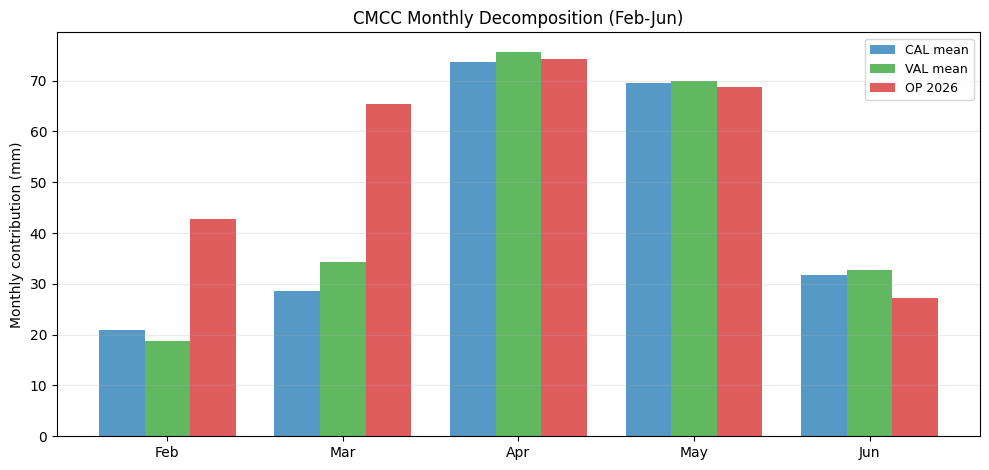

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_monthly_decomposition.png


In [34]:
# 1) Monthly decomposition panel (Feb-Jun contributions)
months_seq = [2, 3, 4, 5, 6]
month_names = {2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun"}

cal_month_means = []
val_month_means = []
op_month_vals = []
for m in months_seq:
    arr = monthly_totals_by_month[m]
    cal_month_means.append(float(np.nanmean(arr[cal_mask_arr])) if np.any(cal_mask_arr) else np.nan)
    val_month_means.append(float(np.nanmean(arr[val_mask_arr])) if np.any(val_mask_arr) else np.nan)
    op_month_vals.append(float(arr[op_mask_arr][0]) if np.any(op_mask_arr) and np.any(np.isfinite(arr[op_mask_arr])) else np.nan)

x = np.arange(len(months_seq))
width = 0.26
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(x - width, cal_month_means, width=width, color="tab:blue", alpha=0.75, label="CAL mean")
ax.bar(x,         val_month_means, width=width, color="tab:green", alpha=0.75, label="VAL mean")
ax.bar(x + width, op_month_vals,   width=width, color="tab:red", alpha=0.75, label=f"OP {op_year_local}")

ax.set_xticks(x)
ax.set_xticklabels([month_names[m] for m in months_seq])
ax.set_ylabel("Monthly contribution (mm)")
ax.set_title("CMCC Monthly Decomposition (Feb-Jun)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_monthly_decomposition.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Monthly Decomposition (Feb-Jun)

This panel breaks the seasonal total into monthly contributions for CAL, VAL, and OP.

- Each month has three bars (CAL mean, VAL mean, OP).
- Helps show which months drive differences seen in full-season totals.
- Useful for diagnosing March-April behavior and period-specific shifts.

### Plot 2 Title: Outlier Years Callout and Lollipop

,year,seasonal_total_mm,period,anomaly_vs_cal
0,2023,111.321412,VAL,-31.394099
1,2000,113.172946,CAL,-29.542565
2,1999,113.618478,CAL,-29.097033
3,2016,193.110910,CAL,50.395399
4,1998,224.644687,CAL,81.929176
5,2024,225.538175,VAL,82.822664


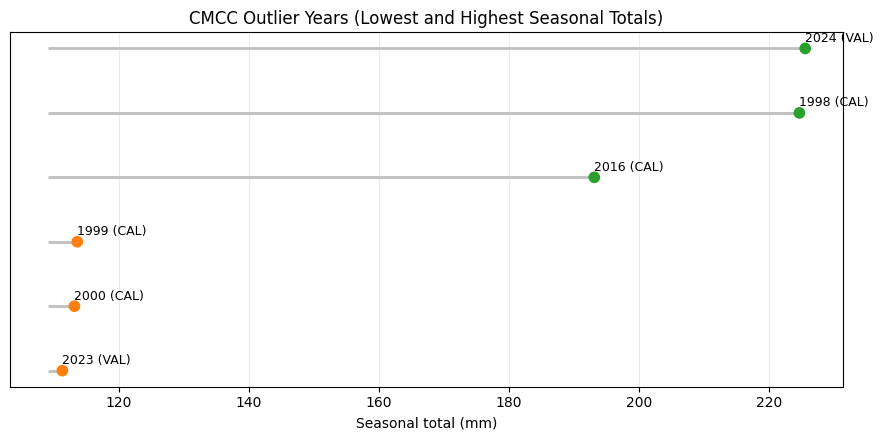

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_outlier_lollipop.png


In [35]:
# 2) Outlier callout table + compact lollipop plot (top/bottom years)
work_df = cmcc_summary_df[["year", "seasonal_total_mm", "period"]].dropna().copy()
work_df["anomaly_vs_cal"] = work_df["seasonal_total_mm"] - cal_mean_ref if np.isfinite(cal_mean_ref) else np.nan

n_pick = 3
low_df = work_df.nsmallest(n_pick, "seasonal_total_mm")
high_df = work_df.nlargest(n_pick, "seasonal_total_mm")
outlier_df = pd.concat([low_df, high_df], axis=0).sort_values("seasonal_total_mm")

display(outlier_df.reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 4.5))
ypos = np.arange(len(outlier_df))
vals = outlier_df["seasonal_total_mm"].values
ax.hlines(y=ypos, xmin=np.nanmin(vals) * 0.98, xmax=vals, color="0.75", lw=2)
ax.scatter(vals, ypos, c=["tab:orange" if v < np.nanmedian(cmcc_vals_arr) else "tab:green" for v in vals], s=55, zorder=3)
for i, row in enumerate(outlier_df.itertuples(index=False)):
    ax.text(row.seasonal_total_mm, i + 0.1, f"{int(row.year)} ({row.period})", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("Seasonal total (mm)")
ax.set_title("CMCC Outlier Years (Lowest and Highest Seasonal Totals)")
ax.grid(True, axis="x", alpha=0.25)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_outlier_lollipop.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Outlier Callout

This section identifies the lowest and highest seasonal-total years and highlights them in both a table and lollipop chart.

- Table: exact values and period labels (CAL/VAL/OP).
- Lollipop plot: quick visual ranking of extremes.
- Use this to pinpoint unusual years for deeper diagnosis.

### Plot 3 Title: Distribution Comparison (CAL vs VAL with OP)

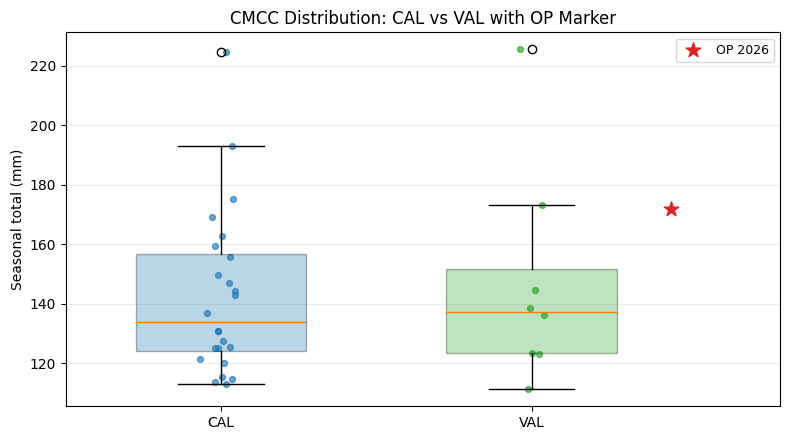

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_distribution_boxplot.png


In [51]:
# 3) Ranked/distribution chart (boxplot CAL vs VAL + OP marker)
cal_plot = cmcc_summary_df.loc[cmcc_summary_df["period"] == "CAL", "seasonal_total_mm"].dropna().values
val_plot = cmcc_summary_df.loc[cmcc_summary_df["period"] == "VAL", "seasonal_total_mm"].dropna().values

fig, ax = plt.subplots(figsize=(8, 4.5))
parts = ax.boxplot([cal_plot, val_plot], labels=["CAL", "VAL"], patch_artist=True, widths=0.55)
for patch, c in zip(parts["boxes"], ["tab:blue", "tab:green"]):
    patch.set_facecolor(c)
    patch.set_alpha(0.3)

# Jittered points for context
rng = np.random.default_rng(123)
if cal_plot.size:
    ax.scatter(1 + rng.normal(0, 0.03, size=cal_plot.size), cal_plot, s=18, color="tab:blue", alpha=0.65)
if val_plot.size:
    ax.scatter(2 + rng.normal(0, 0.03, size=val_plot.size), val_plot, s=18, color="tab:green", alpha=0.65)

if np.isfinite(op_val_ref):
    ax.scatter([2.45], [op_val_ref], c="tab:red", marker="*", s=120, zorder=5, label=f"OP {op_year_local}")

ax.set_xlim(0.5, 2.8)
ax.set_ylabel("Seasonal total (mm)")
ax.set_title("CMCC Distribution: CAL vs VAL with OP Marker")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_distribution_boxplot.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Distribution Comparison (CAL vs VAL)

This boxplot compares the seasonal-total distribution in CAL and VAL periods, with OP overlaid.

- Box: interquartile range (middle 50 percent).
- Whiskers/points: spread and year-level values.
- Red star: operational year against historical distributions.
- Use this to assess whether OP is within typical CAL/VAL behavior.

### Plot 4 Title: Seasonal Total Anomaly (vs CAL Mean)

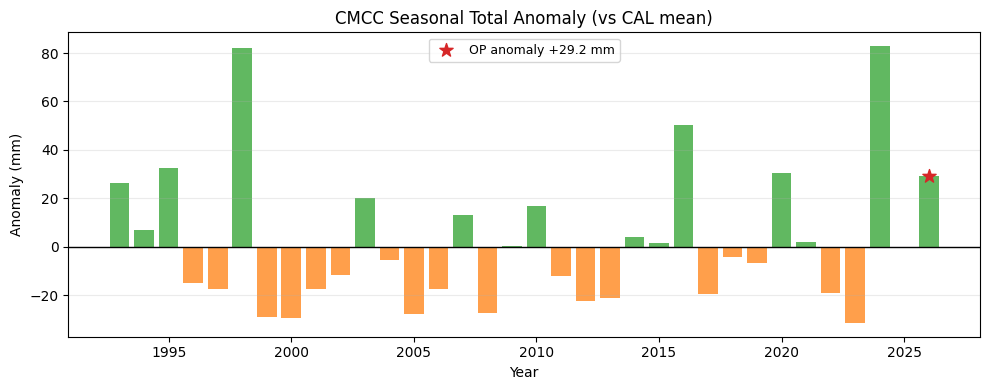

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_anomaly_timeseries.png


In [37]:
# 4) Anomaly time series relative to CAL mean
if not np.isfinite(cal_mean_ref):
    raise RuntimeError("CAL mean is not available for anomaly plot.")

anom = cmcc_vals_arr - cal_mean_ref
fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["tab:green" if v >= 0 else "tab:orange" for v in anom]
ax.bar(cmcc_years_arr, anom, color=bar_colors, alpha=0.75)
ax.axhline(0, color="k", lw=1)
if np.isfinite(op_val_ref):
    op_anom = op_val_ref - cal_mean_ref
    ax.scatter([op_year_local], [op_anom], c="tab:red", marker="*", s=100, zorder=4, label=f"OP anomaly {op_anom:+.1f} mm")

ax.set_title("CMCC Seasonal Total Anomaly (vs CAL mean)")
ax.set_xlabel("Year")
ax.set_ylabel("Anomaly (mm)")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_anomaly_timeseries.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Anomaly Time Series (vs CAL Mean)

This plot converts seasonal totals into anomalies relative to the CAL mean baseline.

- Positive bars: wetter-than-CAL-mean years.
- Negative bars: drier-than-CAL-mean years.
- Red star: OP anomaly.
- Use this view to quickly read sign and magnitude of departures from baseline.

### Plot 5 Title: Member Spread and Uncertainty Ribbon

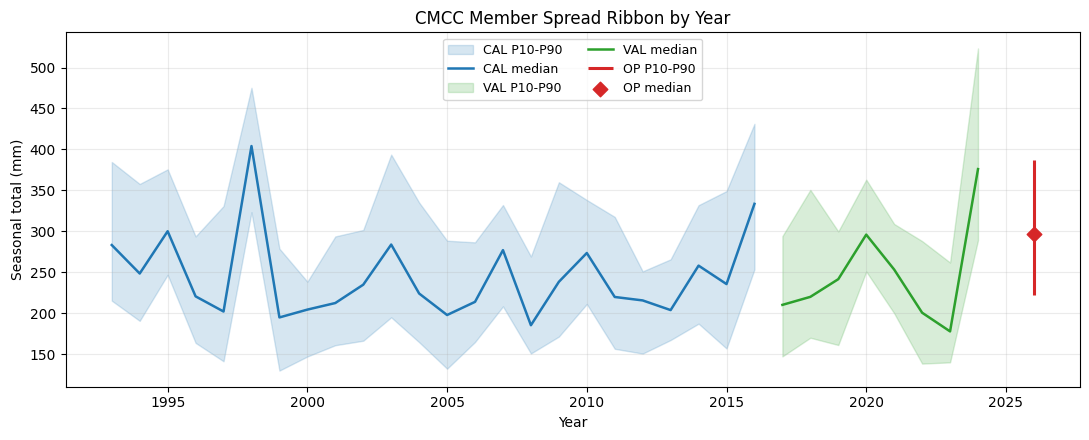

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_member_spread_ribbon.png


In [50]:
# 5) Uncertainty ribbons (member spread by year: P10-P90 + median)
fig, ax = plt.subplots(figsize=(11, 4.5))

for period_key, color in [("CAL", "tab:blue"), ("VAL", "tab:green")]:
    ys = member_percentiles[period_key]["years"]
    p10 = member_percentiles[period_key]["p10"]
    p50 = member_percentiles[period_key]["p50"]
    p90 = member_percentiles[period_key]["p90"]
    if ys.size == 0:
        continue
    order = np.argsort(ys)
    ys, p10, p50, p90 = ys[order], p10[order], p50[order], p90[order]
    ax.fill_between(ys, p10, p90, color=color, alpha=0.18, label=f"{period_key} P10-P90")
    ax.plot(ys, p50, color=color, lw=1.8, label=f"{period_key} median")

# OP spread from members in the OP year.
op_p10 = np.nan
op_p50 = np.nan
op_p90 = np.nan
if np.isfinite(op_year_local) and int(op_year_local) in file_map:
    try:
        member_cap_ref_local = globals().get("member_cap_ref", globals().get("hindcast_member_cap", None))
        mtot_op = _load_member_seasonal_totals_local(file_map[int(op_year_local)], member_cap=member_cap_ref_local)
        if np.size(mtot_op) > 0:
            op_p10 = float(np.nanpercentile(mtot_op, 10))
            op_p50 = float(np.nanpercentile(mtot_op, 50))
            op_p90 = float(np.nanpercentile(mtot_op, 90))
    except Exception as e:
        print(f"OP spread not computed: {e}")

# OP markers: median and P10-P90 whisker.
if np.isfinite(op_p10) and np.isfinite(op_p90):
    ax.vlines(op_year_local, op_p10, op_p90, color="tab:red", lw=2.2, zorder=5, label="OP P10-P90")
if np.isfinite(op_p50):
    ax.scatter([op_year_local], [op_p50], c="tab:red", marker="D", s=55, zorder=7, label="OP median")

ax.set_title("CMCC Member Spread Ribbon by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Seasonal total (mm)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", ncol=2, fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_member_spread_ribbon.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Member Spread Ribbon (Uncertainty)

This figure adds ensemble uncertainty around yearly totals using member percentiles.

- Shaded band: P10 to P90 range.
- Solid line: member median.
- Red whisker/diamond: OP P10-P90 and OP median.
- Use this to separate signal (central tendency) from forecast spread (uncertainty).

### Plot 6 Title: Period Summary Strip (CAL, VAL, OP)

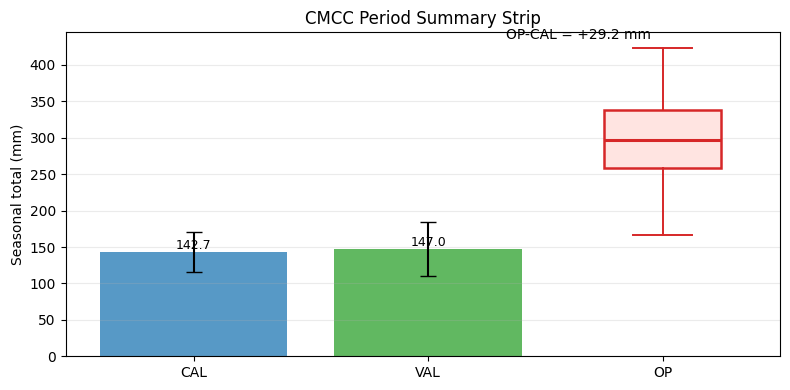

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_period_summary_strip.png


In [49]:
# 6) Period summary strip (means, std, OP comparison + OP member box)
labels = ["CAL", "VAL", "OP"]
means = [cal_mean_ref, val_mean_ref, op_val_ref]
errs = [cal_std_ref if np.isfinite(cal_std_ref) else 0.0, val_std_ref if np.isfinite(val_std_ref) else 0.0, 0.0]
colors = ["tab:blue", "tab:green", "tab:red"]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(labels))

# CAL and VAL as bars with variability.
for i, (m, e, c) in enumerate(zip(means[:2], errs[:2], colors[:2])):
    if np.isfinite(m):
        ax.bar(i, m, yerr=e if e > 0 else None, color=c, alpha=0.75, capsize=6)
        ax.text(i, m, f"{m:.1f}", ha="center", va="bottom", fontsize=9)

# OP as box plot from operational members (instead of a bar).
op_members = np.array([])
if np.isfinite(op_year_local) and int(op_year_local) in file_map:
    try:
        member_cap_ref_local = globals().get("member_cap_ref", globals().get("hindcast_member_cap", None))
        mtot_op = _load_member_seasonal_totals_local(file_map[int(op_year_local)], member_cap=member_cap_ref_local)
        op_members = np.asarray(mtot_op, dtype=float)
        op_members = op_members[np.isfinite(op_members)]
    except Exception as e:
        print(f"OP members not available for box plot: {e}")

if op_members.size > 0:
    ax.boxplot(
        [op_members],
        positions=[2.0],
        widths=[0.5],
        patch_artist=True,
        showfliers=True,
        boxprops=dict(facecolor="mistyrose", edgecolor="tab:red", linewidth=1.8),
        whiskerprops=dict(color="tab:red", linewidth=1.4),
        capprops=dict(color="tab:red", linewidth=1.4),
        medianprops=dict(color="tab:red", linewidth=2.2),
        flierprops=dict(marker="o", markerfacecolor="tab:red", markeredgecolor="tab:red", markersize=4, alpha=0.6),
        zorder=4,
    )
    op_med = float(np.nanmedian(op_members))
    ax.text(2, op_med, f"{op_med:.1f}", ha="center", va="bottom", fontsize=9, color="tab:red")
else:
    # Fallback to OP mean bar if members are unavailable.
    if np.isfinite(op_val_ref):
        ax.bar(2, op_val_ref, color="tab:red", alpha=0.6)
        ax.text(2, op_val_ref, f"{op_val_ref:.1f}", ha="center", va="bottom", fontsize=9)

if np.isfinite(cal_mean_ref) and np.isfinite(op_val_ref):
    delta = op_val_ref - cal_mean_ref
    ymax_candidates = [m for m in means if np.isfinite(m)]
    if op_members.size > 0:
        ymax_candidates.append(float(np.nanmax(op_members)))
    ymax = np.nanmax(ymax_candidates) if len(ymax_candidates) else 0.0
    ax.text(1.95, ymax * 1.03, f"OP-CAL = {delta:+.1f} mm", ha="right", fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Seasonal total (mm)")
ax.set_title("CMCC Period Summary Strip")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_period_summary_strip.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Period Summary Strip

This summary condenses CAL, VAL, and OP into a compact comparison.

- CAL and VAL: mean seasonal totals as bars.
- CAL and VAL error bars: within-period variability (standard deviation).
- OP: box plot of operational-member distribution.
- Text annotation: OP minus CAL difference.
- Use this for fast headline interpretation before inspecting detailed plots.

### Plot 7 Title: Zoomed Companion Time Series

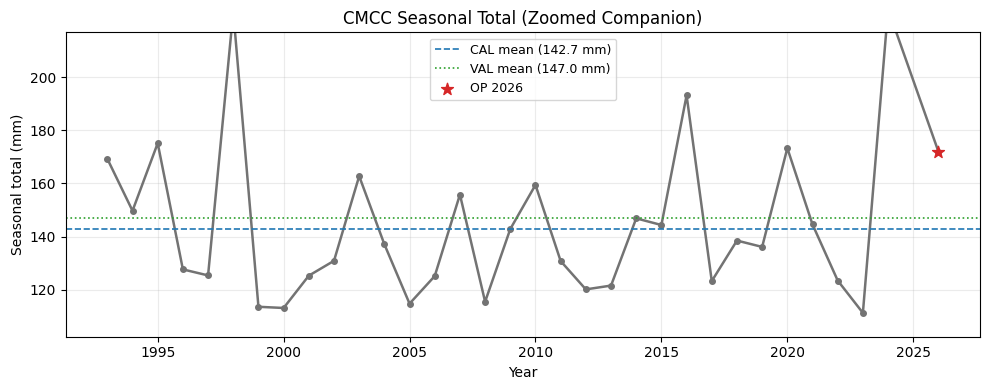

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_zoomed_timeseries.png


In [40]:
# 7) Zoomed companion time series (same data, tighter y-range)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cmcc_years_arr, cmcc_vals_arr, color="0.45", lw=1.8, marker="o", ms=4)
if np.isfinite(cal_mean_ref):
    ax.axhline(cal_mean_ref, color="tab:blue", ls="--", lw=1.2, label=f"CAL mean ({cal_mean_ref:.1f} mm)")
if np.isfinite(val_mean_ref):
    ax.axhline(val_mean_ref, color="tab:green", ls=":", lw=1.2, label=f"VAL mean ({val_mean_ref:.1f} mm)")
if np.isfinite(op_val_ref):
    ax.scatter([op_year_local], [op_val_ref], s=80, c="tab:red", marker="*", zorder=4, label=f"OP {op_year_local}")

finite_vals = cmcc_vals_arr[np.isfinite(cmcc_vals_arr)]
if finite_vals.size:
    p5, p95 = np.nanpercentile(finite_vals, [5, 95])
    pad = max(5.0, 0.12 * (p95 - p5 + 1e-6))
    ax.set_ylim(p5 - pad, p95 + pad)

ax.set_title("CMCC Seasonal Total (Zoomed Companion)")
ax.set_xlabel("Year")
ax.set_ylabel("Seasonal total (mm)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_zoomed_timeseries.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Zoomed Companion Time Series

This plot shows the same CMCC seasonal-total time series as the main figure, but with a tighter y-range so year-to-year differences are easier to see.

- Dashed horizontal lines: CAL and VAL means.
- Red star: operational year value.
- Use this view to compare relative ups/downs across years without changing the original plot.

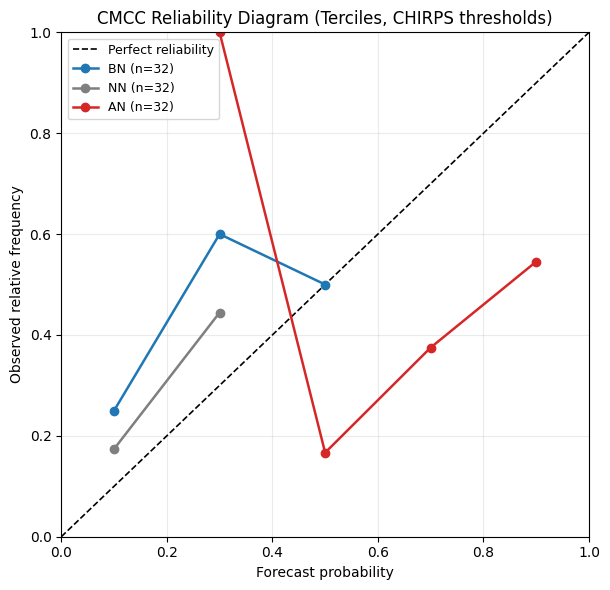

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_reliability_terciles.png


In [75]:
# 8) Reliability diagram for tercile probabilities (BN, NN, AN)
# Uses CHIRPS CAL tercile thresholds and CHIRPS observed year-level categories.

# Build a year->member seasonal totals cache for CAL+VAL years.
years_for_skill = sorted([int(y) for y in cmcc_years_arr if int(y) in file_map and (int(y) in set(np.asarray(CAL_YEARS, dtype=int)) or int(y) in set(np.asarray(VAL_YEARS, dtype=int)))])

if len(years_for_skill) < 5:
    raise RuntimeError("Not enough CAL/VAL years for reliability diagnostic.")

member_totals_by_year = {}
for y in years_for_skill:
    try:
        member_totals_by_year[y] = _load_member_seasonal_totals_local(file_map[int(y)], member_cap=member_cap_ref)
    except Exception:
        continue

if len(member_totals_by_year) < 5:
    raise RuntimeError("Not enough valid member totals for reliability diagnostic.")

# CHIRPS observed seasonal totals by year (must come from the CHIRPS comparable-window cell).
if not all(v in globals() for v in ["chirps_years", "season_vals"]):
    raise RuntimeError("Missing CHIRPS seasonal totals. Run the CHIRPS Feb-Init 183-day seasonal totals cell first.")

obs_years = np.asarray(chirps_years, dtype=int)
obs_vals = np.asarray(season_vals, dtype=float)
good = np.isfinite(obs_vals)
obs_years = obs_years[good]
obs_vals = obs_vals[good]
obs_total_by_year = {int(y): float(v) for y, v in zip(obs_years, obs_vals)}

# CAL thresholds from CHIRPS realized totals.
cal_obs_vals = np.asarray([obs_total_by_year[int(y)] for y in np.asarray(CAL_YEARS, dtype=int) if int(y) in obs_total_by_year], dtype=float)
if cal_obs_vals.size < 5:
    raise RuntimeError("CHIRPS CAL sample too small to compute tercile thresholds.")

q33, q67 = np.nanpercentile(cal_obs_vals, [33.3333, 66.6667])

# Assemble forecast probabilities and observed indicators.
classes = ["BN", "NN", "AN"]
prob_map = {k: [] for k in classes}
obs_map = {k: [] for k in classes}

for y in sorted(member_totals_by_year.keys()):
    mtot = np.asarray(member_totals_by_year[y], dtype=float)
    mtot = mtot[np.isfinite(mtot)]
    if mtot.size == 0:
        continue

    p_bn = float(np.mean(mtot < q33))
    p_an = float(np.mean(mtot > q67))
    p_nn = max(0.0, 1.0 - p_bn - p_an)

    if int(y) not in obs_total_by_year:
        continue
    y_obs = float(obs_total_by_year[int(y)])

    if y_obs < q33:
        obs_cls = "BN"
    elif y_obs > q67:
        obs_cls = "AN"
    else:
        obs_cls = "NN"

    prob_map["BN"].append(p_bn)
    prob_map["NN"].append(p_nn)
    prob_map["AN"].append(p_an)

    obs_map["BN"].append(1 if obs_cls == "BN" else 0)
    obs_map["NN"].append(1 if obs_cls == "NN" else 0)
    obs_map["AN"].append(1 if obs_cls == "AN" else 0)

# Reliability by probability bins.
bins = np.linspace(0, 1, 6)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, ax = plt.subplots(figsize=(6.2, 6.0))
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Perfect reliability")

color_map = {"BN": "tab:blue", "NN": "tab:gray", "AN": "tab:red"}

for cls in classes:
    p = np.asarray(prob_map[cls], dtype=float)
    o = np.asarray(obs_map[cls], dtype=float)
    if p.size == 0:
        continue

    rel_y = np.full(bin_centers.shape, np.nan, dtype=float)
    nbin = np.zeros(bin_centers.shape, dtype=int)

    for i in range(len(bin_centers)):
        m = (p >= bins[i]) & (p < bins[i + 1] if i < len(bin_centers) - 1 else p <= bins[i + 1])
        nbin[i] = int(np.sum(m))
        if nbin[i] > 0:
            rel_y[i] = float(np.mean(o[m]))

    good = np.isfinite(rel_y)
    if np.any(good):
        ax.plot(bin_centers[good], rel_y[good], marker="o", lw=1.8, color=color_map[cls], label=f"{cls} (n={p.size})")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Forecast probability")
ax.set_ylabel("Observed relative frequency")
ax.set_title("CMCC Reliability Diagram (Terciles, CHIRPS thresholds)")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_reliability_terciles.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Reliability Diagram (BN/NN/AN Terciles)

This plot checks whether forecast probabilities are statistically consistent with observed category frequencies.

- Diagonal line: perfect reliability.
- Points above diagonal: category tends to occur more often than forecast at that probability (under-forecasting).
- Points below diagonal: category tends to occur less often than forecast at that probability (over-forecasting).
- Separate curves are shown for BN, NN, and AN tercile classes.
- Data source note: tercile thresholds come from CHIRPS CAL observed seasonal totals; forecast probabilities come from CMCC ensemble members.

Use this diagnostic to assess probability calibration before interpreting probability magnitudes operationally.

### Plot 9 Title: ROC Curves and AUC (BN/NN/AN Terciles)

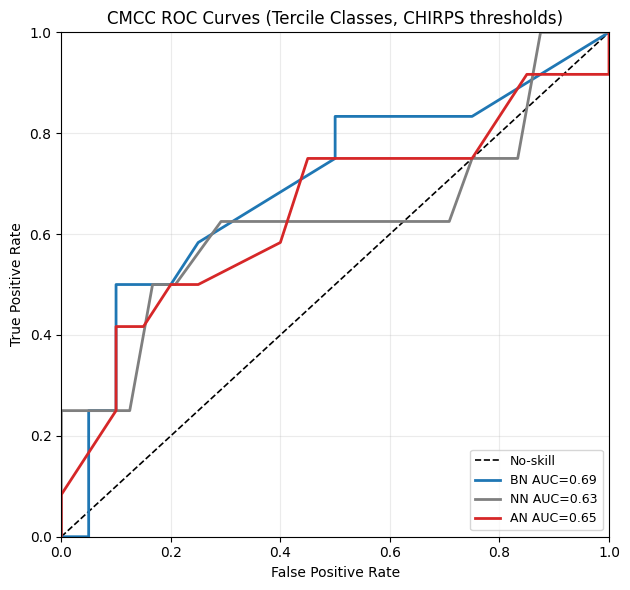

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_roc_terciles.png


In [76]:
# 9) ROC curves and AUC for BN/NN/AN tercile classes
# Reuses probability/observation arrays from Plot 8 when available; otherwise rebuilds.

if not all(v in globals() for v in ["prob_map", "obs_map"]):
    years_for_skill = sorted([int(y) for y in cmcc_years_arr if int(y) in file_map and (int(y) in set(np.asarray(CAL_YEARS, dtype=int)) or int(y) in set(np.asarray(VAL_YEARS, dtype=int)))])
    member_totals_by_year = {}
    for y in years_for_skill:
        try:
            member_totals_by_year[y] = _load_member_seasonal_totals_local(file_map[int(y)], member_cap=member_cap_ref)
        except Exception:
            continue

    if not all(v in globals() for v in ["chirps_years", "season_vals"]):
        raise RuntimeError("Missing CHIRPS seasonal totals. Run the CHIRPS Feb-Init 183-day seasonal totals cell first.")

    obs_years = np.asarray(chirps_years, dtype=int)
    obs_vals = np.asarray(season_vals, dtype=float)
    good_obs = np.isfinite(obs_vals)
    obs_years = obs_years[good_obs]
    obs_vals = obs_vals[good_obs]
    obs_total_by_year = {int(y): float(v) for y, v in zip(obs_years, obs_vals)}

    cal_obs_vals = np.asarray([obs_total_by_year[int(y)] for y in np.asarray(CAL_YEARS, dtype=int) if int(y) in obs_total_by_year], dtype=float)
    if cal_obs_vals.size < 5:
        raise RuntimeError("CHIRPS CAL sample too small to compute tercile thresholds.")

    q33, q67 = np.nanpercentile(cal_obs_vals, [33.3333, 66.6667])

    classes = ["BN", "NN", "AN"]
    prob_map = {k: [] for k in classes}
    obs_map = {k: [] for k in classes}

    for y in sorted(member_totals_by_year.keys()):
        mtot = np.asarray(member_totals_by_year[y], dtype=float)
        mtot = mtot[np.isfinite(mtot)]
        if mtot.size == 0:
            continue

        p_bn = float(np.mean(mtot < q33))
        p_an = float(np.mean(mtot > q67))
        p_nn = max(0.0, 1.0 - p_bn - p_an)

        if int(y) not in obs_total_by_year:
            continue
        y_obs = float(obs_total_by_year[int(y)])

        if y_obs < q33:
            obs_cls = "BN"
        elif y_obs > q67:
            obs_cls = "AN"
        else:
            obs_cls = "NN"

        prob_map["BN"].append(p_bn)
        prob_map["NN"].append(p_nn)
        prob_map["AN"].append(p_an)

        obs_map["BN"].append(1 if obs_cls == "BN" else 0)
        obs_map["NN"].append(1 if obs_cls == "NN" else 0)
        obs_map["AN"].append(1 if obs_cls == "AN" else 0)


def _roc_curve_from_scores(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    thresholds = np.r_[np.inf, np.sort(np.unique(y_score))[::-1], -np.inf]
    tpr = []
    fpr = []

    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)
    if pos == 0 or neg == 0:
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), np.nan

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        tpr.append(tp / pos)
        fpr.append(fp / neg)

    fpr = np.asarray(fpr, dtype=float)
    tpr = np.asarray(tpr, dtype=float)

    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]

    if hasattr(np, "trapezoid"):
        auc = float(np.trapezoid(tpr, fpr))
    else:
        auc = float(np.trapz(tpr, fpr))
    return fpr, tpr, auc


fig, ax = plt.subplots(figsize=(6.4, 6.0))
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="No-skill")

color_map = {"BN": "tab:blue", "NN": "tab:gray", "AN": "tab:red"}
for cls in ["BN", "NN", "AN"]:
    y_true = np.asarray(obs_map.get(cls, []), dtype=int)
    y_score = np.asarray(prob_map.get(cls, []), dtype=float)
    if y_true.size < 3:
        continue

    fpr, tpr, auc = _roc_curve_from_scores(y_true, y_score)
    if np.isfinite(auc):
        ax.plot(fpr, tpr, lw=2.0, color=color_map[cls], label=f"{cls} AUC={auc:.2f}")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CMCC ROC Curves (Tercile Classes, CHIRPS thresholds)")
ax.grid(True, alpha=0.25)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_roc_terciles.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: ROC Curves and AUC (BN/NN/AN)

This plot evaluates discrimination skill for each tercile class.

- ROC curve shows hit rate versus false alarm rate across probability thresholds.
- AUC summarizes curve performance: closer to 1 is better discrimination; around 0.5 is near no-skill.
- Separate curves are shown for BN, NN, and AN.
- Data source note: tercile thresholds and observed classes are defined from CHIRPS CAL observed seasonal totals; forecast probabilities are from CMCC ensemble members.

Use this diagnostic to check how well forecast probabilities separate event and non-event years for each class.

### Plot 10 Title: AUC Bootstrap Uncertainty (BN/NN/AN Terciles)

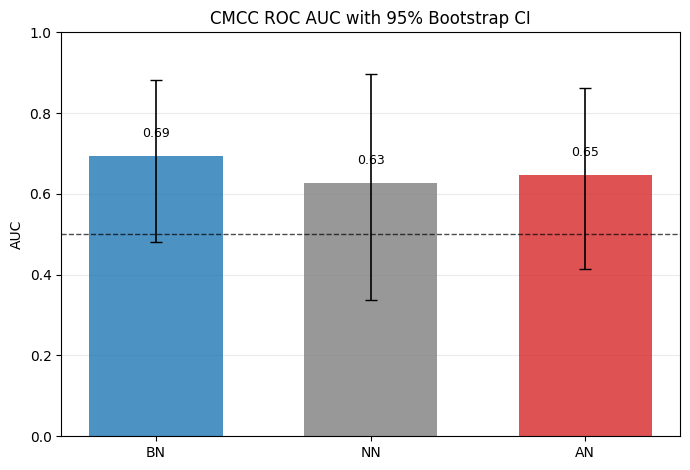

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_auc_bootstrap_ci.png


In [77]:
# 10) AUC bootstrap uncertainty (95% CI) for BN/NN/AN
# Uses probability and observed-class arrays from Plot 8/9.

if not all(v in globals() for v in ["prob_map", "obs_map"]):
    raise RuntimeError("Run Plot 8 (reliability) before Plot 10 so prob_map/obs_map are available.")


def _auc_from_scores(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)
    if pos == 0 or neg == 0:
        return np.nan

    thresholds = np.r_[np.inf, np.sort(np.unique(y_score))[::-1], -np.inf]
    tpr = []
    fpr = []

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        tpr.append(tp / pos)
        fpr.append(fp / neg)

    fpr = np.asarray(fpr, dtype=float)
    tpr = np.asarray(tpr, dtype=float)
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]

    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(tpr, fpr))
    return float(np.trapz(tpr, fpr))


rng = np.random.default_rng(42)
n_boot = 2000
classes = ["BN", "NN", "AN"]
base_auc = {}
ci_low = {}
ci_high = {}

for cls in classes:
    y_true = np.asarray(obs_map.get(cls, []), dtype=int)
    y_score = np.asarray(prob_map.get(cls, []), dtype=float)

    good = np.isfinite(y_score)
    y_true = y_true[good]
    y_score = y_score[good]

    n = y_true.size
    if n < 6:
        base_auc[cls] = np.nan
        ci_low[cls] = np.nan
        ci_high[cls] = np.nan
        continue

    base_auc[cls] = _auc_from_scores(y_true, y_score)

    boot_vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        auc_b = _auc_from_scores(y_true[idx], y_score[idx])
        if np.isfinite(auc_b):
            boot_vals.append(auc_b)

    if len(boot_vals) < 30:
        ci_low[cls] = np.nan
        ci_high[cls] = np.nan
    else:
        ci_low[cls], ci_high[cls] = np.percentile(boot_vals, [2.5, 97.5])


fig, ax = plt.subplots(figsize=(7.0, 4.8))
x = np.arange(len(classes))
vals = np.array([base_auc[c] for c in classes], dtype=float)
lo = np.array([ci_low[c] for c in classes], dtype=float)
hi = np.array([ci_high[c] for c in classes], dtype=float)

yerr = np.vstack([
    np.where(np.isfinite(vals - lo), vals - lo, 0.0),
    np.where(np.isfinite(hi - vals), hi - vals, 0.0),
])

colors = ["tab:blue", "tab:gray", "tab:red"]
ax.bar(x, vals, color=colors, alpha=0.8, width=0.62, zorder=2)
ax.errorbar(x, vals, yerr=yerr, fmt="none", ecolor="black", elinewidth=1.2, capsize=4, zorder=3)

ax.axhline(0.5, color="k", ls="--", lw=1.0, alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0.0, 1.0)
ax.set_ylabel("AUC")
ax.set_title("CMCC ROC AUC with 95% Bootstrap CI")
ax.grid(True, axis="y", alpha=0.25)

for i, c in enumerate(classes):
    if np.isfinite(vals[i]):
        ax.text(i, min(0.98, vals[i] + 0.04), f"{vals[i]:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_auc_bootstrap_ci.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: AUC Bootstrap Uncertainty (95% CI)

This diagnostic adds uncertainty bounds to class-wise ROC AUC estimates.

- Bars show point AUC for BN, NN, and AN.
- Error bars show 95% bootstrap confidence intervals from resampled years.
- The dashed line at 0.5 indicates no-skill discrimination.

Use this plot to judge whether apparent class discrimination is robust or sensitive to sample variability.

### Plot 11 Title: Brier Score and Brier Skill Score (BN/NN/AN Terciles)

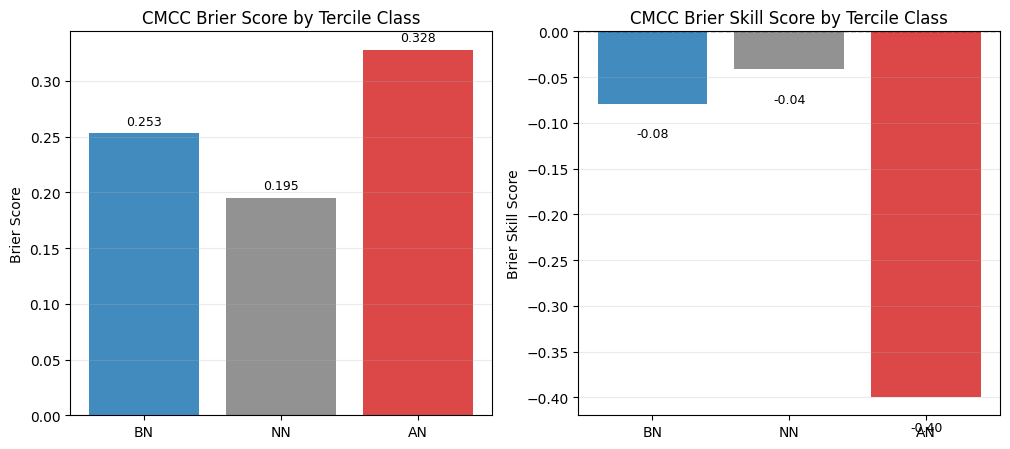

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_brier_bss_terciles.png


In [78]:
# 11) Brier Score (BS) and Brier Skill Score (BSS) by tercile class
# Uses class probabilities and observed outcomes from Plot 8.

if not all(v in globals() for v in ["prob_map", "obs_map"]):
    raise RuntimeError("Run Plot 8 (reliability) before Plot 11 so prob_map/obs_map are available.")

classes = ["BN", "NN", "AN"]
bs_vals = []
bss_vals = []
clim_vals = []

for cls in classes:
    p = np.asarray(prob_map.get(cls, []), dtype=float)
    o = np.asarray(obs_map.get(cls, []), dtype=float)

    good = np.isfinite(p) & np.isfinite(o)
    p = p[good]
    o = o[good]

    if p.size == 0:
        bs_vals.append(np.nan)
        bss_vals.append(np.nan)
        clim_vals.append(np.nan)
        continue

    bs = float(np.mean((p - o) ** 2))
    o_clim = float(np.mean(o))
    bs_ref = float(np.mean((o_clim - o) ** 2))

    bs_vals.append(bs)
    clim_vals.append(o_clim)

    if bs_ref <= 0:
        bss_vals.append(np.nan)
    else:
        bss_vals.append(float(1.0 - (bs / bs_ref)))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.6))
colors = ["tab:blue", "tab:gray", "tab:red"]
x = np.arange(len(classes))

# Left: Brier Score (lower is better)
axes[0].bar(x, bs_vals, color=colors, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].set_ylabel("Brier Score")
axes[0].set_title("CMCC Brier Score by Tercile Class")
axes[0].grid(True, axis="y", alpha=0.25)
for i, v in enumerate(bs_vals):
    if np.isfinite(v):
        axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

# Right: Brier Skill Score (higher is better; 0 means no improvement over climatology)
axes[1].bar(x, bss_vals, color=colors, alpha=0.85)
axes[1].axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylabel("Brier Skill Score")
axes[1].set_title("CMCC Brier Skill Score by Tercile Class")
axes[1].grid(True, axis="y", alpha=0.25)
for i, v in enumerate(bss_vals):
    if np.isfinite(v):
        axes[1].text(i, v + (0.02 if v >= 0 else -0.04), f"{v:.2f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_brier_bss_terciles.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Brier Score and Brier Skill Score

This diagnostic summarizes probabilistic accuracy and skill for each tercile class.

- Brier Score (BS): mean squared probability error (lower is better).
- Brier Skill Score (BSS): improvement over class climatology baseline.
- BSS > 0 indicates better than climatology; BSS <= 0 indicates no skill gain.

Use this plot alongside reliability and ROC to jointly assess calibration, discrimination, and overall probabilistic skill.

In [79]:
# Shared prep for remaining diagnostics: spread-skill, rank histogram, and yearly RPSS
# Verification metrics are computed on CAL+VAL only; OP is retained separately as a reference point.
# Tercile thresholds and observed classes use CHIRPS CAL observed seasonal totals.
verif_years = set(np.asarray(CAL_YEARS, dtype=int)) | set(np.asarray(VAL_YEARS, dtype=int))
skill_years = sorted([int(y) for y in cmcc_years_arr if int(y) in file_map and int(y) in verif_years])

if len(skill_years) < 5:
    raise RuntimeError("Not enough CAL/VAL years for the remaining diagnostics.")

if not all(v in globals() for v in ["chirps_years", "season_vals"]):
    raise RuntimeError("Missing CHIRPS seasonal totals. Run the CHIRPS Feb-Init 183-day seasonal totals cell first.")

obs_years = np.asarray(chirps_years, dtype=int)
obs_vals = np.asarray(season_vals, dtype=float)
good_obs = np.isfinite(obs_vals)
obs_years = obs_years[good_obs]
obs_vals = obs_vals[good_obs]
obs_total_by_year = {int(y): float(v) for y, v in zip(obs_years, obs_vals)}

cal_realized = np.asarray([obs_total_by_year[int(y)] for y in np.asarray(CAL_YEARS, dtype=int) if int(y) in obs_total_by_year], dtype=float)
if cal_realized.size < 5:
    raise RuntimeError("CHIRPS CAL sample too small to define tercile thresholds.")

q33, q67 = np.nanpercentile(cal_realized, [33.3333, 66.6667])
cal_obs_classes = np.where(cal_realized < q33, "BN", np.where(cal_realized > q67, "AN", "NN"))
cal_class_freq = {cls: float(np.mean(cal_obs_classes == cls)) for cls in ["BN", "NN", "AN"]}
clim_probs = np.array([cal_class_freq["BN"], cal_class_freq["NN"], cal_class_freq["AN"]], dtype=float)
clim_cum = np.array([clim_probs[0], clim_probs[0] + clim_probs[1], 1.0], dtype=float)

rows = []
skill_member_totals_by_year = {}
rng_tie = np.random.default_rng(12345)

for y in skill_years:
    if int(y) not in obs_total_by_year:
        continue
    obs_total = float(obs_total_by_year[int(y)])
    if not np.isfinite(obs_total):
        continue

    try:
        totals = _load_member_seasonal_totals_local(file_map[int(y)], member_cap=member_cap_ref)
    except Exception:
        continue

    totals = np.asarray(totals, dtype=float)
    totals = totals[np.isfinite(totals)]
    if totals.size == 0:
        continue

    skill_member_totals_by_year[int(y)] = totals.copy()

    ens_mean = float(np.mean(totals))
    ens_std = float(np.std(totals, ddof=1)) if totals.size > 1 else 0.0
    abs_error = float(abs(ens_mean - obs_total))
    n_members = int(totals.size)

    sorted_totals = np.sort(totals)
    left = int(np.searchsorted(sorted_totals, obs_total, side="left"))
    right = int(np.searchsorted(sorted_totals, obs_total, side="right"))
    if right > left:
        rank = int(rng_tie.integers(left, right + 1))
    else:
        rank = right

    p_bn = float(np.mean(totals < q33))
    p_an = float(np.mean(totals > q67))
    p_nn = max(0.0, 1.0 - p_bn - p_an)

    if obs_total < q33:
        obs_class = "BN"
    elif obs_total > q67:
        obs_class = "AN"
    else:
        obs_class = "NN"

    period = "CAL" if int(y) in set(np.asarray(CAL_YEARS, dtype=int)) else "VAL"

    rows.append({
        "year": int(y),
        "period": period,
        "obs_total": obs_total,
        "ens_mean": ens_mean,
        "ens_std": ens_std,
        "abs_error": abs_error,
        "n_members": n_members,
        "rank": rank,
        "p_bn": p_bn,
        "p_nn": p_nn,
        "p_an": p_an,
        "obs_class": obs_class,
    })

skill_df = pd.DataFrame(rows).sort_values("year").reset_index(drop=True)
if skill_df.empty:
    raise RuntimeError("No valid CAL/VAL years were assembled for the remaining diagnostics.")

# Optional OP reference row, not included in verification skill statistics.
op_skill_row = None
op_year_local = int(OP_YEAR)
if op_year_local in file_map and op_year_local in obs_total_by_year:
    obs_total = float(obs_total_by_year[op_year_local])
    if np.isfinite(obs_total):
        try:
            totals = _load_member_seasonal_totals_local(file_map[op_year_local], member_cap=member_cap_ref)
        except Exception:
            totals = np.array([], dtype=float)

        totals = np.asarray(totals, dtype=float)
        totals = totals[np.isfinite(totals)]
        if totals.size > 0:
            ens_mean = float(np.mean(totals))
            ens_std = float(np.std(totals, ddof=1)) if totals.size > 1 else 0.0
            abs_error = float(abs(ens_mean - obs_total))
            p_bn = float(np.mean(totals < q33))
            p_an = float(np.mean(totals > q67))
            p_nn = max(0.0, 1.0 - p_bn - p_an)

            if obs_total < q33:
                obs_class = "BN"
            elif obs_total > q67:
                obs_class = "AN"
            else:
                obs_class = "NN"

            op_skill_row = {
                "year": op_year_local,
                "period": "OP",
                "obs_total": obs_total,
                "ens_mean": ens_mean,
                "ens_std": ens_std,
                "abs_error": abs_error,
                "n_members": int(totals.size),
                "p_bn": p_bn,
                "p_nn": p_nn,
                "p_an": p_an,
                "obs_class": obs_class,
            }

print(f"Verification years used (CAL+VAL): {len(skill_df)}")
if op_skill_row is not None:
    print(f"OP reference available for year {op_skill_row['year']}")

Verification years used (CAL+VAL): 32


### Plot 12 Title: Spread-Skill Scatter (Ensemble Spread vs Error)

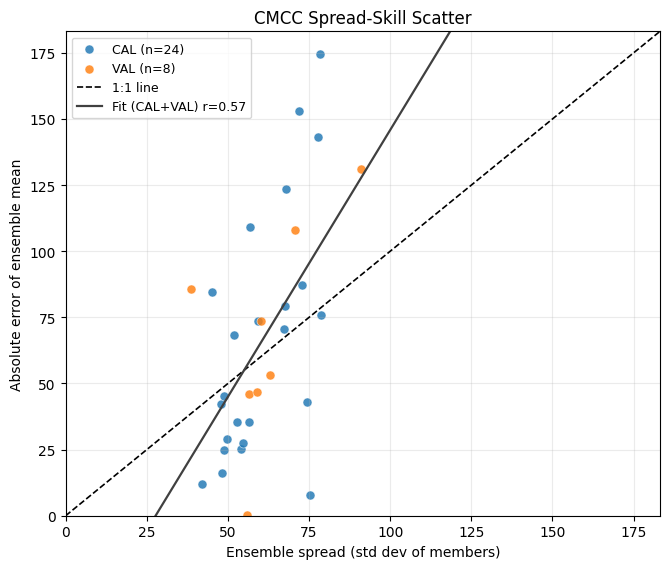

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_spread_skill_scatter.png


In [80]:
# 12) Spread-skill scatter: ensemble spread vs absolute error
# Verification relation is computed on CAL+VAL years; OP is shown as a reference point only.

if "skill_df" not in globals():
    raise RuntimeError("Run the shared prep cell before Plot 12.")

plot_df = skill_df.copy()
plot_df = plot_df[np.isfinite(plot_df["ens_std"]) & np.isfinite(plot_df["abs_error"])].copy()
if plot_df.empty:
    raise RuntimeError("No valid spread/error pairs found for Plot 12.")

palette = {"CAL": "tab:blue", "VAL": "tab:orange", "OP": "tab:red"}
fig, ax = plt.subplots(figsize=(6.8, 5.8))

for period in ["CAL", "VAL"]:
    sub = plot_df.loc[plot_df["period"] == period]
    if sub.empty:
        continue
    ax.scatter(sub["ens_std"], sub["abs_error"], s=42, alpha=0.82, color=palette[period], marker="o", label=f"{period} (n={len(sub)})", edgecolors="white", linewidths=0.4)

# Optional OP reference point (not used in fit/correlation)
if "op_skill_row" in globals() and op_skill_row is not None:
    ax.scatter([op_skill_row["ens_std"]], [op_skill_row["abs_error"]], s=120, alpha=0.95, color=palette["OP"], marker="*", label=f"OP {int(op_skill_row['year'])}", edgecolors="white", linewidths=0.5)

limit = float(max(np.nanmax(plot_df[["ens_std", "abs_error"]].values), 1.0))
if "op_skill_row" in globals() and op_skill_row is not None:
    limit = float(max(limit, op_skill_row["ens_std"], op_skill_row["abs_error"]))
line_x = np.linspace(0, limit * 1.05, 200)
ax.plot(line_x, line_x, "k--", lw=1.2, label="1:1 line")

if len(plot_df) >= 2 and np.nanstd(plot_df["ens_std"].values) > 0 and np.nanstd(plot_df["abs_error"].values) > 0:
    corr = float(np.corrcoef(plot_df["ens_std"].values, plot_df["abs_error"].values)[0, 1])
    fit_m, fit_b = np.polyfit(plot_df["ens_std"].values, plot_df["abs_error"].values, 1)
    ax.plot(line_x, fit_m * line_x + fit_b, color="0.25", lw=1.6, label=f"Fit (CAL+VAL) r={corr:.2f}")

ax.set_xlim(0, limit * 1.05)
ax.set_ylim(0, limit * 1.05)
ax.set_xlabel("Ensemble spread (std dev of members)")
ax.set_ylabel("Absolute error of ensemble mean")
ax.set_title("CMCC Spread-Skill Scatter")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_spread_skill_scatter.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Spread-Skill Scatter

This plot checks whether ensemble spread is a useful measure of uncertainty.

- Verification relationship is computed on CAL+VAL years.
- OP is shown only as a reference point and is not used in the fitted spread-skill relation.
- X-axis: ensemble spread, measured as the standard deviation of member seasonal totals.
- Y-axis: absolute error of the ensemble mean against the observed seasonal total.
- The 1:1 diagonal is the ideal reference: spread and error increase together.
- Data source note: observed seasonal totals and tercile thresholds are CHIRPS-based (CAL climatology), while spread/probability inputs come from CMCC ensemble members.

Interpretation:
- Points above the diagonal mean error is larger than spread, so the ensemble is under-dispersed.
- Points below the diagonal mean spread is larger than error, so the ensemble is over-dispersed.
- A positive fitted trend means spread is informative about forecast error.

Current run interpretation:
- The fitted spread-skill relation is positive (about r=0.59), so years with larger spread tend to have larger error.
- Many points are still not close to the 1:1 line, indicating spread magnitude is informative but not fully reliable as an error estimate.
- The OP star should be interpreted against the verification cloud, not as part of the fit.

If the cloud is tight and near the diagonal, spread is a meaningful uncertainty proxy.

### Plot 13 Title: Rank Histogram (Ensemble Bias / Dispersion)

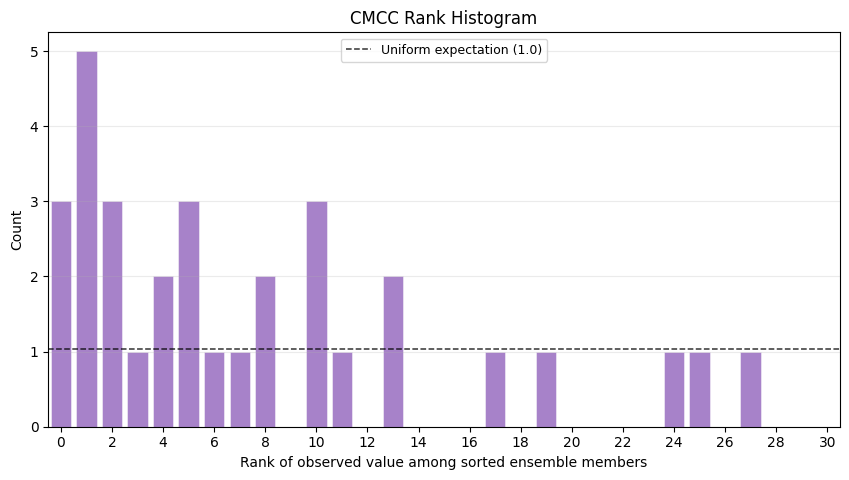

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_rank_histogram.png
Rank histogram years used: 32 / 32 (dropped 0 due to non-modal member count)


In [81]:
# 13) Rank histogram: where does the observed seasonal total fall within the ensemble?
# A flat histogram suggests good spread; U-shaped indicates under-dispersion; hump-shaped indicates over-dispersion.
# Ranks use randomized tie handling from the shared prep.

if "skill_df" not in globals():
    raise RuntimeError("Run the shared prep cell before Plot 13.")

hist_df = skill_df.copy()
all_n = int(len(hist_df))
ref_n = int(hist_df["n_members"].mode().iloc[0])
hist_df = hist_df.loc[hist_df["n_members"] == ref_n].copy()
used_n = int(len(hist_df))
dropped_n = int(all_n - used_n)
if hist_df.empty:
    raise RuntimeError("No years with a consistent ensemble size were found for the rank histogram.")

ranks = hist_df["rank"].clip(0, ref_n).astype(int).values
rank_counts = np.bincount(ranks, minlength=ref_n + 1)
expected = float(len(hist_df)) / float(ref_n + 1)

fig, ax = plt.subplots(figsize=(8.6, 4.9))
x = np.arange(ref_n + 1)
ax.bar(x, rank_counts, color="tab:purple", alpha=0.82, edgecolor="white", linewidth=0.4)
ax.axhline(expected, color="k", ls="--", lw=1.1, alpha=0.8, label=f"Uniform expectation ({expected:.1f})")
ax.set_xlim(-0.5, ref_n + 0.5)
ax.set_xlabel("Rank of observed value among sorted ensemble members")
ax.set_ylabel("Count")
ax.set_title("CMCC Rank Histogram")
ax.grid(True, axis="y", alpha=0.25)
ax.legend(loc="upper center", fontsize=9)
step = 2 if ref_n > 12 else 1
ax.set_xticks(np.arange(0, ref_n + 1, step))
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_rank_histogram.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")
print(f"Rank histogram years used: {used_n} / {all_n} (dropped {dropped_n} due to non-modal member count)")

### Explanation: Rank Histogram

This plot checks whether the ensemble members bracket the observed total in a statistically balanced way.

- The histogram is computed on verification years only (CAL+VAL).
- Years with non-modal ensemble member count are excluded and reported.
- Ties are handled with randomized rank assignment to avoid tie bias.
- A flat histogram means the ensemble is well calibrated in spread and bias.
- A U-shaped histogram usually means under-dispersion: observations fall too often outside the ensemble range.
- A hump-shaped histogram usually means over-dispersion: the ensemble is too wide.
- A left or right skew suggests systematic bias.

Current run interpretation:
- The histogram is clearly skewed toward lower ranks (left side), which points to a distributional bias.
- This means the observation is frequently lower than much of the ensemble distribution for the years used here.
- The shape is not close to flat, so ensemble spread/bias calibration needs adjustment before trusting raw member spread as-is.

Use this plot to diagnose whether the ensemble distribution itself is realistic, not just whether the mean forecast is accurate.

### Plot 14 Title: Yearly RPSS Timeline (Temporal Stability)

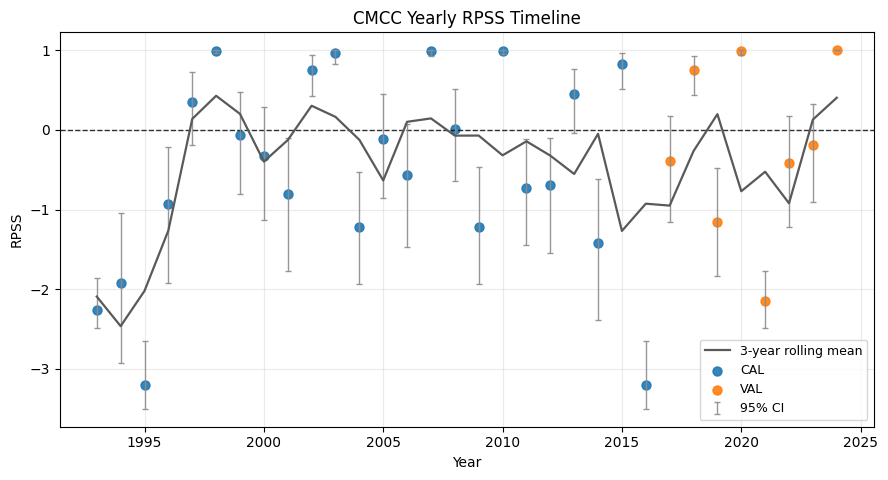

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_rpss_timeline.png


In [82]:
# 14) Yearly RPSS timeline for tercile forecasts
# RPSS > 0 means better than climatology; negative values mean worse than climatology.
# Timeline is verification-only (CAL+VAL), with OP shown as optional reference.

if "skill_df" not in globals():
    raise RuntimeError("Run the shared prep cell before Plot 14.")

if not all(v in globals() for v in ["clim_cum", "skill_member_totals_by_year"]):
    raise RuntimeError("Shared climatology/member cache is missing for Plot 14.")


def _rps_from_probs(p_bn, p_nn, p_an, obs_class):
    fcum = np.array([p_bn, p_bn + p_nn, 1.0], dtype=float)
    if obs_class == "BN":
        ocum = np.array([1.0, 1.0, 1.0], dtype=float)
    elif obs_class == "NN":
        ocum = np.array([0.0, 1.0, 1.0], dtype=float)
    else:
        ocum = np.array([0.0, 0.0, 1.0], dtype=float)
    rps = float(np.sum((fcum - ocum) ** 2) / 2.0)
    rps_ref = float(np.sum((clim_cum - ocum) ** 2) / 2.0)
    rpss = np.nan if rps_ref <= 0 else float(1.0 - (rps / rps_ref))
    return rps, rps_ref, rpss


def _probs_from_member_totals(member_totals, q33, q67):
    arr = np.asarray(member_totals, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return np.nan, np.nan, np.nan
    p_bn = float(np.mean(arr < q33))
    p_an = float(np.mean(arr > q67))
    p_nn = max(0.0, 1.0 - p_bn - p_an)
    return p_bn, p_nn, p_an


timeline_rows = []
rng = np.random.default_rng(2048)
n_boot = 800

for _, row in skill_df.iterrows():
    p_bn = float(row["p_bn"])
    p_nn = float(row["p_nn"])
    p_an = float(row["p_an"])
    obs_class = str(row["obs_class"])

    _, _, rpss = _rps_from_probs(p_bn, p_nn, p_an, obs_class)

    year = int(row["year"])
    members = skill_member_totals_by_year.get(year)
    lo = np.nan
    hi = np.nan

    if members is not None:
        arr = np.asarray(members, dtype=float)
        arr = arr[np.isfinite(arr)]
        if arr.size >= 5:
            boot_vals = []
            for _ in range(n_boot):
                idx = rng.integers(0, arr.size, size=arr.size)
                p_bn_b, p_nn_b, p_an_b = _probs_from_member_totals(arr[idx], q33, q67)
                if np.isfinite(p_bn_b):
                    _, _, rpss_b = _rps_from_probs(p_bn_b, p_nn_b, p_an_b, obs_class)
                    if np.isfinite(rpss_b):
                        boot_vals.append(rpss_b)
            if len(boot_vals) >= 50:
                lo, hi = np.percentile(np.asarray(boot_vals, dtype=float), [2.5, 97.5])

    timeline_rows.append({"year": year, "period": row["period"], "rpss": rpss, "rpss_lo": lo, "rpss_hi": hi})

timeline_df = pd.DataFrame(timeline_rows).sort_values("year").reset_index(drop=True)
if timeline_df.empty:
    raise RuntimeError("No valid years were assembled for Plot 14.")

timeline_df["rpss_roll3"] = timeline_df["rpss"].rolling(3, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(9.0, 4.9))
ax.axhline(0.0, color="k", ls="--", lw=1.0, alpha=0.8)

# Uncertainty bars (bootstrap over ensemble members)
valid_ci = np.isfinite(timeline_df["rpss_lo"].values) & np.isfinite(timeline_df["rpss_hi"].values) & np.isfinite(timeline_df["rpss"].values)
if np.any(valid_ci):
    x_ci = timeline_df.loc[valid_ci, "year"].values
    y_ci = timeline_df.loc[valid_ci, "rpss"].values
    yerr = np.vstack([
        y_ci - timeline_df.loc[valid_ci, "rpss_lo"].values,
        timeline_df.loc[valid_ci, "rpss_hi"].values - y_ci,
    ])
    ax.errorbar(x_ci, y_ci, yerr=yerr, fmt="none", ecolor="0.55", elinewidth=1.0, capsize=2, alpha=0.9, label="95% CI")

ax.plot(timeline_df["year"], timeline_df["rpss_roll3"], color="0.35", lw=1.6, label="3-year rolling mean")

period_colors = {"CAL": "tab:blue", "VAL": "tab:orange"}
for period in ["CAL", "VAL"]:
    sub = timeline_df.loc[timeline_df["period"] == period]
    if sub.empty:
        continue
    ax.scatter(sub["year"], sub["rpss"], s=42, color=period_colors[period], marker="o", alpha=0.9, label=period)

# Optional OP reference point (excluded from verification timeline fit)
if "op_skill_row" in globals() and op_skill_row is not None:
    _, _, op_rpss = _rps_from_probs(op_skill_row["p_bn"], op_skill_row["p_nn"], op_skill_row["p_an"], op_skill_row["obs_class"])
    if np.isfinite(op_rpss):
        ax.scatter([op_skill_row["year"]], [op_rpss], s=130, color="tab:red", marker="*", alpha=0.95, label=f"OP {int(op_skill_row['year'])}")

ax.set_xlabel("Year")
ax.set_ylabel("RPSS")
ax.set_title("CMCC Yearly RPSS Timeline")
ax.grid(True, alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_rpss_timeline.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Yearly RPSS Timeline

This plot shows how probabilistic skill changes from year to year.

- Timeline skill is computed on CAL+VAL years only.
- RPSS above 0 means the forecast beats climatology for that year.
- RPSS below 0 means the forecast is worse than climatology.
- Error bars show bootstrap uncertainty from resampling ensemble members.
- The rolling mean helps show the underlying multi-year pattern without removing yearly variability.
- OP is shown as an optional reference point and is not included in verification rolling averages.

Current run interpretation:
- Most years lie below 0, so skill is often below climatology for this period.
- The rolling mean remains negative for much of the timeline, showing persistent weak probabilistic skill.
- Later years improve toward zero/positive values, suggesting some recent recovery and possible regime dependence.

Use this plot to see whether skill is stable across time or concentrated in certain periods.

### Plot 15 Title: Formal Decision Gate Criteria (Pass/Fail Thresholds)

In [83]:
# 15) Formal decision gate criteria
# Computes standardized verification metrics and compares against explicit thresholds.

required_vars = ["skill_df", "clim_cum", "prob_map", "obs_map", "timeline_df", "diag_dir"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError("Missing prerequisites for decision gate: " + ", ".join(missing))


def _auc_from_scores(y_true, y_score):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)
    pos = np.sum(y_true == 1)
    neg = np.sum(y_true == 0)
    if pos == 0 or neg == 0:
        return np.nan

    thresholds = np.r_[np.inf, np.sort(np.unique(y_score))[::-1], -np.inf]
    tpr = []
    fpr = []
    for thr in thresholds:
        pred = (y_score >= thr).astype(int)
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        tpr.append(tp / pos)
        fpr.append(fp / neg)

    fpr = np.asarray(fpr, dtype=float)
    tpr = np.asarray(tpr, dtype=float)
    order = np.argsort(fpr)
    fpr = fpr[order]
    tpr = tpr[order]
    if hasattr(np, "trapezoid"):
        return float(np.trapezoid(tpr, fpr))
    return float(np.trapz(tpr, fpr))


def _rpss_from_row(row):
    p_bn = float(row["p_bn"])
    p_nn = float(row["p_nn"])
    p_an = float(row["p_an"])
    obs_class = str(row["obs_class"])

    fcum = np.array([p_bn, p_bn + p_nn, 1.0], dtype=float)
    if obs_class == "BN":
        ocum = np.array([1.0, 1.0, 1.0], dtype=float)
    elif obs_class == "NN":
        ocum = np.array([0.0, 1.0, 1.0], dtype=float)
    else:
        ocum = np.array([0.0, 0.0, 1.0], dtype=float)

    rps = float(np.sum((fcum - ocum) ** 2) / 2.0)
    rps_ref = float(np.sum((clim_cum - ocum) ** 2) / 2.0)
    return np.nan if rps_ref <= 0 else float(1.0 - (rps / rps_ref))


# Metric 1: Mean AUC across BN/NN/AN
auc_vals = []
for cls in ["BN", "NN", "AN"]:
    y_true = np.asarray(obs_map.get(cls, []), dtype=int)
    y_score = np.asarray(prob_map.get(cls, []), dtype=float)
    good = np.isfinite(y_score)
    if np.sum(good) >= 3:
        auc_vals.append(_auc_from_scores(y_true[good], y_score[good]))
mean_auc = float(np.nanmean(auc_vals)) if len(auc_vals) else np.nan

# Metric 2: Mean BSS across BN/NN/AN (verification years)
bss_vals_local = []
for cls, pcol in [("BN", "p_bn"), ("NN", "p_nn"), ("AN", "p_an")]:
    p = np.asarray(skill_df[pcol], dtype=float)
    o = (skill_df["obs_class"].values == cls).astype(float)
    good = np.isfinite(p)
    p = p[good]
    o = o[good]
    if p.size == 0:
        bss_vals_local.append(np.nan)
        continue
    bs = float(np.mean((p - o) ** 2))
    o_clim = float(np.mean(o))
    bs_ref = float(np.mean((o_clim - o) ** 2))
    bss_vals_local.append(np.nan if bs_ref <= 0 else float(1.0 - (bs / bs_ref)))
mean_bss = float(np.nanmean(bss_vals_local)) if len(bss_vals_local) else np.nan

# Metric 3: Spread-skill correlation
spread_corr = np.nan
if len(skill_df) >= 2 and np.nanstd(skill_df["ens_std"].values) > 0 and np.nanstd(skill_df["abs_error"].values) > 0:
    spread_corr = float(np.corrcoef(skill_df["ens_std"].values, skill_df["abs_error"].values)[0, 1])

# Metric 4: Rank bias score (0 is ideal)
rank_norm = skill_df["rank"].values / skill_df["n_members"].values
rank_bias_score = float(abs(np.nanmean(rank_norm) - 0.5))

# Metric 5: Recent RPSS (last 5 verification years)
if "rpss" not in timeline_df.columns:
    timeline_df = timeline_df.copy()
    timeline_df["rpss"] = timeline_df.apply(_rpss_from_row, axis=1)
recent_n = min(5, len(timeline_df))
recent_rpss = float(np.nanmean(timeline_df.tail(recent_n)["rpss"].values)) if recent_n > 0 else np.nan

# Editable thresholds
thresholds = {
    "mean_auc_min": 0.60,
    "mean_bss_min": 0.00,
    "spread_corr_min": 0.30,
    "rank_bias_max": 0.10,
    "recent_rpss_min": -0.10,
}

checks = [
    {"metric": "Mean AUC (BN/NN/AN)", "value": mean_auc, "rule": ">=", "threshold": thresholds["mean_auc_min"], "pass": bool(np.isfinite(mean_auc) and mean_auc >= thresholds["mean_auc_min"])},
    {"metric": "Mean BSS (BN/NN/AN)", "value": mean_bss, "rule": ">=", "threshold": thresholds["mean_bss_min"], "pass": bool(np.isfinite(mean_bss) and mean_bss >= thresholds["mean_bss_min"])},
    {"metric": "Spread-skill correlation", "value": spread_corr, "rule": ">=", "threshold": thresholds["spread_corr_min"], "pass": bool(np.isfinite(spread_corr) and spread_corr >= thresholds["spread_corr_min"])},
    {"metric": "Rank bias score", "value": rank_bias_score, "rule": "<=", "threshold": thresholds["rank_bias_max"], "pass": bool(np.isfinite(rank_bias_score) and rank_bias_score <= thresholds["rank_bias_max"])},
    {"metric": f"Recent RPSS (last {recent_n} yrs)", "value": recent_rpss, "rule": ">=", "threshold": thresholds["recent_rpss_min"], "pass": bool(np.isfinite(recent_rpss) and recent_rpss >= thresholds["recent_rpss_min"])},
]

decision_gate_df = pd.DataFrame(checks)
decision_gate_df["value"] = decision_gate_df["value"].round(3)

gate_csv = os.path.join(diag_dir, "CMCC_decision_gate_table.csv")
decision_gate_df.to_csv(gate_csv, index=False)
print("Decision Gate Criteria")
print(decision_gate_df.to_string(index=False))
print(f"Saved: {gate_csv}")

Decision Gate Criteria
                  metric  value rule  threshold  pass
     Mean AUC (BN/NN/AN)  0.656   >=        0.6  True
     Mean BSS (BN/NN/AN) -0.173   >=        0.0 False
Spread-skill correlation  0.567   >=        0.3  True
         Rank bias score  0.245   <=        0.1 False
Recent RPSS (last 5 yrs) -0.153   >=       -0.1 False
Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_decision_gate_table.csv


### Plot 16 Title: Consolidated Decision Summary Table (GO/CAUTION/HOLD)

In [84]:
# 16) Consolidated decision summary table
# Converts gate checks into a single recommendation for operational use.

if "decision_gate_df" not in globals():
    raise RuntimeError("Run Plot 15 (decision gate criteria) first.")

n_total = int(len(decision_gate_df))
n_pass = int(decision_gate_df["pass"].sum())
n_fail = int(n_total - n_pass)
pass_ratio = float(n_pass / n_total) if n_total > 0 else np.nan

if n_total == 0:
    recommendation = "HOLD"
elif n_pass == n_total:
    recommendation = "GO"
elif n_pass >= 3:
    recommendation = "CAUTION"
else:
    recommendation = "HOLD"

failed_metrics = decision_gate_df.loc[~decision_gate_df["pass"], "metric"].tolist()
failed_text = "None" if len(failed_metrics) == 0 else "; ".join(failed_metrics)

decision_summary_df = pd.DataFrame([
    {
        "total_checks": n_total,
        "passed": n_pass,
        "failed": n_fail,
        "pass_ratio": round(pass_ratio, 3) if np.isfinite(pass_ratio) else np.nan,
        "recommendation": recommendation,
        "failed_metrics": failed_text,
    }
])

summary_csv = os.path.join(diag_dir, "CMCC_decision_summary.csv")
decision_summary_df.to_csv(summary_csv, index=False)

print("Decision Summary")
print(decision_summary_df.to_string(index=False))
print(f"Saved: {summary_csv}")

Decision Summary
 total_checks  passed  failed  pass_ratio recommendation                                                 failed_metrics
            5       2       3         0.4           HOLD Mean BSS (BN/NN/AN); Rank bias score; Recent RPSS (last 5 yrs)
Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_decision_summary.csv


## CMCC Interactive Spatial Diagnostics

### Cell Title: CMCC Two-Map Spatial Diagnostics (Year and Anomaly)

In [72]:
# Interactive CMCC spatial diagnostics (two maps) using ipywidgets.
# Left: selected year map | Right: selected year anomaly vs period mean (OP uses CAL baseline).
try:
    import ipywidgets as widgets
    from IPython.display import display
except Exception as e:
    raise ImportError(
        "ipywidgets is required for this interactive plot. Install it with: %pip install ipywidgets"
    ) from e

required_vars = ["file_map", "CAL_YEARS", "VAL_YEARS", "CMCC_VAR", "target_lat", "target_lon", "OP_YEAR"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        "Missing prerequisites for CMCC spatial widget: " + ", ".join(missing) +
        ". Run CMCC diagnostics setup cells first."
    )

cmcc_years_all = sorted(int(y) for y in file_map.keys())
cal_years_cmcc = [int(y) for y in np.asarray(CAL_YEARS, dtype=int) if int(y) in set(cmcc_years_all)]
val_years_cmcc = [int(y) for y in np.asarray(VAL_YEARS, dtype=int) if int(y) in set(cmcc_years_all)]
op_year_cmcc = int(OP_YEAR) if int(OP_YEAR) in set(cmcc_years_all) else None

period_to_years_cmcc = {
    "CAL": sorted(cal_years_cmcc),
    "VAL": sorted(val_years_cmcc),
    "OP": [op_year_cmcc] if op_year_cmcc is not None else [],
}
if not period_to_years_cmcc["CAL"] and not period_to_years_cmcc["VAL"] and not period_to_years_cmcc["OP"]:
    raise RuntimeError("No CMCC years overlap with CAL/VAL/OP periods.")

month_options_cmcc = [
    ("All days", 0),
    ("February", 2),
    ("March", 3),
    ("April", 4),
    ("May", 5),
    ("June", 6),
]

land_mask_cmcc = lm.astype(bool) if "lm" in globals() else np.ones((len(target_lat), len(target_lon)), dtype=bool)
_cmcc_map_cache = {}


def _find_existing_dims_local(dims, candidates):
    return [name for name in candidates if name in dims]


def _to_mm_per_day_local(da, accum_dim):
    units = str(da.attrs.get("units", "")).strip().lower()
    cumulative_m = {"m", "metres", "meter"}
    cumulative_mm = {"kg m-2", "kg/m2", "mm"}
    rate_per_s = {"m s-1", "m/s", "kg m-2 s-1", "kg/(m2*s)", "mm/s"}

    if units in cumulative_m:
        if accum_dim is not None and da.sizes.get(accum_dim, 0) > 1:
            return da.diff(accum_dim, label="upper") * 1000.0
        return da * 1000.0

    if units in cumulative_mm:
        if accum_dim is not None and da.sizes.get(accum_dim, 0) > 1:
            return da.diff(accum_dim, label="upper")
        return da

    if units in rate_per_s:
        if units in {"m s-1", "m/s"}:
            return da * 86400.0 * 1000.0
        return da * 86400.0

    return da


def _load_cmcc_daily_map_cube(path):
    with xr.open_dataset(path, decode_times=False) as ds:
        da = ds[CMCC_VAR] if CMCC_VAR in ds.data_vars else list(ds.data_vars.values())[0]

        lat_name = "latitude" if "latitude" in da.coords else ("lat" if "lat" in da.coords else None)
        lon_name = "longitude" if "longitude" in da.coords else ("lon" if "lon" in da.coords else None)
        if lat_name is None or lon_name is None:
            raise ValueError("Could not find lat/lon coordinates in CMCC file")

        da = da.rename({lat_name: "lat", lon_name: "lon"})
        if float(da.lat.values[0]) > float(da.lat.values[-1]):
            da = da.sortby("lat")
        if float(da.lon.values[0]) > float(da.lon.values[-1]):
            da = da.sortby("lon")

        ens_dims = _find_existing_dims_local(
            da.dims,
            ["number", "member", "ensemble", "realization", "realization_index", "ensemble_member"],
        )
        if ens_dims:
            cap = globals().get("hindcast_member_cap", None)
            if cap is not None and cap > 0:
                for ed in ens_dims:
                    n_ed = int(da.sizes.get(ed, 0))
                    if n_ed > cap:
                        da = da.isel({ed: slice(0, int(cap))})
            da = da.mean(dim=ens_dims, skipna=True)

        accum_dim = None
        for cand in ["forecast_period", "step", "lead_time", "forecast_day", "day", "time"]:
            if cand in da.dims and da.sizes.get(cand, 0) > 1:
                accum_dim = cand
                break

        da_mm_day = _to_mm_per_day_local(da, accum_dim)
        if accum_dim is None:
            da_mm_day = da_mm_day.expand_dims({"day_idx": [0]})
            accum_dim = "day_idx"

        keep_dims = {accum_dim, "lat", "lon"}
        extra_dims = [d for d in da_mm_day.dims if d not in keep_dims]
        if extra_dims:
            da_mm_day = da_mm_day.mean(dim=extra_dims, skipna=True)

        da_mm_day = da_mm_day.interp(
            lat=xr.DataArray(target_lat, dims="lat"),
            lon=xr.DataArray(target_lon, dims="lon"),
            method="nearest",
        )

        lm_da = xr.DataArray(land_mask_cmcc, dims=("lat", "lon"), coords={"lat": target_lat, "lon": target_lon})
        da_mm_day = da_mm_day.where(lm_da)

        # Return [day, lat, lon] cube.
        da_mm_day = da_mm_day.transpose(accum_dim, "lat", "lon")
        return np.asarray(da_mm_day.values, dtype=float)


def _month_mask_cmcc(n_days, month_value):
    ref_dates = pd.date_range(
        f"2000-{int(INIT_MONTH):02d}-{int(INIT_DAY):02d}",
        periods=int(n_days),
        freq="D",
    )
    if int(month_value) == 0:
        return np.ones(n_days, dtype=bool), "All days"
    m = (ref_dates.month == int(month_value))
    month_label = ref_dates[m][0].strftime("%B") if np.any(m) else str(month_value)
    return m, month_label


def _get_cmcc_map(year_value, month_value):
    key = (int(year_value), int(month_value))
    if key in _cmcc_map_cache:
        return _cmcc_map_cache[key]

    cube = _load_cmcc_daily_map_cube(file_map[int(year_value)])  # [day, lat, lon]
    msk, month_label = _month_mask_cmcc(cube.shape[0], month_value)
    if not np.any(msk):
        raise ValueError(f"No days found for month={month_value}")

    out_map = np.nanmean(cube[msk, :, :], axis=0)
    _cmcc_map_cache[key] = (out_map, month_label)
    return _cmcc_map_cache[key]


def _period_mean_map(period_key, month_value):
    maps = []
    for yy in period_to_years_cmcc.get(period_key, []):
        try:
            mm, _ = _get_cmcc_map(yy, month_value)
            maps.append(mm)
        except Exception:
            pass
    if not maps:
        return np.full((len(target_lat), len(target_lon)), np.nan, dtype=float)
    return np.nanmean(np.stack(maps, axis=0), axis=0)


period_options = []
if period_to_years_cmcc["CAL"]:
    period_options.append(("CAL", "CAL"))
if period_to_years_cmcc["VAL"]:
    period_options.append(("VAL", "VAL"))
if period_to_years_cmcc["OP"]:
    period_options.append(("OP", "OP"))

period_dd_cmcc_spatial = widgets.Dropdown(
    options=period_options,
    value=period_options[0][1],
    description="Period:",
)

year_dd_cmcc_spatial = widgets.Dropdown(
    options=period_to_years_cmcc[period_dd_cmcc_spatial.value],
    value=period_to_years_cmcc[period_dd_cmcc_spatial.value][0],
    description="Year:",
)

month_dd_cmcc_spatial = widgets.Dropdown(
    options=month_options_cmcc,
    value=0,
    description="Month:",
)


def _update_year_options_cmcc(change=None):
    p = period_dd_cmcc_spatial.value
    yrs = period_to_years_cmcc.get(p, [])
    year_dd_cmcc_spatial.options = yrs
    year_dd_cmcc_spatial.value = yrs[0] if yrs else None


def _plot_cmcc_two_maps(period, year, month):
    if year is None:
        print(f"No years available for period={period}")
        return

    selected_map, month_label = _get_cmcc_map(year, month)

    # For OP selection, compare against CAL baseline so anomaly is informative.
    baseline_period = "CAL" if period == "OP" else period
    baseline_map = _period_mean_map(baseline_period, month)
    anom_map = selected_map - baseline_map

    # Shared absolute scale from CAL+VAL means for the selected month.
    cal_ref = _period_mean_map("CAL", month)
    val_ref = _period_mean_map("VAL", month)
    pool_abs = np.concatenate([
        cal_ref[np.isfinite(cal_ref)],
        val_ref[np.isfinite(val_ref)],
    ]) if (np.isfinite(cal_ref).any() or np.isfinite(val_ref).any()) else np.array([])
    vmax_abs = np.nanpercentile(pool_abs, 98) if pool_abs.size else np.nan

    pool_anom = np.abs(anom_map[np.isfinite(anom_map)])
    dabs = np.nanpercentile(pool_anom, 98) if pool_anom.size else np.nan
    dv = dabs if np.isfinite(dabs) and dabs > 0 else 1.0

    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.1), constrained_layout=True)

    im0 = axes[0].pcolormesh(
        target_lon, target_lat, selected_map,
        shading="auto", cmap="YlGnBu", vmin=0.0, vmax=vmax_abs,
    )
    axes[0].set_title(f"CMCC {period} Year {int(year)} Mean Daily - {month_label}")
    axes[0].set_xlabel("Longitude")
    axes[0].set_ylabel("Latitude")

    im1 = axes[1].pcolormesh(
        target_lon, target_lat, anom_map,
        shading="auto", cmap="RdBu_r", vmin=-dv, vmax=dv,
    )
    axes[1].set_title(f"Anomaly: {int(year)} - {baseline_period} Mean ({month_label})")
    axes[1].set_xlabel("Longitude")
    axes[1].set_ylabel("Latitude")

    if "kenya_shp" in globals():
        try:
            for ax in axes:
                kenya_shp.boundary.plot(ax=ax, color="black", linewidth=0.6)
        except Exception:
            pass

    cbar0 = fig.colorbar(im0, ax=axes[0], shrink=0.9)
    cbar0.set_label("mm/day")
    cbar1 = fig.colorbar(im1, ax=axes[1], shrink=0.9)
    cbar1.set_label("mm/day")

    dm = float(np.nanmean(selected_map)) if np.isfinite(selected_map).any() else float("nan")
    axes[0].text(
        0.02, 0.98, f"Domain mean: {dm:.2f} mm/day",
        transform=axes[0].transAxes, ha="left", va="top", fontsize=9,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "0.6"},
    )

    plt.show()


period_dd_cmcc_spatial.observe(_update_year_options_cmcc, names="value")
_update_year_options_cmcc()

ui_cmcc_spatial = widgets.HBox([period_dd_cmcc_spatial, year_dd_cmcc_spatial, month_dd_cmcc_spatial])
out_cmcc_spatial = widgets.interactive_output(
    _plot_cmcc_two_maps,
    {"period": period_dd_cmcc_spatial, "year": year_dd_cmcc_spatial, "month": month_dd_cmcc_spatial},
)
display(ui_cmcc_spatial, out_cmcc_spatial)

print("Interactive CMCC two-map spatial plot ready. Choose Period (CAL/VAL/OP), Year, and Month.")

Output()

Interactive CMCC two-map spatial plot ready. Choose Period (CAL/VAL/OP), Year, and Month.


### Explanation: CMCC Two-Map Spatial Diagnostics

This interactive cell shows two spatial diagnostics for a selected CMCC year and month window.

- Left map: absolute mean daily precipitation for the selected year.
- Right map: anomaly versus period mean (CAL/VAL); for OP, anomaly is versus CAL mean.
- Use `Period`, `Year`, and `Month` controls to inspect spatial shifts and departures from baseline.

### Cell Title: CMCC Single-Map Mean Daily Precip (CHIRPS-Style)

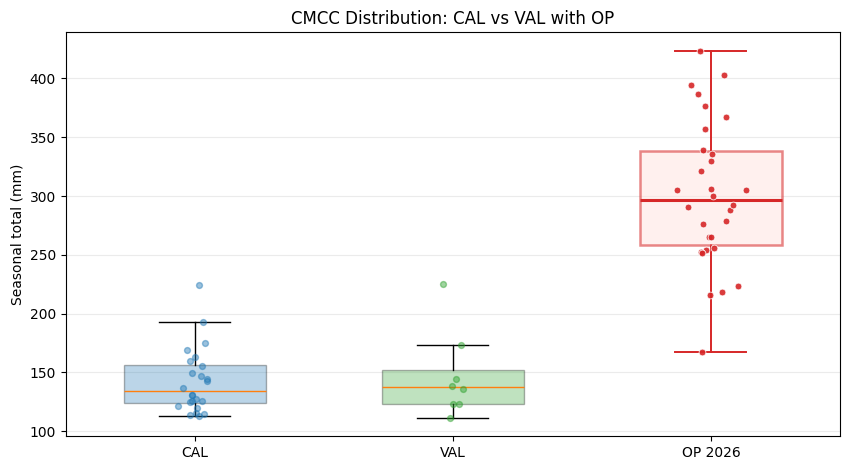

Saved: outputs\cmcc_v1\plots\diagnostics\CMCC_companion_distribution_boxplot.png


In [57]:
# 3) Ranked/distribution chart (boxplot CAL vs VAL with OP boxplot)
cal_plot = cmcc_summary_df.loc[cmcc_summary_df["period"] == "CAL", "seasonal_total_mm"].dropna().values
val_plot = cmcc_summary_df.loc[cmcc_summary_df["period"] == "VAL", "seasonal_total_mm"].dropna().values

# OP member distribution from operational-year file.
op_plot = np.array([])
if np.isfinite(op_year_local) and int(op_year_local) in file_map:
    try:
        member_cap_ref_local = globals().get("member_cap_ref", globals().get("hindcast_member_cap", None))
        mtot_op = _load_member_seasonal_totals_local(file_map[int(op_year_local)], member_cap=member_cap_ref_local)
        op_plot = np.asarray(mtot_op, dtype=float)
        op_plot = op_plot[np.isfinite(op_plot)]
    except Exception as e:
        print(f"OP member distribution not computed: {e}")

fig, ax = plt.subplots(figsize=(8.6, 4.8))

# Build the boxplot inputs dynamically so OP can be shown as a full box when available.
box_data = [cal_plot, val_plot]
box_labels = ["CAL", "VAL"]
if op_plot.size > 0:
    box_data.append(op_plot)
    box_labels.append(f"OP {int(op_year_local)}")

parts = ax.boxplot(box_data, labels=box_labels, patch_artist=True, widths=0.55, showfliers=False)

# CAL and VAL style.
parts["boxes"][0].set_facecolor("tab:blue")
parts["boxes"][0].set_alpha(0.3)
parts["boxes"][1].set_facecolor("tab:green")
parts["boxes"][1].set_alpha(0.3)

# OP style to match period-summary look.
if op_plot.size > 0:
    op_idx = 2
    parts["boxes"][op_idx].set_facecolor("mistyrose")
    parts["boxes"][op_idx].set_edgecolor("tab:red")
    parts["boxes"][op_idx].set_linewidth(1.8)
    parts["boxes"][op_idx].set_alpha(0.55)
    parts["boxes"][op_idx].set_zorder(3)
    parts["medians"][op_idx].set_color("tab:red")
    parts["medians"][op_idx].set_linewidth(2.2)
    parts["medians"][op_idx].set_zorder(4)
    parts["whiskers"][2 * op_idx].set_color("tab:red")
    parts["whiskers"][2 * op_idx + 1].set_color("tab:red")
    parts["whiskers"][2 * op_idx].set_linewidth(1.4)
    parts["whiskers"][2 * op_idx + 1].set_linewidth(1.4)
    parts["caps"][2 * op_idx].set_color("tab:red")
    parts["caps"][2 * op_idx + 1].set_color("tab:red")
    parts["caps"][2 * op_idx].set_linewidth(1.4)
    parts["caps"][2 * op_idx + 1].set_linewidth(1.4)

# Jittered points for context with lower opacity.
rng = np.random.default_rng(123)
if cal_plot.size:
    ax.scatter(1 + rng.normal(0, 0.03, size=cal_plot.size), cal_plot, s=18, color="tab:blue", alpha=0.45, zorder=5)
if val_plot.size:
    ax.scatter(2 + rng.normal(0, 0.03, size=val_plot.size), val_plot, s=18, color="tab:green", alpha=0.45, zorder=5)
if op_plot.size:
    ax.scatter(
        3 + rng.normal(0, 0.06, size=op_plot.size),
        op_plot,
        s=24,
        color="tab:red",
        alpha=0.9,
        edgecolors="white",
        linewidths=0.6,
        zorder=6,
    )
elif np.isfinite(op_val_ref):
    # Fallback marker if OP member array is unavailable.
    ax.scatter([2.45], [op_val_ref], c="tab:red", marker="*", s=120, zorder=6, label=f"OP {op_year_local}")

ax.set_ylabel("Seasonal total (mm)")
ax.set_title("CMCC Distribution: CAL vs VAL with OP")
ax.grid(True, axis="y", alpha=0.25)
if op_plot.size == 0 and np.isfinite(op_val_ref):
    ax.legend(loc="best", fontsize=9)
plt.tight_layout()
out_fp = os.path.join(diag_dir, "CMCC_companion_distribution_boxplot.png")
plt.savefig(out_fp, dpi=160)
plt.show()
print(f"Saved: {out_fp}")

### Explanation: Distribution Comparison (CAL vs VAL with OP)

This plot compares historical seasonal totals in CAL and VAL with the 2026 operational forecast members.

- The line inside each box is the median.
- The box shows the middle range of values.
- The dots are the individual years for CAL and VAL, and the individual ensemble members for OP.
- If the OP box is higher, 2026 is generally wetter; if it is wider, the forecast uncertainty is larger.

## Summary

In [43]:
# -- Summary -----------------------------------------------------------------
print()
print("=" * 65)
print("SUMMARY")
print("=" * 65)
print(f"  Total files           : {len(all_files)}")
print(f"  Year range            : {yr_min}-{yr_max}")
print(f"  Missing years         : {missing_years if missing_years else 'None'}")
print(f"  Hindcast period       : {hindcast_years[0] if hindcast_years else '?'}-"
      f"{hindcast_years[-1] if hindcast_years else '?'}"
      f"  ({len(hindcast_years)} yrs)")
print(f"  Forecast year(s)      : {forecast_years if forecast_years else 'None'}")
print(f"  Ensemble size         : "
      f"{sorted(unique_sizes)} "
      f"({'uniform' if len(unique_sizes)==1 else 'VARIES - check above'})")
 
if lat_name and lon_name:
    try:
        ds_tmp = xr.open_dataset(file_map[file_years[0]], decode_times=False)
        lats_t = ds_tmp.coords[lat_name].values
        lons_t = ds_tmp.coords[lon_name].values
        dlat_t = abs(lats_t[1]-lats_t[0]) if len(lats_t)>1 else float('nan')
        dlon_t = abs(lons_t[1]-lons_t[0]) if len(lons_t)>1 else float('nan')
        print(f"  Native resolution     : ~{dlat_t:.2f} deg x {dlon_t:.2f} deg")
        print(f"  SEAS5 resolution      : ~1.00 deg x 1.00 deg")
        print(f"  CHIRPS target         : 0.25 deg x 0.25 deg  (regrid required: "
              f"{'yes' if dlat_t > 0.25 else 'no, already finer'})")
        ds_tmp.close()
    except Exception:
        pass
 
print(f"  Initialisation date   : {INIT_MONTH:02d}-{INIT_DAY:02d}  (Feb 1)")
print()
print("  Next step: check precipitation variable name and units,")
print("  then proceed to cumulative vs daily conversion if needed.")


SUMMARY
  Total files           : 33
  Year range            : 1993-2026
  Missing years         : [2025]
  Hindcast period       : 1993-2024  (32 yrs)
  Forecast year(s)      : [2026]
  Ensemble size         : [30, 50] (VARIES - check above)
  Native resolution     : ~1.00 deg x 1.00 deg
  SEAS5 resolution      : ~1.00 deg x 1.00 deg
  CHIRPS target         : 0.25 deg x 0.25 deg  (regrid required: yes)
  Initialisation date   : 02-01  (Feb 1)

  Next step: check precipitation variable name and units,
  then proceed to cumulative vs daily conversion if needed.
